In [1]:
# Standard library
import asyncio
import os
import threading
from pathlib import Path
from typing import Any, Sequence

# ── Project paths ─────────────────────────────────────────────────────────────
ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data"
FIGURE_DIR = ROOT / "outputs" / "figures"

# ── Reproducibility ───────────────────────────────────────────────────────────
GLOBAL_SEED = 42

# ── Île-de-France geography constants ────────────────────────────────────────
IDF_DEPARTMENT_CODES = {"75", "77", "78", "91", "92", "93", "94", "95"}
IDF_REGION_CODE = "11"
INSEE_COLUMN_PATTERNS = ["insee", "depcom", "code_insee", "insee_com", "com"]


In [2]:
# Third-party — scientific / data
import geopandas as gpd
import numpy as np
import pandas as pd
import polars as pl
from branca.colormap import LinearColormap
from pynsee.geodata import get_geodata, get_geodata_list
from scipy import stats
from scipy.stats import gaussian_kde
from sklearn.decomposition import FactorAnalysis, FastICA, PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import MinMaxScaler, StandardScaler


/home/youssef/projects/Sim-Equity/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Third-party — visualization
import folium
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# ── Figure constants ──────────────────────────────────────────────────────────
FIGSIZE = (6.685, 6.25)
DPI = 300

BASE_FONTSIZE = 17
TITLE_FONTSIZE = 20
TICK_FONTSIZE = 17
ANNOT_FONTSIZE = 17
COLORBAR_FONTSIZE = 17
MATH_FONTSIZE = 18

MARKER_SIZE = 36
ALPHA = 0.6

# ── Vulnerability thresholds ──────────────────────────────────────────────────
LOW_VULNERABILITY_MAX = 0.25
MODERATE_VULNERABILITY_MAX = 0.50
HIGH_VULNERABILITY_MAX = 0.75

# ── Color palette ─────────────────────────────────────────────────────────────
PRIMARY_COLOR = "#2E86AB"  # Professional blue
SECONDARY_COLOR = "#A23B72"  # Sophisticated purple
ACCENT_COLOR = "#F18F01"  # Warm orange
GRID_COLOR = "#E5E5E5"  # Light gray
SUCCESS_COLOR = "#27AE60"  # Green for positive indicators
WARNING_COLOR = "#F39C12"  # Orange for warnings
DANGER_COLOR = "#E74C3C"  # Red for critical areas
NEUTRAL_COLOR = "#95A5A6"  # Gray for neutral elements

VULNERABILITY_COLORS = {
    "low": "#27AE60",
    "moderate": "#F39C12",
    "high": "#E67E22",
    "very_high": "#E74C3C",
}

# ── Global colormap ───────────────────────────────────────────────────────────
_palette = sns.color_palette("coolwarm", as_cmap=True)
CMAP = (
    _palette
    if isinstance(_palette, LinearSegmentedColormap)
    else LinearSegmentedColormap.from_list("custom_cmap", _palette)
)

# ── Apply rcParams once ───────────────────────────────────────────────────────
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": FIGSIZE,
        "figure.dpi": DPI,
        "savefig.dpi": DPI,
        "font.family": "DejaVu Sans",
        "font.size": BASE_FONTSIZE,
        "axes.titlesize": TITLE_FONTSIZE,
        "axes.labelsize": BASE_FONTSIZE,
        "xtick.labelsize": TICK_FONTSIZE,
        "ytick.labelsize": TICK_FONTSIZE,
        "legend.fontsize": BASE_FONTSIZE,
        "mathtext.fontset": "dejavusans",
        "axes.grid": False,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.linewidth": 1.2,
        "grid.linewidth": 0.5,
        "lines.linewidth": 2.0,
        "patch.linewidth": 1.0,
        "boxplot.flierprops.markersize": 4,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "text.usetex": False,
    }
)


# ── Plotting utilities ────────────────────────────────────────────────────────


def setup_academic_grid(ax: plt.Axes, axis: str = "both") -> None:
    """Apply consistent dotted-grid styling to an axes."""
    ax.grid(True, axis=axis, linestyle=":", linewidth=0.5, color=GRID_COLOR, alpha=0.7)


def add_vulnerability_zones(ax: plt.Axes, axis: str = "x", alpha: float = 0.1) -> None:
    """Shade background regions corresponding to SVI vulnerability levels."""
    thresholds = [
        (0, LOW_VULNERABILITY_MAX, "low", "Low Vulnerability"),
        (
            LOW_VULNERABILITY_MAX,
            MODERATE_VULNERABILITY_MAX,
            "moderate",
            "Moderate Vulnerability",
        ),
        (
            MODERATE_VULNERABILITY_MAX,
            HIGH_VULNERABILITY_MAX,
            "high",
            "High Vulnerability",
        ),
        (HIGH_VULNERABILITY_MAX, 1, "very_high", "Very High Vulnerability"),
    ]
    span_fn = ax.axvspan if axis == "x" else ax.axhspan
    for lo, hi, level, label in thresholds:
        span_fn(
            lo,
            hi,
            alpha=alpha,
            color=VULNERABILITY_COLORS[level],
            label=label if axis == "x" else None,
        )


def style_boxplot(
        box_plot: dict,
        primary: str = PRIMARY_COLOR,
        secondary: str = SECONDARY_COLOR,
) -> None:
    """Apply consistent styling to a matplotlib boxplot."""
    for patch in box_plot["boxes"]:
        patch.set_facecolor(primary)
        patch.set_alpha(0.7)
        patch.set_linewidth(1.5)
    for key in ("whiskers", "caps"):
        for item in box_plot[key]:
            item.set_color(primary)
            item.set_linewidth(1.5)
    for median in box_plot["medians"]:
        median.set_color("white")
        median.set_linewidth(2)
    for flier in box_plot["fliers"]:
        flier.set_markerfacecolor(secondary)
        flier.set_markeredgecolor(secondary)
        flier.set_markersize(4)
        flier.set_alpha(0.6)


def add_statistical_annotations(
        ax: plt.Axes,
        data: np.ndarray,
        position: float = 1,
        orientation: str = "horizontal",
) -> None:
    """Annotate a plot with median and mean values."""
    _, median, _ = np.percentile(data, [25, 50, 75])
    mean_val = data.mean()
    if orientation == "horizontal":
        ax.text(
            median,
            position + 0.15,
            f"Median: {median:.3f}",
            ha="center",
            va="bottom",
            fontsize=ANNOT_FONTSIZE - 2,
            fontweight="bold",
            color=PRIMARY_COLOR,
        )
        ax.text(
            mean_val,
            position - 0.15,
            f"Mean: {mean_val:.3f}",
            ha="center",
            va="top",
            fontsize=ANNOT_FONTSIZE - 2,
            fontweight="bold",
            color=ACCENT_COLOR,
        )


def format_academic_title(title: str, subtitle: str | None = None) -> str:
    """Return a title string, with optional subtitle on a second line."""
    return f"{title}\n{subtitle}" if subtitle else title


def savefig_standard(fname: str | Path, dpi: int | None = None) -> None:
    """Save the current figure with consistent academic formatting."""
    plt.tight_layout()
    plt.savefig(
        fname,
        bbox_inches="tight",
        dpi=dpi or DPI,
        facecolor="white",
        edgecolor="none",
        transparent=False,
    )
    print(f"Saved: {fname}")


def create_academic_legend(
        ax: plt.Axes,
        title: str | None = None,
        loc: str = "best",
) -> plt.legend:
    """Add a consistently styled legend to an axes."""
    legend = ax.legend(
        title=title,
        loc=loc,
        frameon=True,
        fancybox=True,
        shadow=True,
        framealpha=0.9,
        facecolor="white",
        edgecolor=GRID_COLOR,
        fontsize=BASE_FONTSIZE - 2,
    )
    if title:
        legend.get_title().set_fontsize(BASE_FONTSIZE - 1)
        legend.get_title().set_fontweight("bold")
    return legend


def print_statistical_summary(
        data: np.ndarray, variable_name: str = "Variable"
) -> None:
    """Print a comprehensive descriptive statistics report."""
    separator = "=" * 80
    print(separator)
    print(f"{variable_name.upper()} - STATISTICAL ANALYSIS REPORT")
    print(separator)

    iqr = np.percentile(data, 75) - np.percentile(data, 25)
    skewness = stats.skew(data)
    kurtosis_val = stats.kurtosis(data)

    print("\nDESCRIPTIVE STATISTICS:")
    print(f"  Sample Size:              {len(data):,}")
    print(f"  Mean:                     {data.mean():.4f}")
    print(f"  Median:                   {np.median(data):.4f}")
    print(f"  Standard Deviation:       {data.std():.4f}")
    print(f"  Variance:                 {data.var():.4f}")
    print(f"  Range:                    {data.max() - data.min():.4f}")
    print(f"  Interquartile Range:      {iqr:.4f}")
    print(f"  Coefficient of Variation: {data.std() / data.mean():.4f}")

    skew_label = (
        "Right-skewed"
        if skewness > 0.5
        else "Left-skewed" if skewness < -0.5 else "Approximately symmetric"
    )
    tail_label = "Heavy-tailed" if kurtosis_val > 0 else "Light-tailed"
    print("\nDISTRIBUTION CHARACTERISTICS:")
    print(f"  Skewness:  {skewness:.4f}  ({skew_label})")
    print(f"  Kurtosis:  {kurtosis_val:.4f}  ({tail_label})")



In [4]:
trips_df = pl.read_csv(source=f"{DATA_DIR}/trips_dataset.csv", infer_schema_length=10000)



In [5]:
individuals_df = pl.read_csv(
    source=f"{DATA_DIR}/individuals_dataset.csv", infer_schema_length=10000
)


In [6]:
individuals_with_trips_df = individuals_df.join(on="ID", how="right", other=trips_df)


In [7]:
dtypes_dict = {
    col: individuals_with_trips_df[col].dtype
    for col in individuals_with_trips_df.columns
}
dtypes_dict


{'CODGEO': Int64,
 'AREA_NAME': String,
 'SEX': String,
 'AGE': Int64,
 'DIPLOMA': String,
 'PRO_CAT': Int64,
 'TYPE_HOUSE': String,
 'NBPERS_HOUSE': Int64,
 'NB_10': Int64,
 'NB_11_17': Float64,
 'NB_18_24': Float64,
 'NB_25_64': Int64,
 'NB_65': Int64,
 'PMR': Boolean,
 'DRIVING_LICENCE': Boolean,
 'NB_CAR': Int64,
 'TWO_WHEELER': String,
 'BIKE': String,
 'ELECT_SCOOTER': String,
 'NAVIGO_SUB': Boolean,
 'IMAGINER_SUB': Boolean,
 'OTHER_SUB_PT': Boolean,
 'BIKE_SUB': Boolean,
 'NSM_SUB': Boolean,
 'WEIGHT_INDIV': Float64,
 'GPS_RECORD': Boolean,
 'KEY': String,
 'ID': String,
 'Day_EMG': String,
 'Date_EMG': String,
 'Day_Type': String,
 'ID_Trip_Days': String,
 'Type_Trip_OD': String,
 'Area_O': String,
 'Area_D': String,
 'Code_INSEE_O': String,
 'Code_INSEE_D': String,
 'Zone_O': String,
 'Zone_D': String,
 'Date_O': String,
 'Time_O': String,
 'Date_D': String,
 'Time_D': String,
 'Duration': Float64,
 'Purpose_O': String,
 'Purpose_D': String,
 'Main_Mode': String,
 'Mode_1': S

In [8]:
individuals_with_trips_df.filter(
    pl.col("GPS_RECORD") == False
).height / individuals_with_trips_df.shape[0] / 100


3.705218285685961e-05

In [9]:
individuals_with_trips_df = individuals_with_trips_df.filter(
    pl.col("GPS_RECORD") == True
)


## Encoding Values & Preparing Values for building social vulnerability index (SVI)

### Converting Values to be ready for calculations

In [10]:
# Categorical column cardinalities (for reference):
# SEX           -> 2 unique values
# DIPLOMA       -> 7 unique values
# TWO_WHEELER   -> 5 unique values
# BIKE          -> 5 unique values
# ELECT_SCOOTER -> 5 unique values
individuals_with_trips_df = individuals_with_trips_df.with_columns(
    [
        pl.col("SEX").replace({"Man": 0, "Woman": 1}, return_dtype=pl.Int8),
        pl.col("DIPLOMA")
        .replace(
            {
                "5-year-and-above higher education degree: Master's 2, DEA, DESS, Grande École Diploma, Doctorate, etc.": 6,
                "3–4-year higher education degree: Licence, Professional Licence, Master 1, or equivalent": 5,
                "Upper secondary diploma (Baccalauréat) or equivalent": 4,
                "Vocational certificate (CAP, BEP) or equivalent": 3,
                "Lower secondary certificate (Brevet) or equivalent": 2,
                "No diploma": 1,
            },
            default=0,
        )
        .cast(pl.Int8),
        pl.col("TWO_WHEELER").replace({"4+": 4}, return_dtype=pl.Int8),
        pl.col("BIKE").replace({"4+": 4}, return_dtype=pl.Int8),
        pl.col("ELECT_SCOOTER").replace({"4+": 4}, return_dtype=pl.Int8),
        # Transit subscription flags are inverted: absence of subscription → higher vulnerability.
        pl.col("NAVIGO_SUB").replace({0: 1, 1: 0}, default=0).cast(pl.Int8),
        pl.col("IMAGINER_SUB").replace({0: 1, 1: 0}, default=0).cast(pl.Int8),
        pl.col("OTHER_SUB_PT").replace({0: 1, 1: 0}, default=0).cast(pl.Int8),
        pl.col("BIKE_SUB").replace({0: 1, 1: 0}, default=0).cast(pl.Int8),
        pl.col("NSM_SUB").replace({0: 1, 1: 0}, default=0).cast(pl.Int8),
    ]
)


/tmp/ipykernel_153572/1516485253.py:9: DeprecationWarning: the `return_dtype` parameter for `replace` is deprecated. Use `replace_strict` instead to set a return data type while replacing values.
(Deprecated in version 1.0.0)
  pl.col("SEX").replace({"Man": 0, "Woman": 1}, return_dtype=pl.Int8),
/tmp/ipykernel_153572/1516485253.py:11: DeprecationWarning: the `default` parameter for `replace` is deprecated. Use `replace_strict` instead to set a default while replacing values.
(Deprecated in version 1.0.0)
  .replace(
/tmp/ipykernel_153572/1516485253.py:23: DeprecationWarning: the `return_dtype` parameter for `replace` is deprecated. Use `replace_strict` instead to set a return data type while replacing values.
(Deprecated in version 1.0.0)
  pl.col("TWO_WHEELER").replace({"4+": 4}, return_dtype=pl.Int8),
/tmp/ipykernel_153572/1516485253.py:24: DeprecationWarning: the `return_dtype` parameter for `replace` is deprecated. Use `replace_strict` instead to set a return data type while replac

### Applying the decreasing function 1/1+log(x) according to the described relations bet. the features applied on it & the Social Vulnerability Index

In [11]:
# Vectorized transformations using Polars native expressions (no Python-level map_elements).
# Uses natural log (base e) throughout to match the original math.log behaviour.
mean_age = individuals_with_trips_df["AGE"].mean()

individuals_with_trips_df = individuals_with_trips_df.with_columns(
    [
        # Age: symmetric distance from mean, log-compressed → larger distance = higher vulnerability
        ((pl.col("AGE") - mean_age).abs() + 1).log(base=np.e).alias("TRANSFORMED_AGE"),
        # Resource indicators: more resources → lower vulnerability (decreasing transform)
        (1 / ((pl.col("NB_CAR") + 1).log(base=np.e) + 1)).alias("TRANSFORMED_NB_CAR"),
        (1 / ((pl.col("TWO_WHEELER") + 1).log(base=np.e) + 1)).alias(
            "TRANSFORMED_TWO_WHEELER"
        ),
        (1 / ((pl.col("BIKE") + 1).log(base=np.e) + 1)).alias("TRANSFORMED_BIKE"),
        (1 / ((pl.col("ELECT_SCOOTER") + 1).log(base=np.e) + 1)).alias(
            "TRANSFORMED_ELECT_SCOOTER"
        ),
        (1 / ((pl.col("DIPLOMA") + 1).log(base=np.e) + 1)).alias("TRANSFORMED_DIPLOMA"),
        # Household size: log-compressed (larger household = more complexity)
        pl.col("NBPERS_HOUSE").log(base=np.e).alias("TRANSFORMED_NBPERS_HOUSE"),
    ]
)


### Converting Bool Values to Integers

## Extensive Data Analysis

In [12]:
# Exploratory profiling (ydata-profiling) can be run locally:
#   ProfileReport(individuals_with_trips_df.to_pandas(), title="Profiling Report").to_file("report.html")


In [13]:
are_correlated = individuals_with_trips_df.select(
    pl.col(
        "SEX",
        "TRANSFORMED_AGE",
        "TRANSFORMED_DIPLOMA",
        "TRANSFORMED_NB_CAR",
        "PMR",
        "TRANSFORMED_NBPERS_HOUSE",
        "TRANSFORMED_TWO_WHEELER",
        "TRANSFORMED_BIKE",
        "TRANSFORMED_ELECT_SCOOTER",
        "NAVIGO_SUB",
        "IMAGINER_SUB",
        "OTHER_SUB_PT",
        "BIKE_SUB",
        "NSM_SUB",
    )
)

are_correlated.describe()



statistic,SEX,TRANSFORMED_AGE,TRANSFORMED_DIPLOMA,TRANSFORMED_NB_CAR,PMR,TRANSFORMED_NBPERS_HOUSE,TRANSFORMED_TWO_WHEELER,TRANSFORMED_BIKE,TRANSFORMED_ELECT_SCOOTER,NAVIGO_SUB,IMAGINER_SUB,OTHER_SUB_PT,BIKE_SUB,NSM_SUB
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",0.550138,2.280117,0.465501,0.673307,0.03275,0.760644,0.961723,0.706687,0.960497,0.467673,0.906291,0.949041,0.888442,0.980398
"""std""",0.497483,0.822639,0.235521,0.215971,null,0.601321,0.123095,0.263237,0.123549,0.498957,0.291425,0.219915,0.314823,0.138631
"""min""",0.0,0.14308,0.339454,0.312771,0.0,0.0,0.383224,0.383224,0.383224,0.0,0.0,0.0,0.0,0.0
"""25%""",0.0,1.765788,0.339454,0.476505,null,0.0,1.0,0.476505,1.0,0.0,1.0,1.0,1.0,1.0
"""50%""",1.0,2.472005,0.358197,0.590616,null,0.693147,1.0,0.590616,1.0,0.0,1.0,1.0,1.0,1.0
"""75%""",1.0,2.952502,0.383224,1.0,null,1.386294,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
"""max""",1.0,3.692718,1.0,1.0,1.0,2.484907,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## Making It Ready to Build SVI (Social Vulnerability Index)

In [14]:
feature_columns = are_correlated.columns

# Snapshot before PCA loadings are applied — used for t-SNE visualizations.
are_correlated_raw = are_correlated.clone()



### Standardizing All Features separately by standard scaler to make each of them participate equally in the SVI


In [15]:
scaler = StandardScaler()
are_correlated = pl.DataFrame(
    scaler.fit_transform(are_correlated.to_numpy()),
    schema=feature_columns,
)

### Investigating which dimensionality reduction technique is the best

In [16]:
def compare_dim_reduction_variances(
        df: pl.DataFrame,
        cols: list[str],
        max_samples: int | None = 3000,
        random_state: int = GLOBAL_SEED,
) -> dict:
    """
    Compare variance explained by different dimensionality reduction methods.

    Parameters
    ----------
    df : Polars DataFrame with vulnerability data.
    cols : Column names to use.
    max_samples : Maximum rows to sample to prevent memory exhaustion during KernelPCA.
    random_state : Random seed for reproducible sampling.

    Returns
    -------
    dict mapping method name to variance-explained info.
    """
    if max_samples is not None and len(df) > max_samples:
        df = df.sample(n=max_samples, seed=random_state)

    X = df.select(cols).to_numpy()
    X_scaled = StandardScaler().fit_transform(X)
    total_variance = X_scaled.var(axis=0).sum()

    results: dict = {}

    pca = PCA(n_components=1)
    pca.fit(X_scaled)
    results["PCA"] = {
        "variance_explained": pca.explained_variance_ratio_[0],
        "method": "PCA captures linear variance. Baseline method.",
    }

    for kernel_name, params in [("rbf", {}), ("poly", {"degree": 2}), ("sigmoid", {})]:
        try:
            from sklearn.decomposition import KernelPCA

            kpca = KernelPCA(n_components=1, kernel=kernel_name, **params)
            kpca_proj = kpca.fit_transform(X_scaled).flatten()
            results[f"KernelPCA_{kernel_name}"] = {
                "variance_explained": np.var(kpca_proj) / total_variance,
                "method": f"Nonlinear {kernel_name} kernel",
            }
        except Exception as exc:
            results[f"KernelPCA_{kernel_name}"] = {"error": str(exc)}

    try:
        ica = FastICA(n_components=1, random_state=random_state)
        ica_proj = ica.fit_transform(X_scaled).flatten()
        results["ICA"] = {
            "variance_explained": np.var(ica_proj) / total_variance,
            "method": "Independent components; not variance-maximizing",
        }
    except Exception as exc:
        results["ICA"] = {"error": str(exc)}

    return results



In [17]:
def _align_sign(weights: dict[str, float]) -> dict[str, float]:
    """Flip signs if the first feature contributes negatively (convention: align positively)."""
    if weights and next(iter(weights.values())) < 0:
        return {k: -v for k, v in weights.items()}
    return weights


def extract_svi_feature_weights(df: pl.DataFrame, cols: list[str]) -> dict:
    """
    Extract feature weights from different dimensionality reduction methods.

    Returns both raw weights and absolute values for importance ranking.

    Parameters
    ----------
    df : Polars DataFrame with vulnerability data.
    cols : Column names to use.

    Returns
    -------
    dict mapping method name to weight info.
    """

    X = df.select(cols).to_numpy()
    X_scaled = StandardScaler().fit_transform(X)
    results: dict = {}

    # PCA
    pca = PCA(n_components=1)
    pca.fit(X_scaled)
    pca_weights = _align_sign(dict(zip(cols, pca.components_[0])))
    results["PCA"] = {
        "abs_weights": {k: abs(v) for k, v in pca_weights.items()},
        "method": "Principal Component Analysis - weights represent linear combination maximizing variance",
    }

    # ICA
    try:
        ica = FastICA(n_components=1, random_state=GLOBAL_SEED)
        ica.fit(X_scaled)
        ica_weights = _align_sign(dict(zip(cols, ica.components_[0])))
        results["ICA"] = {
            "abs_weights": {k: abs(v) for k, v in ica_weights.items()},
            "method": "Independent Component Analysis - weights represent statistically independent sources",
        }
    except Exception as exc:
        results["ICA"] = {"error": str(exc)}

    # Factor Analysis
    try:
        fa = FactorAnalysis(n_components=1, random_state=GLOBAL_SEED)
        fa.fit(X_scaled)
        fa_weights = _align_sign(dict(zip(cols, fa.components_[0])))
        results["FactorAnalysis"] = {
            "abs_weights": {k: abs(v) for k, v in fa_weights.items()},
            "method": "Factor Analysis - weights represent loadings on latent vulnerability factor",
        }
    except Exception as exc:
        results["FactorAnalysis"] = {"error": str(exc)}

    return results



Saved: /home/youssef/projects/Sim-Equity/outputs/figures/dimensionality_reduction/tsne_with_pca.png


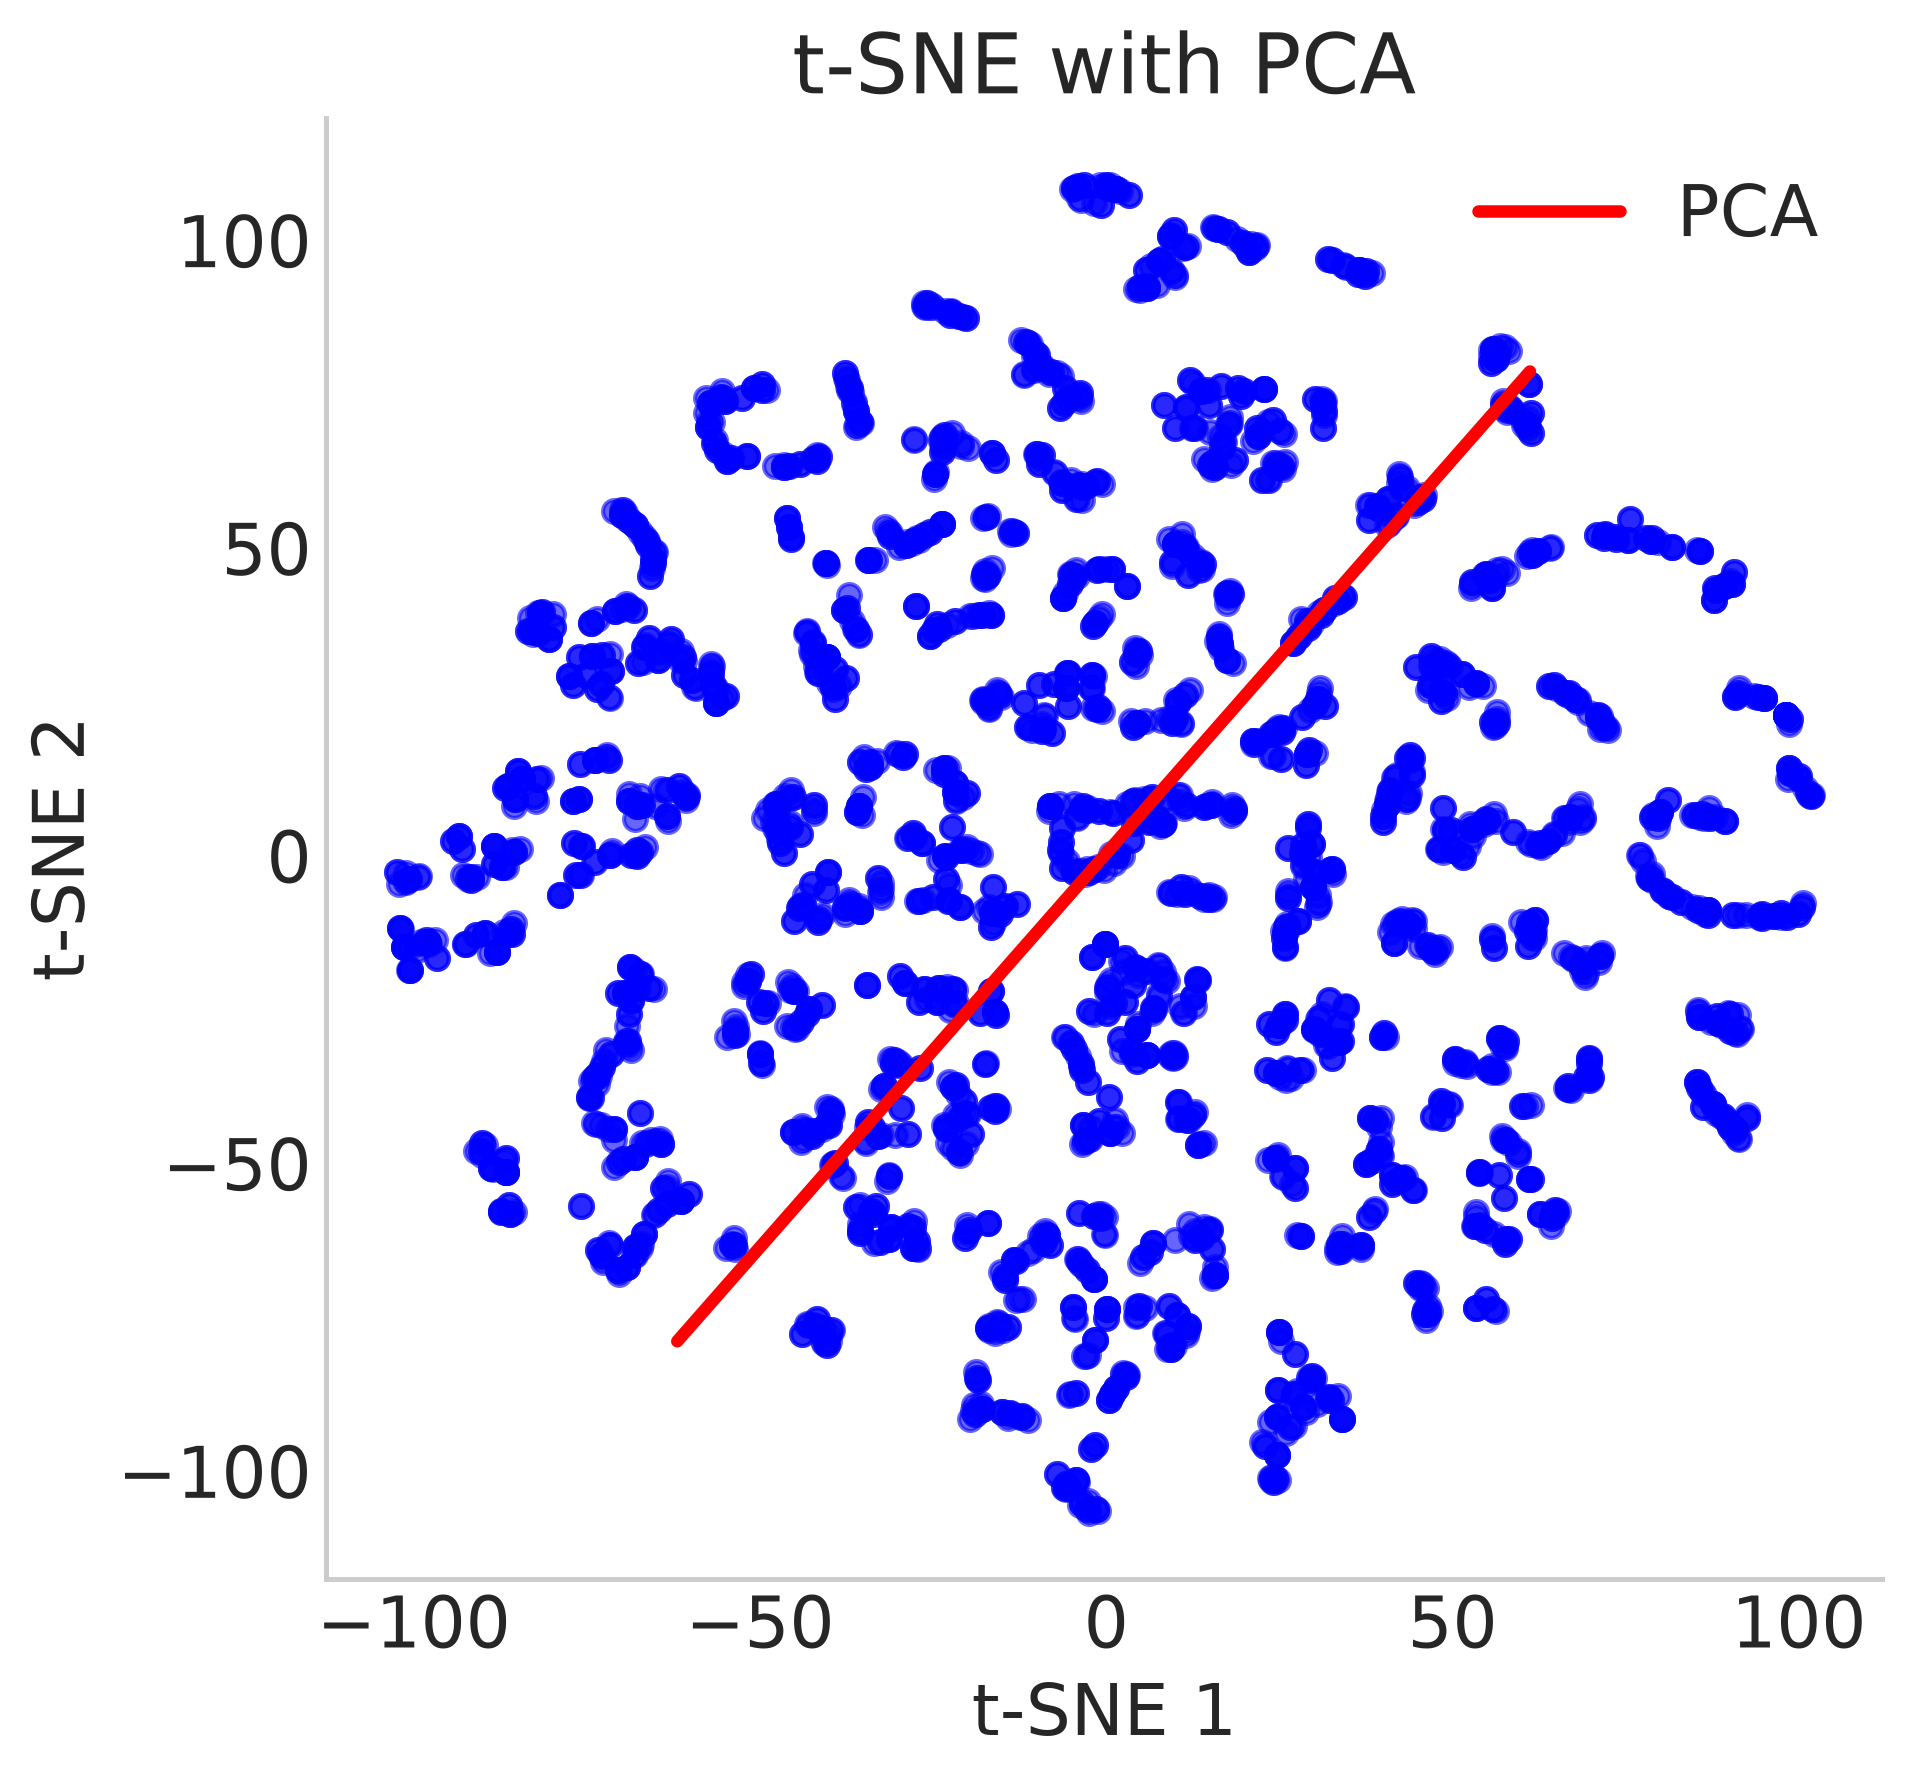

Saved: /home/youssef/projects/Sim-Equity/outputs/figures/dimensionality_reduction/tsne_with_kpca_sigmoid.png


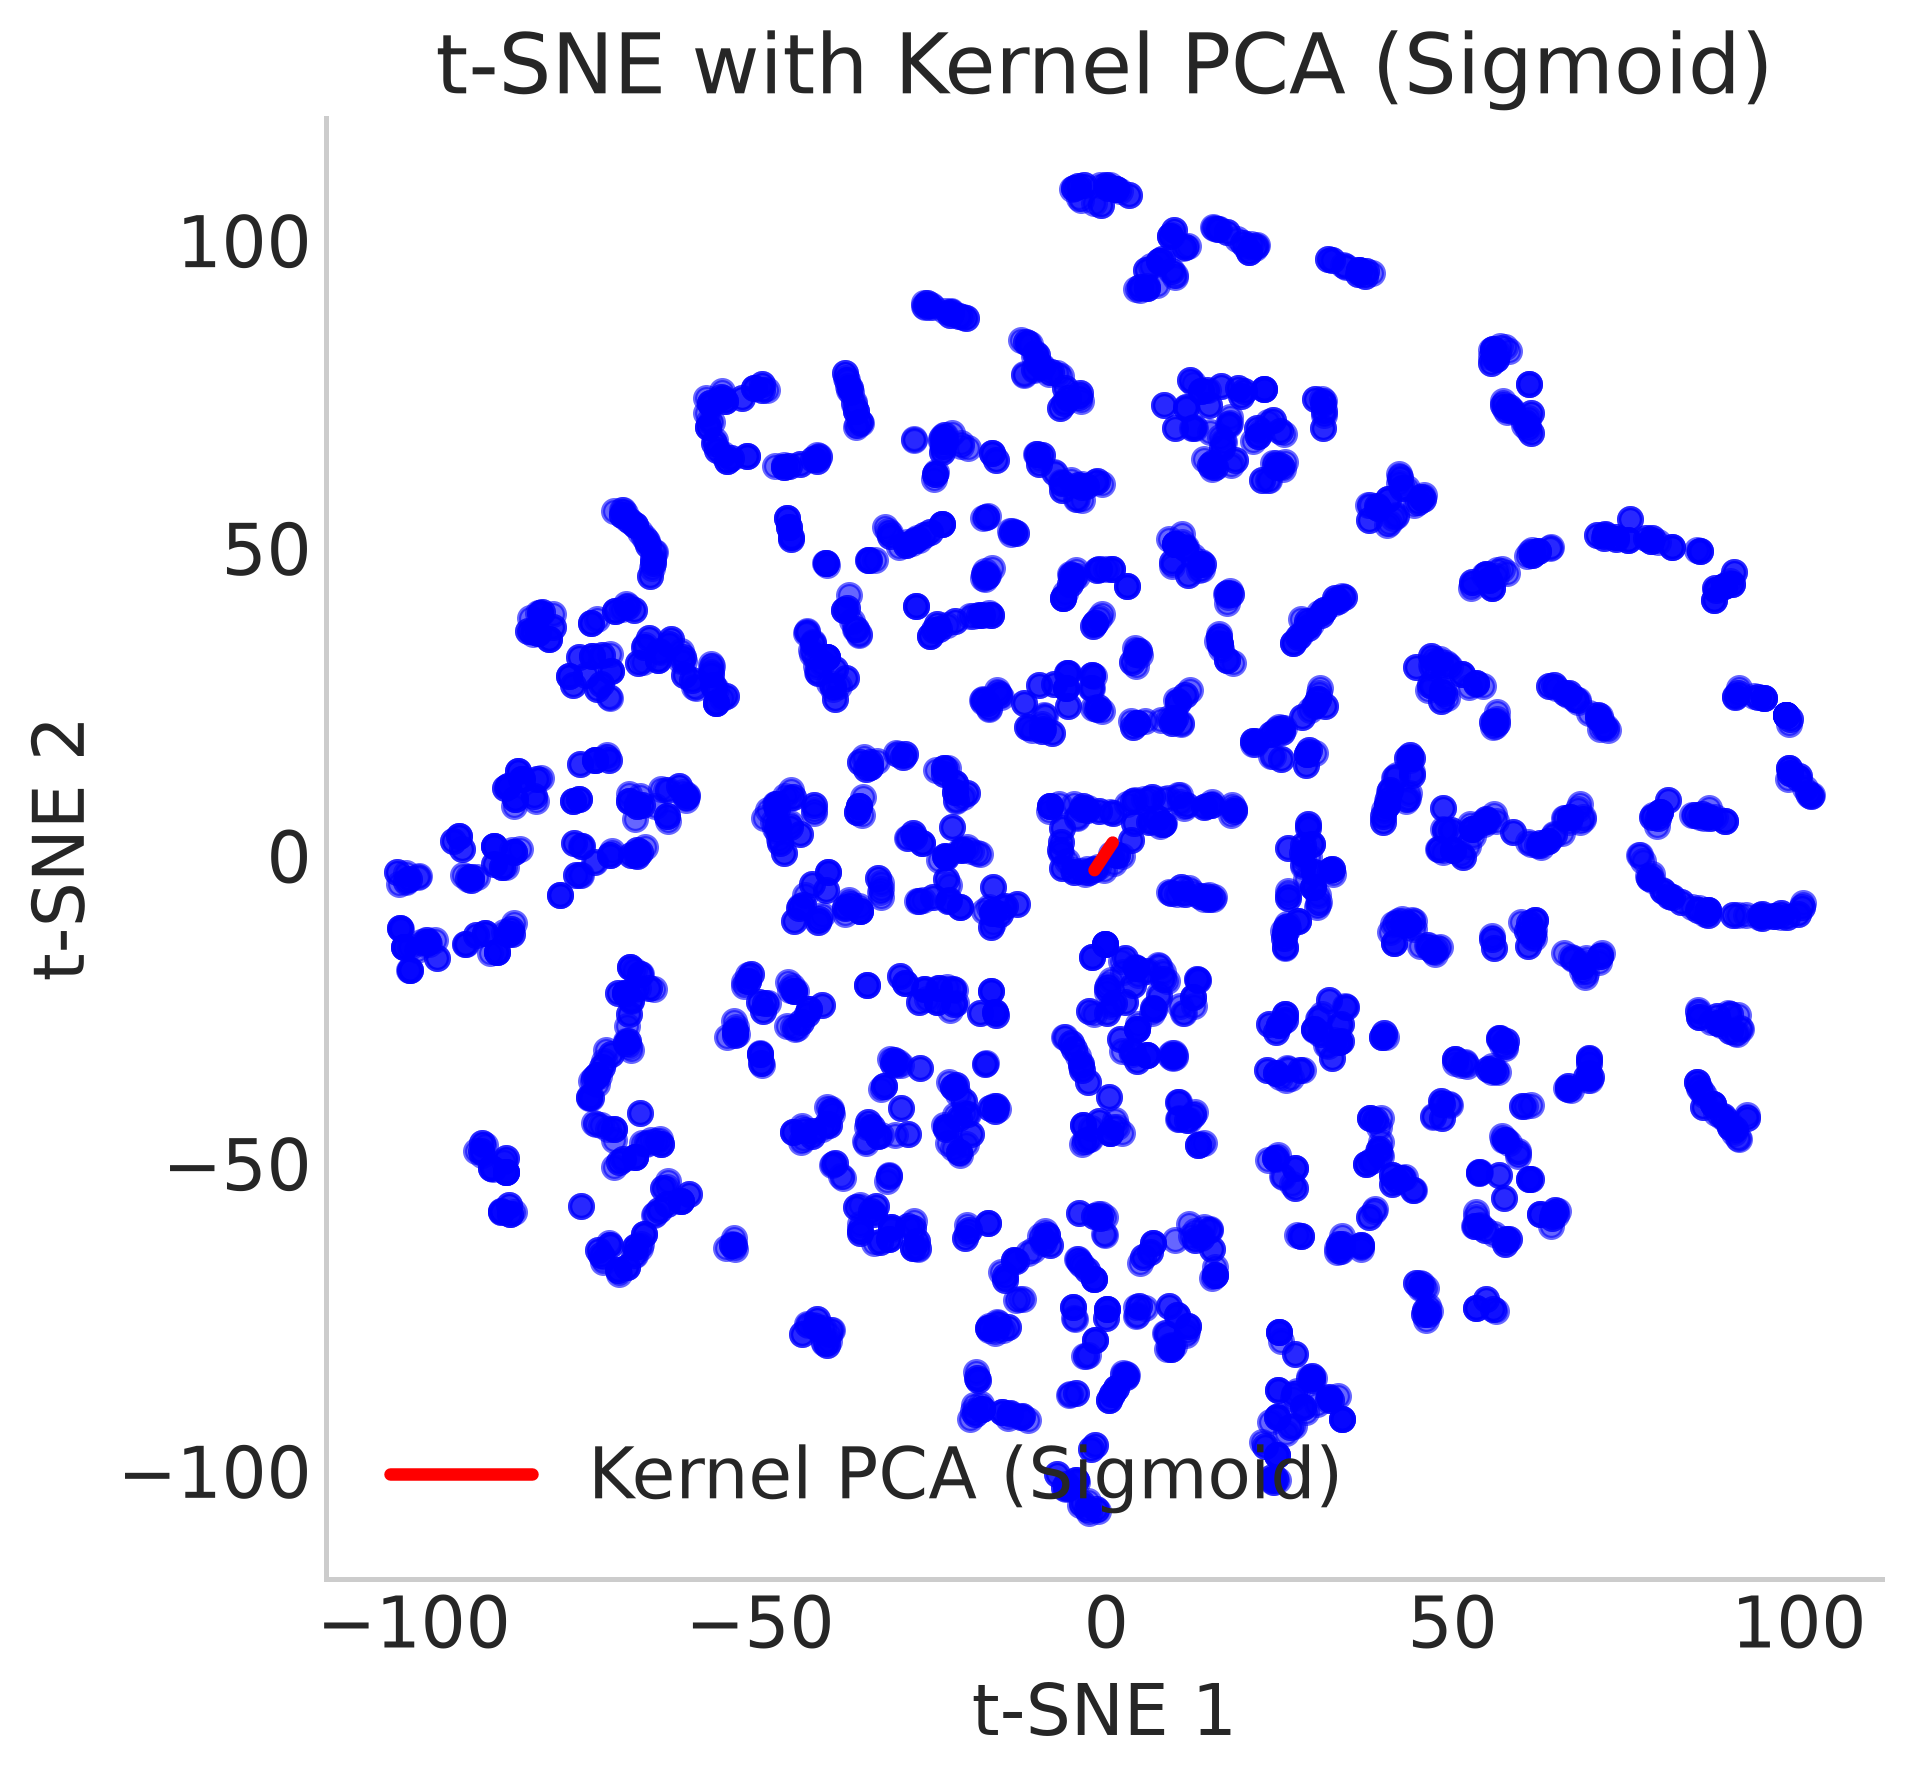

Saved: /home/youssef/projects/Sim-Equity/outputs/figures/dimensionality_reduction/tsne_with_kpca_rbf.png


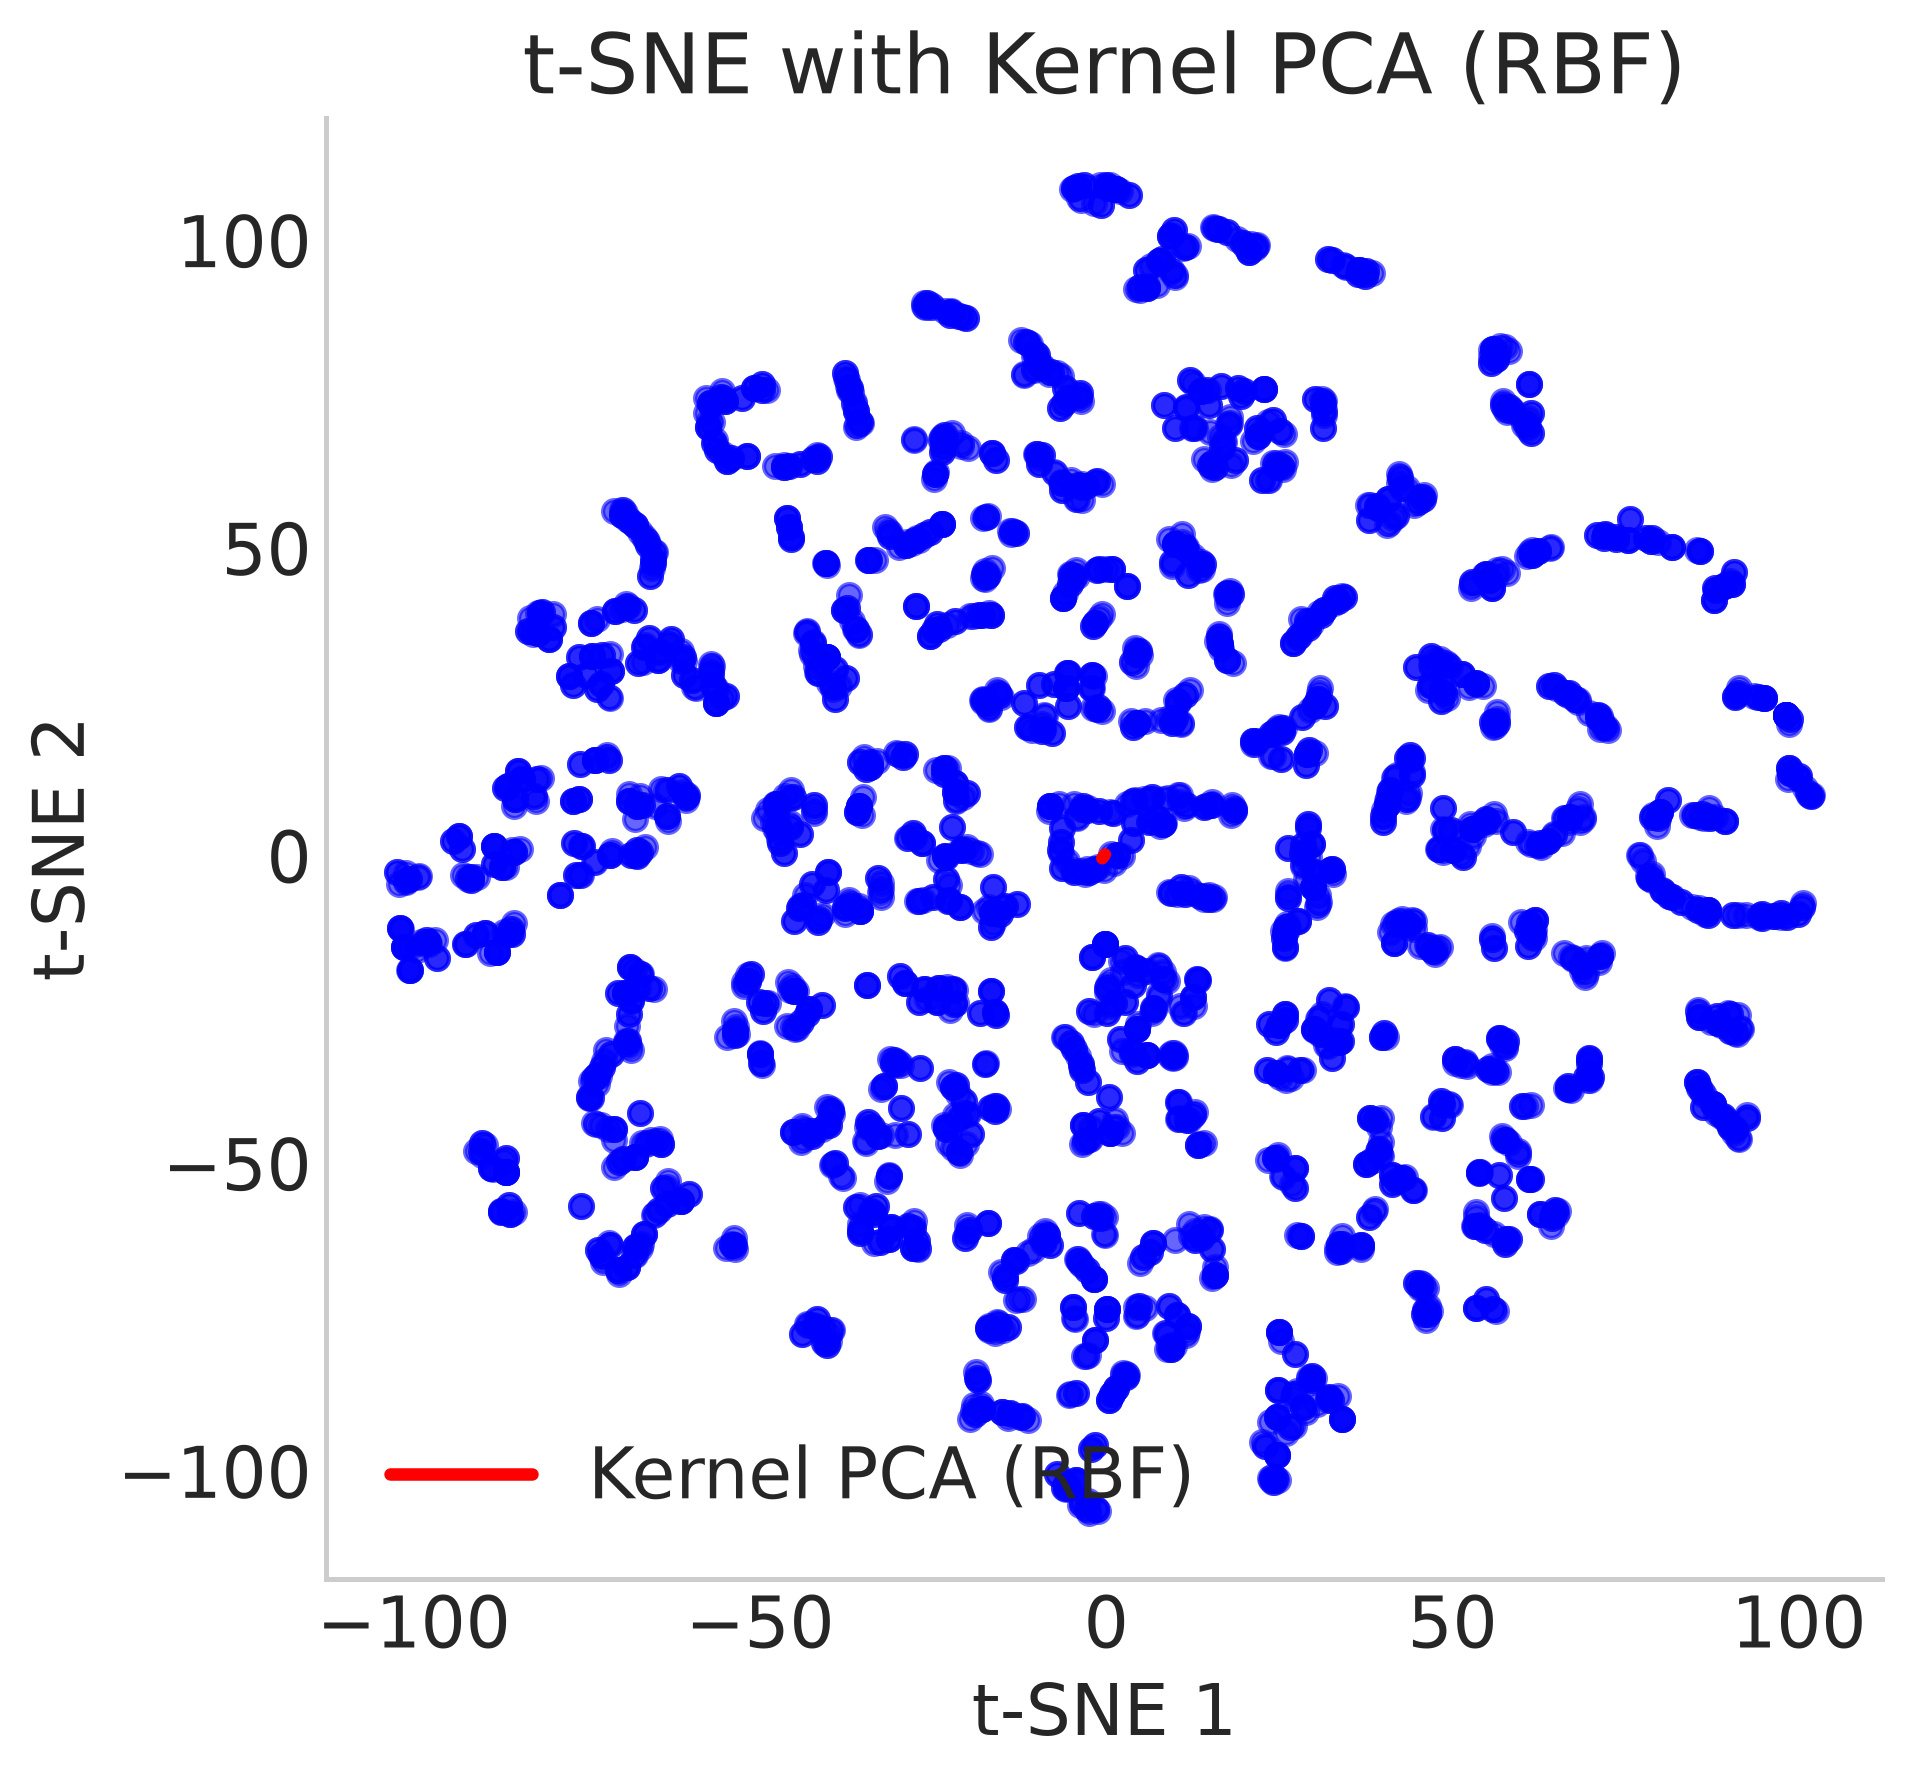

Saved: /home/youssef/projects/Sim-Equity/outputs/figures/dimensionality_reduction/tsne_with_kpca_poly.png


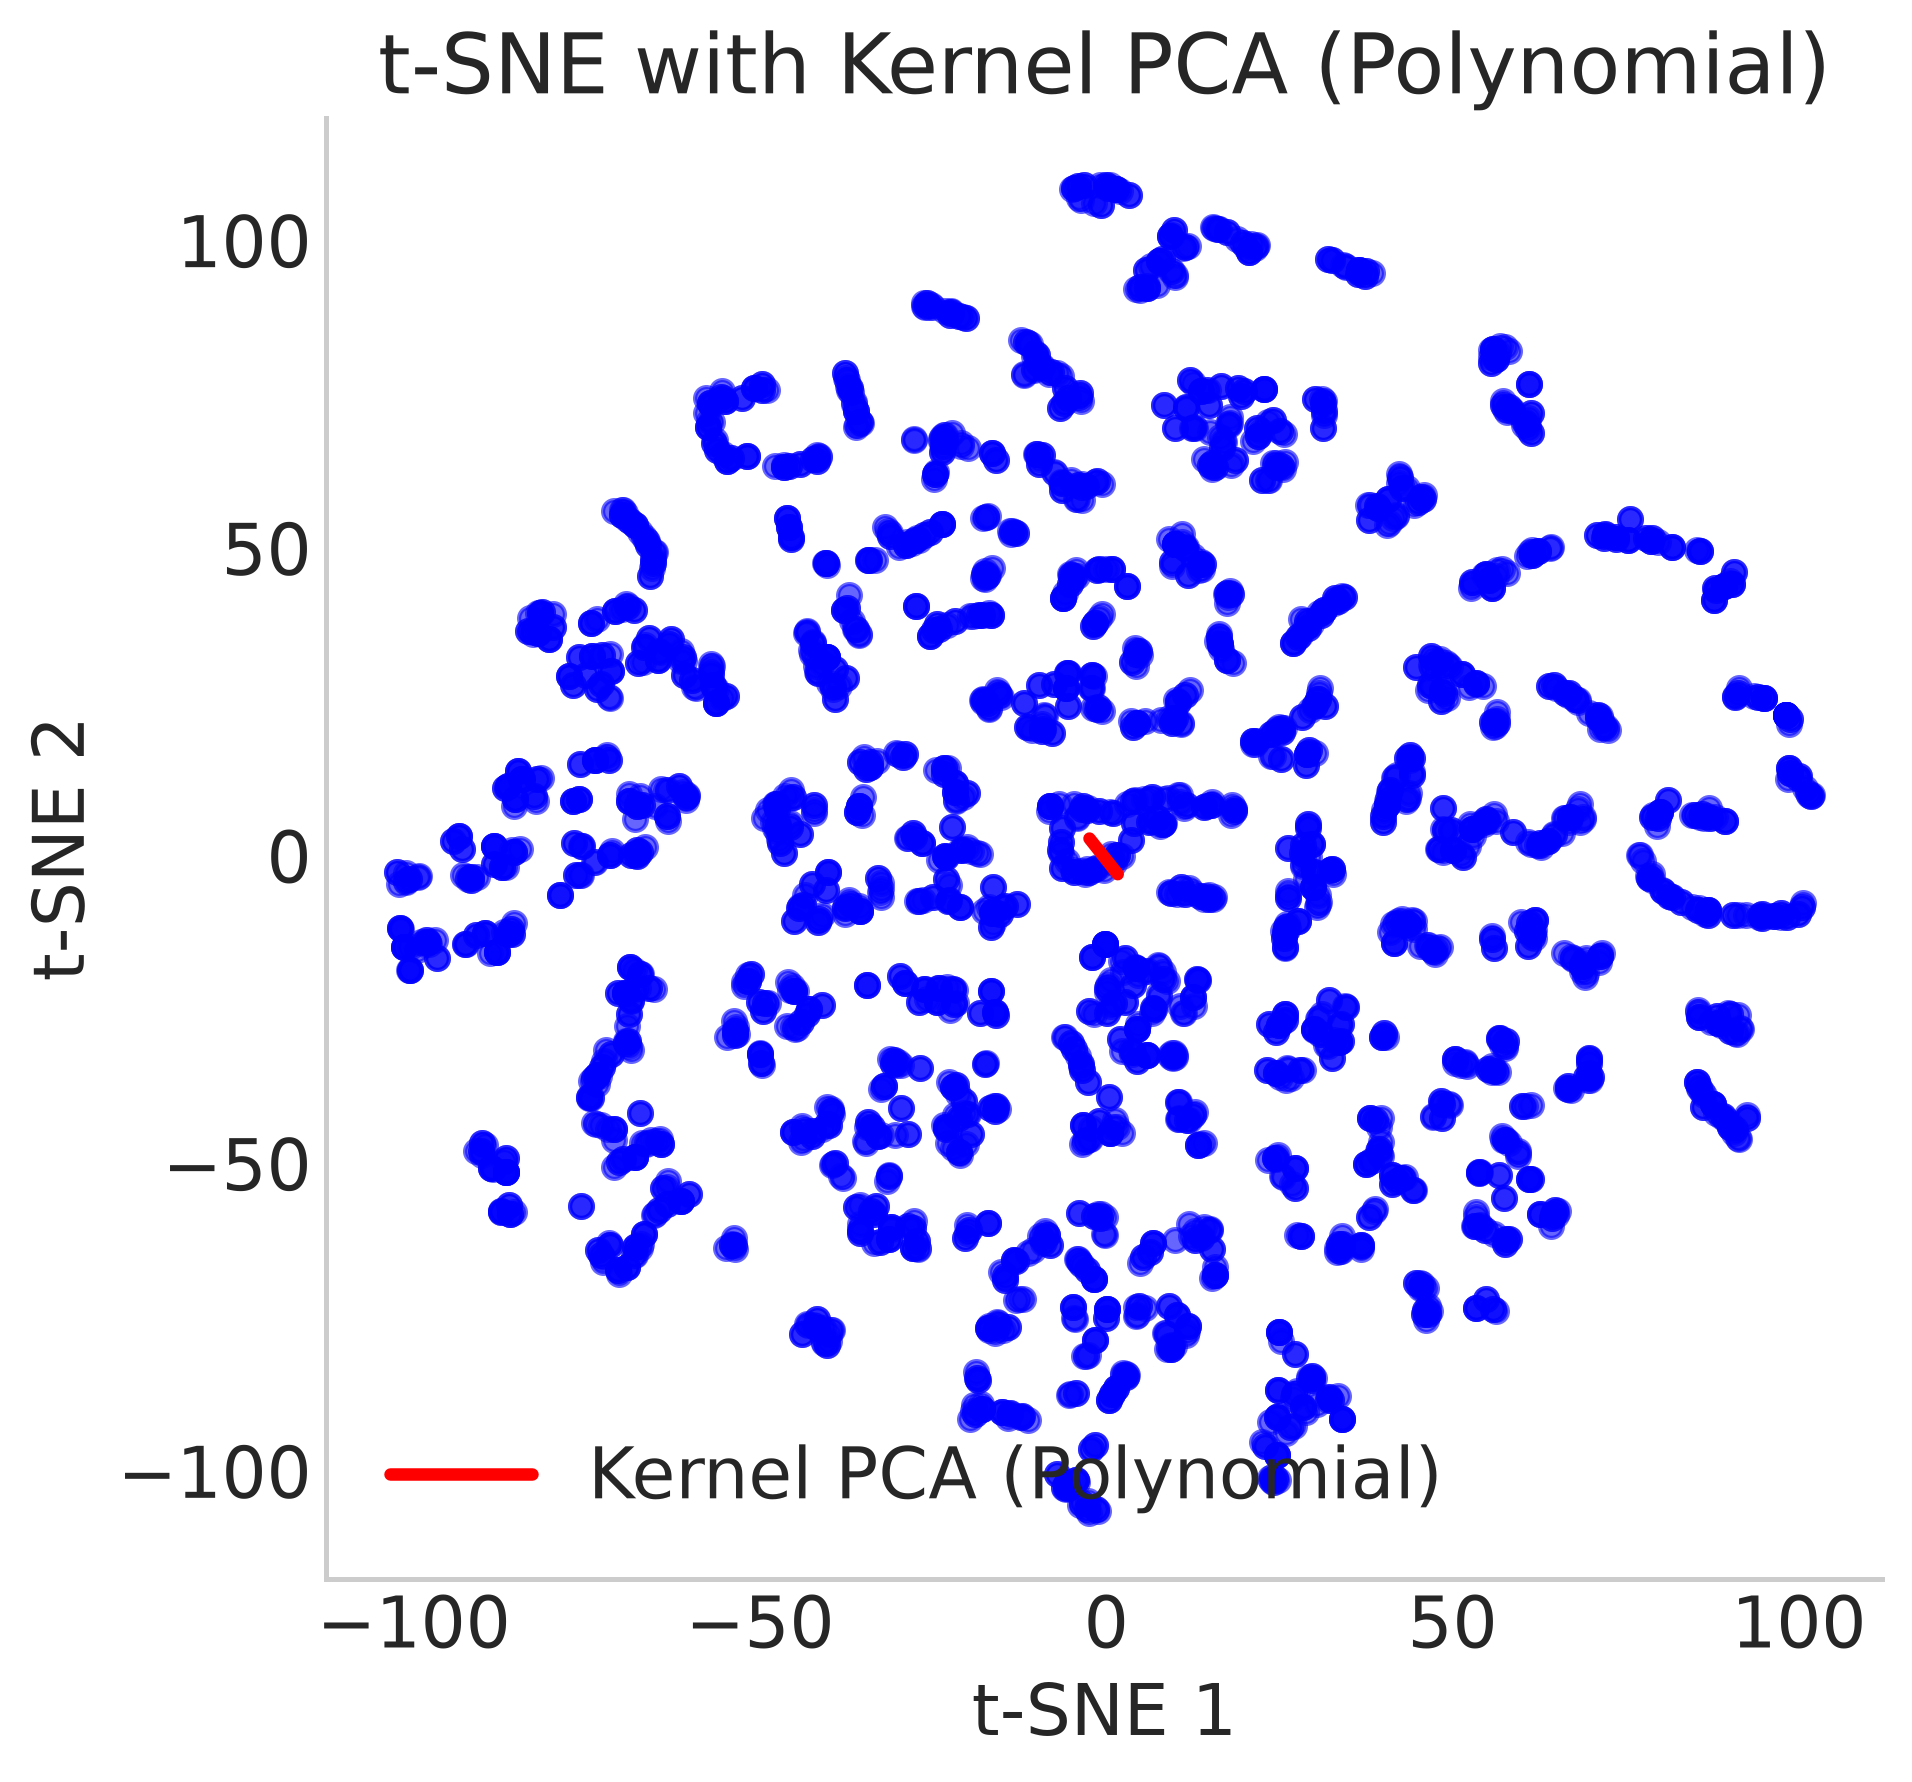

Saved: /home/youssef/projects/Sim-Equity/outputs/figures/dimensionality_reduction/tsne_with_ica.png


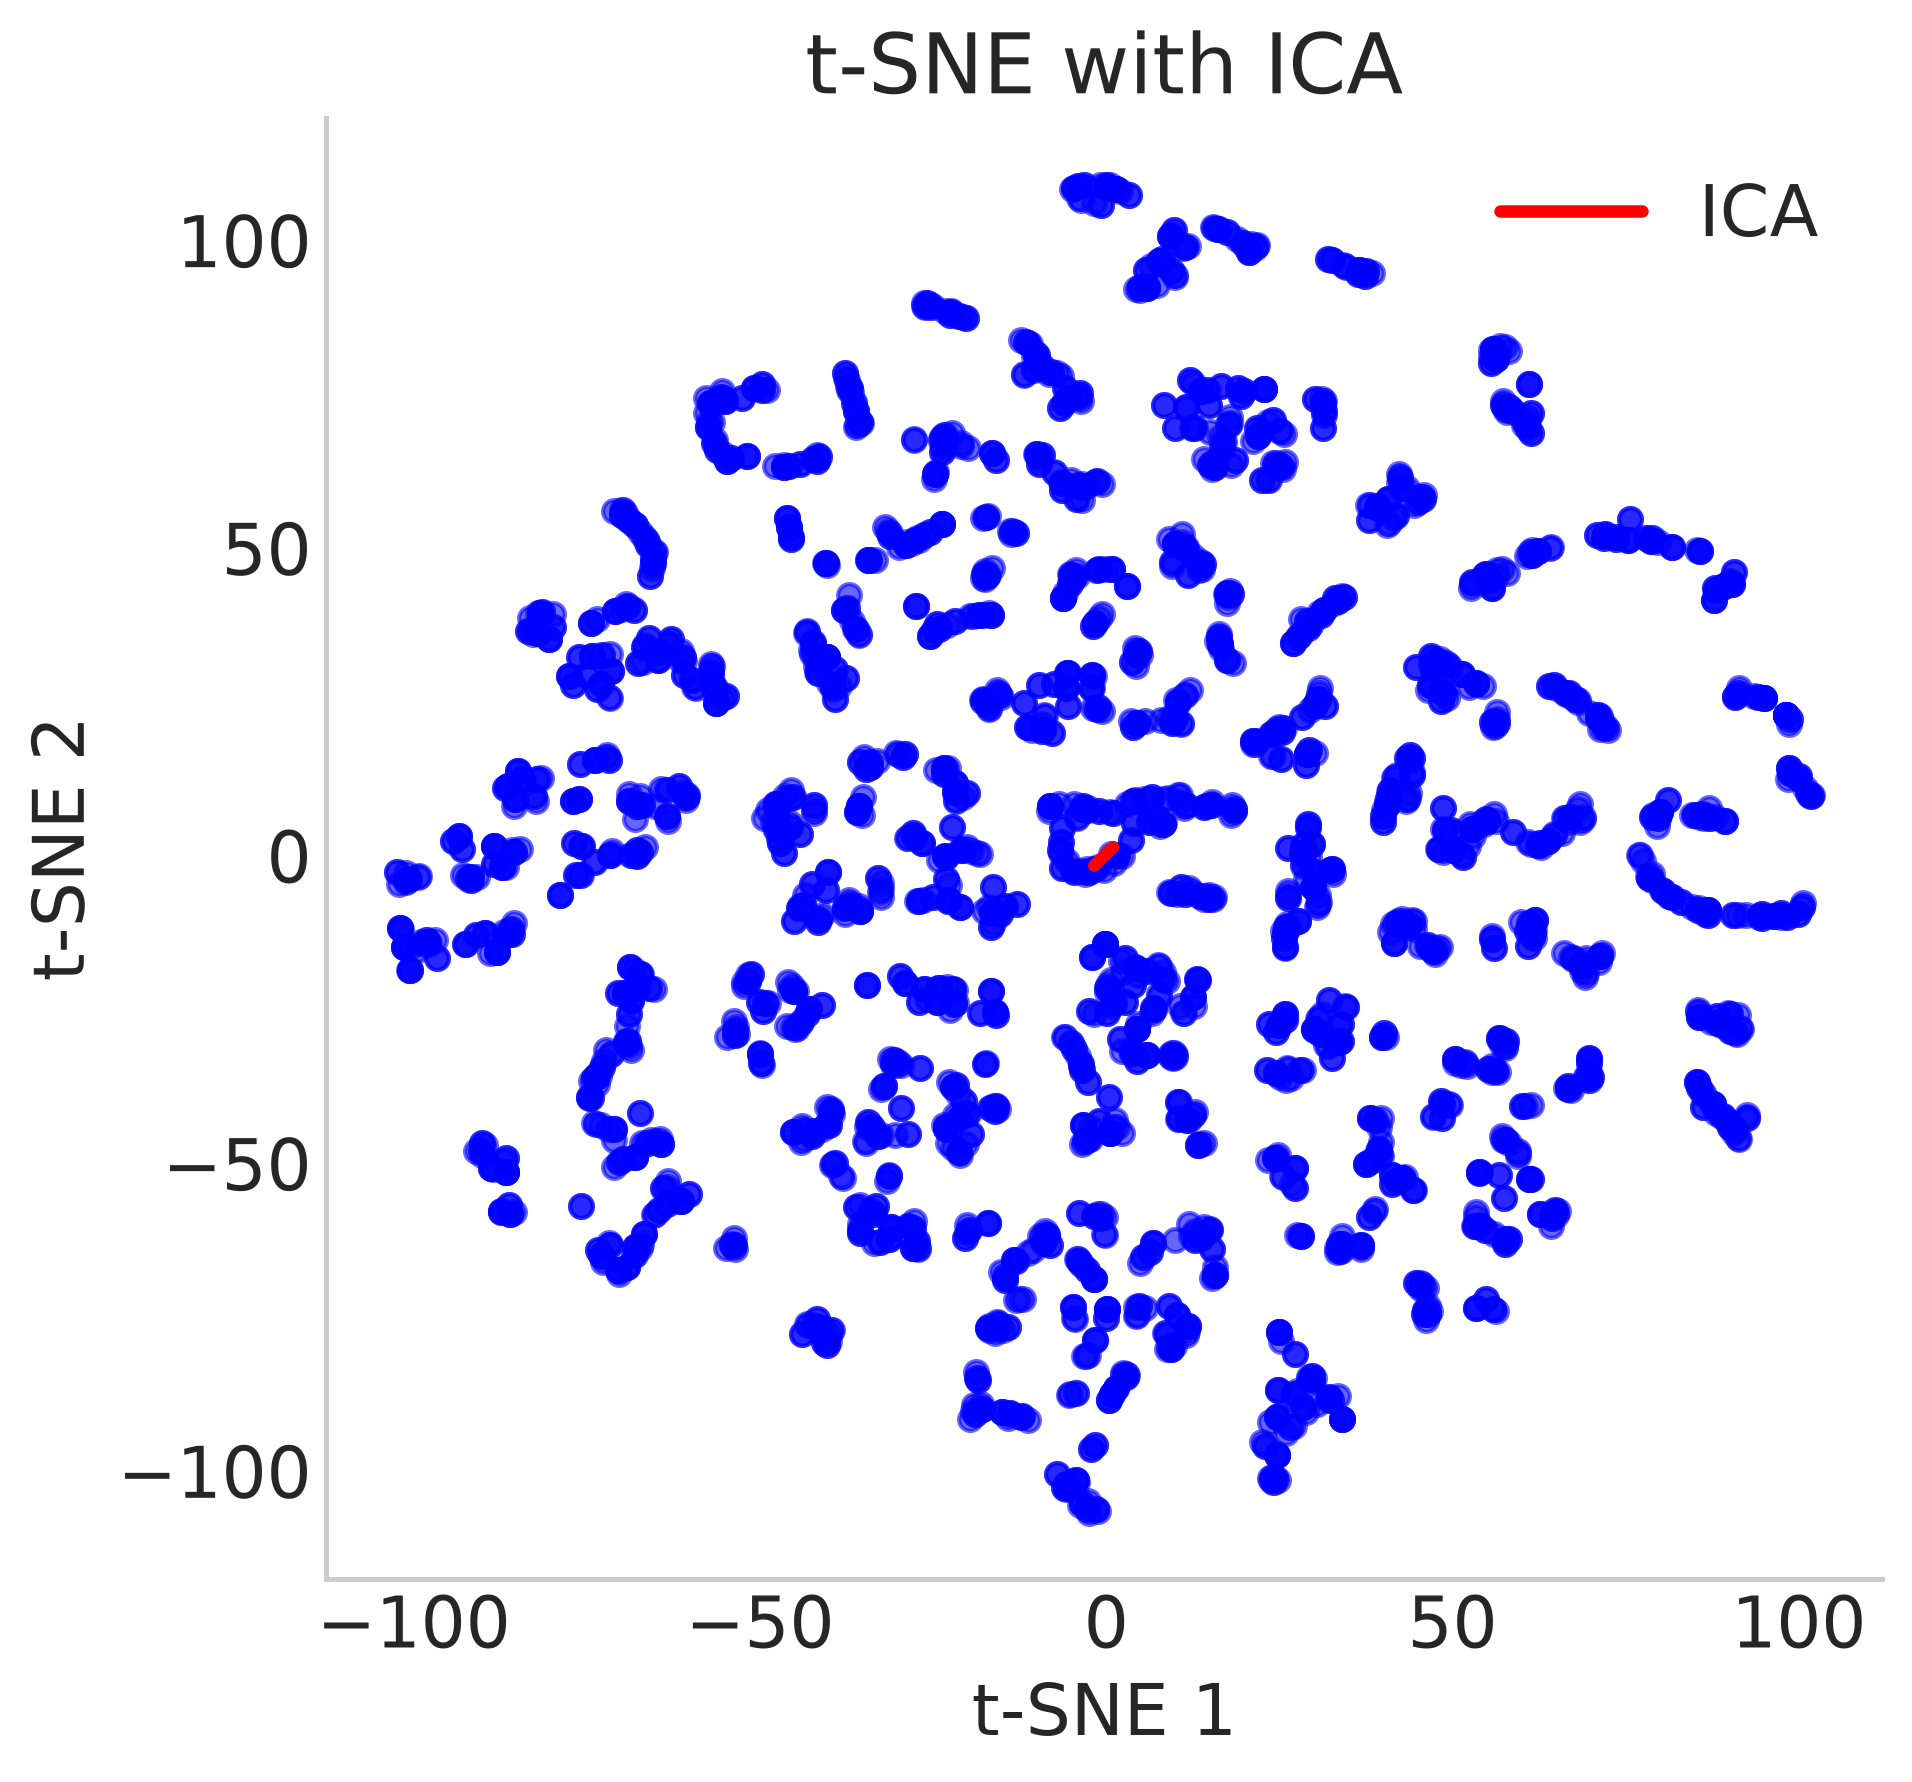

(array([[ 86.0827   ,   6.7342043],
        [ 85.0681   ,   6.5954847],
        [ 80.01528  ,   7.152519 ],
        ...,
        [ 45.92361  , -74.44555  ],
        [-65.32059  ,  49.35283  ],
        [-66.98912  ,   8.190228 ]], shape=(3000, 2), dtype=float32),
 FastICA(n_components=2, random_state=42))

In [18]:
def _build_tsne_reducer(method: str, random_state: int) -> tuple[Any, str]:
    """Instantiate the 2-component reducer and human-readable label for the given method."""
    from sklearn.decomposition import KernelPCA

    match method:
        case "pca":
            return PCA(n_components=2), "PCA"
        case "kpca_rbf":
            return (
                KernelPCA(n_components=2, kernel="rbf", random_state=random_state),
                "Kernel PCA (RBF)",
            )
        case "kpca_sigmoid":
            return (
                KernelPCA(n_components=2, kernel="sigmoid", random_state=random_state),
                "Kernel PCA (Sigmoid)",
            )
        case "kpca_poly":
            return (
                KernelPCA(
                    n_components=2, kernel="poly", degree=3, random_state=random_state
                ),
                "Kernel PCA (Polynomial)",
            )
        case "ica":
            return FastICA(n_components=2, random_state=random_state), "ICA"
        case "factor_analysis":
            return (
                FactorAnalysis(n_components=2, random_state=random_state),
                "Factor Analysis",
            )
        case _:
            raise ValueError(f"Unknown dimensionality reduction method: '{method}'")


def _get_principal_direction(reducer: Any) -> np.ndarray:
    """Extract the first principal direction from a fitted reducer."""
    if hasattr(reducer, "components_"):
        return reducer.components_[0]
    if hasattr(reducer, "eigenvectors_"):
        return reducer.eigenvectors_[0]
    return np.array([1.0, 0.0])  # fallback for reducers with no accessible direction


def tsne_with_method_line(
        df: pl.DataFrame,
        columns: list[str],
        method: str = "pca",
        perplexity: int = 10,
        random_state: int = GLOBAL_SEED,
        max_samples: int | None = 3000,
        tsne_embedding: np.ndarray | None = None,
) -> tuple[np.ndarray, Any]:
    """
    Visualize t-SNE-reduced data with the first principal direction of a chosen reducer.

    Parameters
    ----------
    df : Polars DataFrame containing the features.
    columns : Columns of df to use for reduction.
    method : One of 'pca', 'kpca_rbf', 'kpca_sigmoid', 'kpca_poly', 'ica', 'factor_analysis'.
    perplexity : t-SNE perplexity parameter.
    random_state : Random seed for reproducibility.
    max_samples : Maximum number of rows to sample to prevent memory exhaustion
                  during KernelPCA Gram matrix construction and t-SNE computation.
    tsne_embedding : Optional pre-computed t-SNE embedding array to reuse across calls.

    Returns
    -------
    tsne_embedding : (n, 2) array of t-SNE coordinates.
    reducer : Fitted reducer object.
    """
    if tsne_embedding is None:
        if max_samples is not None and len(df) > max_samples:
            df = df.sample(n=max_samples, seed=random_state)

        X = StandardScaler().fit_transform(df.select(columns).to_numpy())

        tsne = TSNE(
            n_components=2, perplexity=perplexity, random_state=random_state, n_jobs=-1
        )
        tsne_embedding = tsne.fit_transform(X)

    reducer, method_name = _build_tsne_reducer(method, random_state)
    reducer.fit(tsne_embedding)
    pc1 = _get_principal_direction(reducer)

    # Project the principal direction through the t-SNE centroid for visualization.
    centroid = np.mean(tsne_embedding, axis=0)
    t_range = np.linspace(-100, 100, 100)
    direction_line = centroid + np.outer(t_range, pc1)

    fig, ax = plt.subplots()
    ax.scatter(
        tsne_embedding[:, 0], tsne_embedding[:, 1], alpha=0.6, s=30, color="blue"
    )
    ax.plot(
        direction_line[:, 0],
        direction_line[:, 1],
        color="red",
        linewidth=3,
        label=method_name,
    )
    ax.legend(loc="best")
    ax.set_title(f"t-SNE with {method_name}")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

    output_path = FIGURE_DIR / "dimensionality_reduction" / f"tsne_with_{method}.png"
    output_path.parent.mkdir(parents=True, exist_ok=True)
    savefig_standard(output_path)
    plt.show()

    return tsne_embedding, reducer


# Compare all methods directly — wrapper functions removed in favour of explicit calls.
tsne_embedding, _ = tsne_with_method_line(are_correlated_raw, feature_columns, method="pca")
tsne_with_method_line(are_correlated_raw, feature_columns, method="kpca_sigmoid", tsne_embedding=tsne_embedding)
tsne_with_method_line(are_correlated_raw, feature_columns, method="kpca_rbf", tsne_embedding=tsne_embedding)
tsne_with_method_line(are_correlated_raw, feature_columns, method="kpca_poly", tsne_embedding=tsne_embedding)
tsne_with_method_line(are_correlated_raw, feature_columns, method="ica", tsne_embedding=tsne_embedding)



# Building the SVI

## Standardizing Data and applying PCA to it

In [19]:
def get_loadings(df: pl.DataFrame) -> dict[str, float]:
    """Fit PCA on one component and return per-feature absolute loadings."""
    col_names = df.columns
    X_scaled = StandardScaler().fit_transform(df.to_numpy())
    pca = PCA(n_components=1)
    pca.fit(X_scaled)
    print(pca.components_)
    return dict(zip(col_names, np.abs(pca.components_[0])))


def apply_loadings_to_cols(
        df: pl.DataFrame, loadings: dict[str, float]
) -> pl.DataFrame:
    """Scale each column in *df* by its corresponding PCA loading weight."""
    for col_name, weight in loadings.items():
        df = df.with_columns((pl.col(col_name) * weight))
    return df


loadings = get_loadings(are_correlated)
are_correlated = apply_loadings_to_cols(are_correlated, loadings)


[[-0.04097917  0.31670697 -0.10995441  0.4908867   0.06180375 -0.48608877
   0.24425439  0.40033558  0.19498191 -0.29404064 -0.12022467 -0.038609
  -0.20872566 -0.03062726]]


### Normalizing all Features bet. 0 & 1 to make all features particicpate equally in building the SVI

In [20]:
are_correlated = are_correlated.with_columns(
    sum=pl.sum_horizontal(feature_columns)
).rename({"sum": "SVI_raw"})


In [21]:
# Create normalized SVI column using polars expressions
are_correlated = are_correlated.with_columns(
    [
        (
                (pl.col("SVI_raw") - pl.col("SVI_raw").min())
                / (pl.col("SVI_raw").max() - pl.col("SVI_raw").min())
        ).alias("SVI_normalized")
    ]
)



In [22]:
ids = individuals_with_trips_df.select("ID", "WEIGHT_INDIV", "CODGEO", "AREA_NAME")

out_df = pl.concat(
    [ids, are_correlated.select(["SVI_raw", "SVI_normalized"])], how="horizontal"
)



/tmp/ipykernel_153572/1763430820.py:3: DeprecationWarning: the default behavior of `how='horizontal'` for `concat` is deprecated and will require equal heights in the next breaking release. Use `how='horizontal_extend'` to keep the current behavior.
(Deprecated in version 1.42.1)
  out_df = pl.concat(


In [47]:
out_df.write_csv(DATA_DIR / "agents_svi_scores.csv")

## Critical Visualization

In [23]:
(FIGURE_DIR / "relationships_with_svi").mkdir(parents=True, exist_ok=True)
(FIGURE_DIR / "svi_analysis").mkdir(parents=True, exist_ok=True)



In [24]:
def plot_transformation_relationship(
        original_df: pl.DataFrame,
        transformed_df: pl.DataFrame,
        feature_name: str,
) -> None:
    """
    Create a scatter plot showing original vs transformed feature values.

    Parameters
    ----------
    original_df : DataFrame containing the original (un-transformed) feature.
    transformed_df : DataFrame containing the TRANSFORMED_ prefixed column.
    feature_name : Feature name without the 'TRANSFORMED_' prefix.
    """
    original_col = feature_name
    transformed_col = f"TRANSFORMED_{feature_name}"

    original_mean = original_df[original_col].mean()
    transformed_mean = transformed_df[transformed_col].mean()

    fig, ax = plt.subplots()

    sc = ax.scatter(
        x=original_df[original_col],
        y=transformed_df[transformed_col],
        c=original_df[original_col],
        cmap=CMAP,
        alpha=ALPHA,
        s=100,
        edgecolors="none",
    )

    ax.axhline(
        y=transformed_mean,
        color="red",
        linestyle="--",
        label=f"Mean Transformed: {transformed_mean:.2f}",
    )
    ax.axvline(
        x=original_mean,
        color="blue",
        linestyle="--",
        label=f"Mean Original: {original_mean:.2f}",
    )

    cbar = plt.colorbar(sc)
    cbar.set_label(f"Original {original_col}")

    ax.set_title(f"{original_col} vs. Transformed")
    ax.set_xlabel(f"Original {original_col}")
    ax.set_ylabel(f"Transformed {original_col}")
    ax.grid(True, alpha=0.3)

    output_path = (
            FIGURE_DIR
            / "relationships_with_transformations"
            / f"transformation_{feature_name}.png"
    )
    output_path.parent.mkdir(parents=True, exist_ok=True)
    savefig_standard(output_path)
    plt.close()


for feature in [
    "AGE",
    "DIPLOMA",
    "NB_CAR",
    "NBPERS_HOUSE",
    "TWO_WHEELER",
    "BIKE",
    "ELECT_SCOOTER",
]:
    plot_transformation_relationship(individuals_with_trips_df, are_correlated, feature)


Saved: /home/youssef/projects/Sim-Equity/outputs/figures/relationships_with_transformations/transformation_AGE.png
Saved: /home/youssef/projects/Sim-Equity/outputs/figures/relationships_with_transformations/transformation_DIPLOMA.png
Saved: /home/youssef/projects/Sim-Equity/outputs/figures/relationships_with_transformations/transformation_NB_CAR.png
Saved: /home/youssef/projects/Sim-Equity/outputs/figures/relationships_with_transformations/transformation_NBPERS_HOUSE.png
Saved: /home/youssef/projects/Sim-Equity/outputs/figures/relationships_with_transformations/transformation_TWO_WHEELER.png
Saved: /home/youssef/projects/Sim-Equity/outputs/figures/relationships_with_transformations/transformation_BIKE.png
Saved: /home/youssef/projects/Sim-Equity/outputs/figures/relationships_with_transformations/transformation_ELECT_SCOOTER.png


In [25]:
def create_styled_scatter_plot(
        data: pl.DataFrame, feature_name: str, target: str = "SVI_raw"
) -> None:
    """
    Create a scatter plot of a feature against the SVI, with color encoding.

    For TRANSFORMED_ columns the color scale uses the corresponding original feature.
    """
    svi_mean = data[target].drop_nans().mean()
    feature_mean = data[feature_name].mean()

    original_feature = feature_name.replace("TRANSFORMED_", "")
    color_source = (
        individuals_with_trips_df[original_feature]
        if "TRANSFORMED_" in feature_name
        else data[feature_name]
    )

    fig, ax = plt.subplots()

    sc = ax.scatter(
        x=data[feature_name],
        y=data[target],
        c=color_source,
        cmap=CMAP,
        alpha=ALPHA,
        s=100,
        edgecolors="none",
    )

    ax.axhline(
        y=svi_mean, color="red", linestyle="--", label=f"Mean SVI: {svi_mean:.2f}"
    )
    ax.axvline(
        x=feature_mean,
        color="blue",
        linestyle="--",
        label=f"Mean {feature_name}: {feature_mean:.2f}",
    )

    title = f"{feature_name} vs. SVI"
    ax.set_title(title, pad=20, fontweight="bold")
    ax.set_xlabel(feature_name)
    ax.set_ylabel("Social Vulnerability Index (SVI)")
    ax.grid(True, linestyle="--", alpha=0.3)

    cbar = plt.colorbar(sc)
    cbar.set_label(
        original_feature if "TRANSFORMED_" in feature_name else feature_name,
        rotation=270,
        labelpad=15,
    )

    savefig_standard(FIGURE_DIR / "relationships_with_svi" / f"{title}.png")
    plt.close()


for col in feature_columns:
    create_styled_scatter_plot(are_correlated, col)


Saved: /home/youssef/projects/Sim-Equity/outputs/figures/relationships_with_svi/SEX vs. SVI.png
Saved: /home/youssef/projects/Sim-Equity/outputs/figures/relationships_with_svi/TRANSFORMED_AGE vs. SVI.png
Saved: /home/youssef/projects/Sim-Equity/outputs/figures/relationships_with_svi/TRANSFORMED_DIPLOMA vs. SVI.png
Saved: /home/youssef/projects/Sim-Equity/outputs/figures/relationships_with_svi/TRANSFORMED_NB_CAR vs. SVI.png
Saved: /home/youssef/projects/Sim-Equity/outputs/figures/relationships_with_svi/PMR vs. SVI.png
Saved: /home/youssef/projects/Sim-Equity/outputs/figures/relationships_with_svi/TRANSFORMED_NBPERS_HOUSE vs. SVI.png
Saved: /home/youssef/projects/Sim-Equity/outputs/figures/relationships_with_svi/TRANSFORMED_TWO_WHEELER vs. SVI.png
Saved: /home/youssef/projects/Sim-Equity/outputs/figures/relationships_with_svi/TRANSFORMED_BIKE vs. SVI.png
Saved: /home/youssef/projects/Sim-Equity/outputs/figures/relationships_with_svi/TRANSFORMED_ELECT_SCOOTER vs. SVI.png
Saved: /home/yous

Saved: /home/youssef/projects/Sim-Equity/outputs/figures/age_vs_svi.png


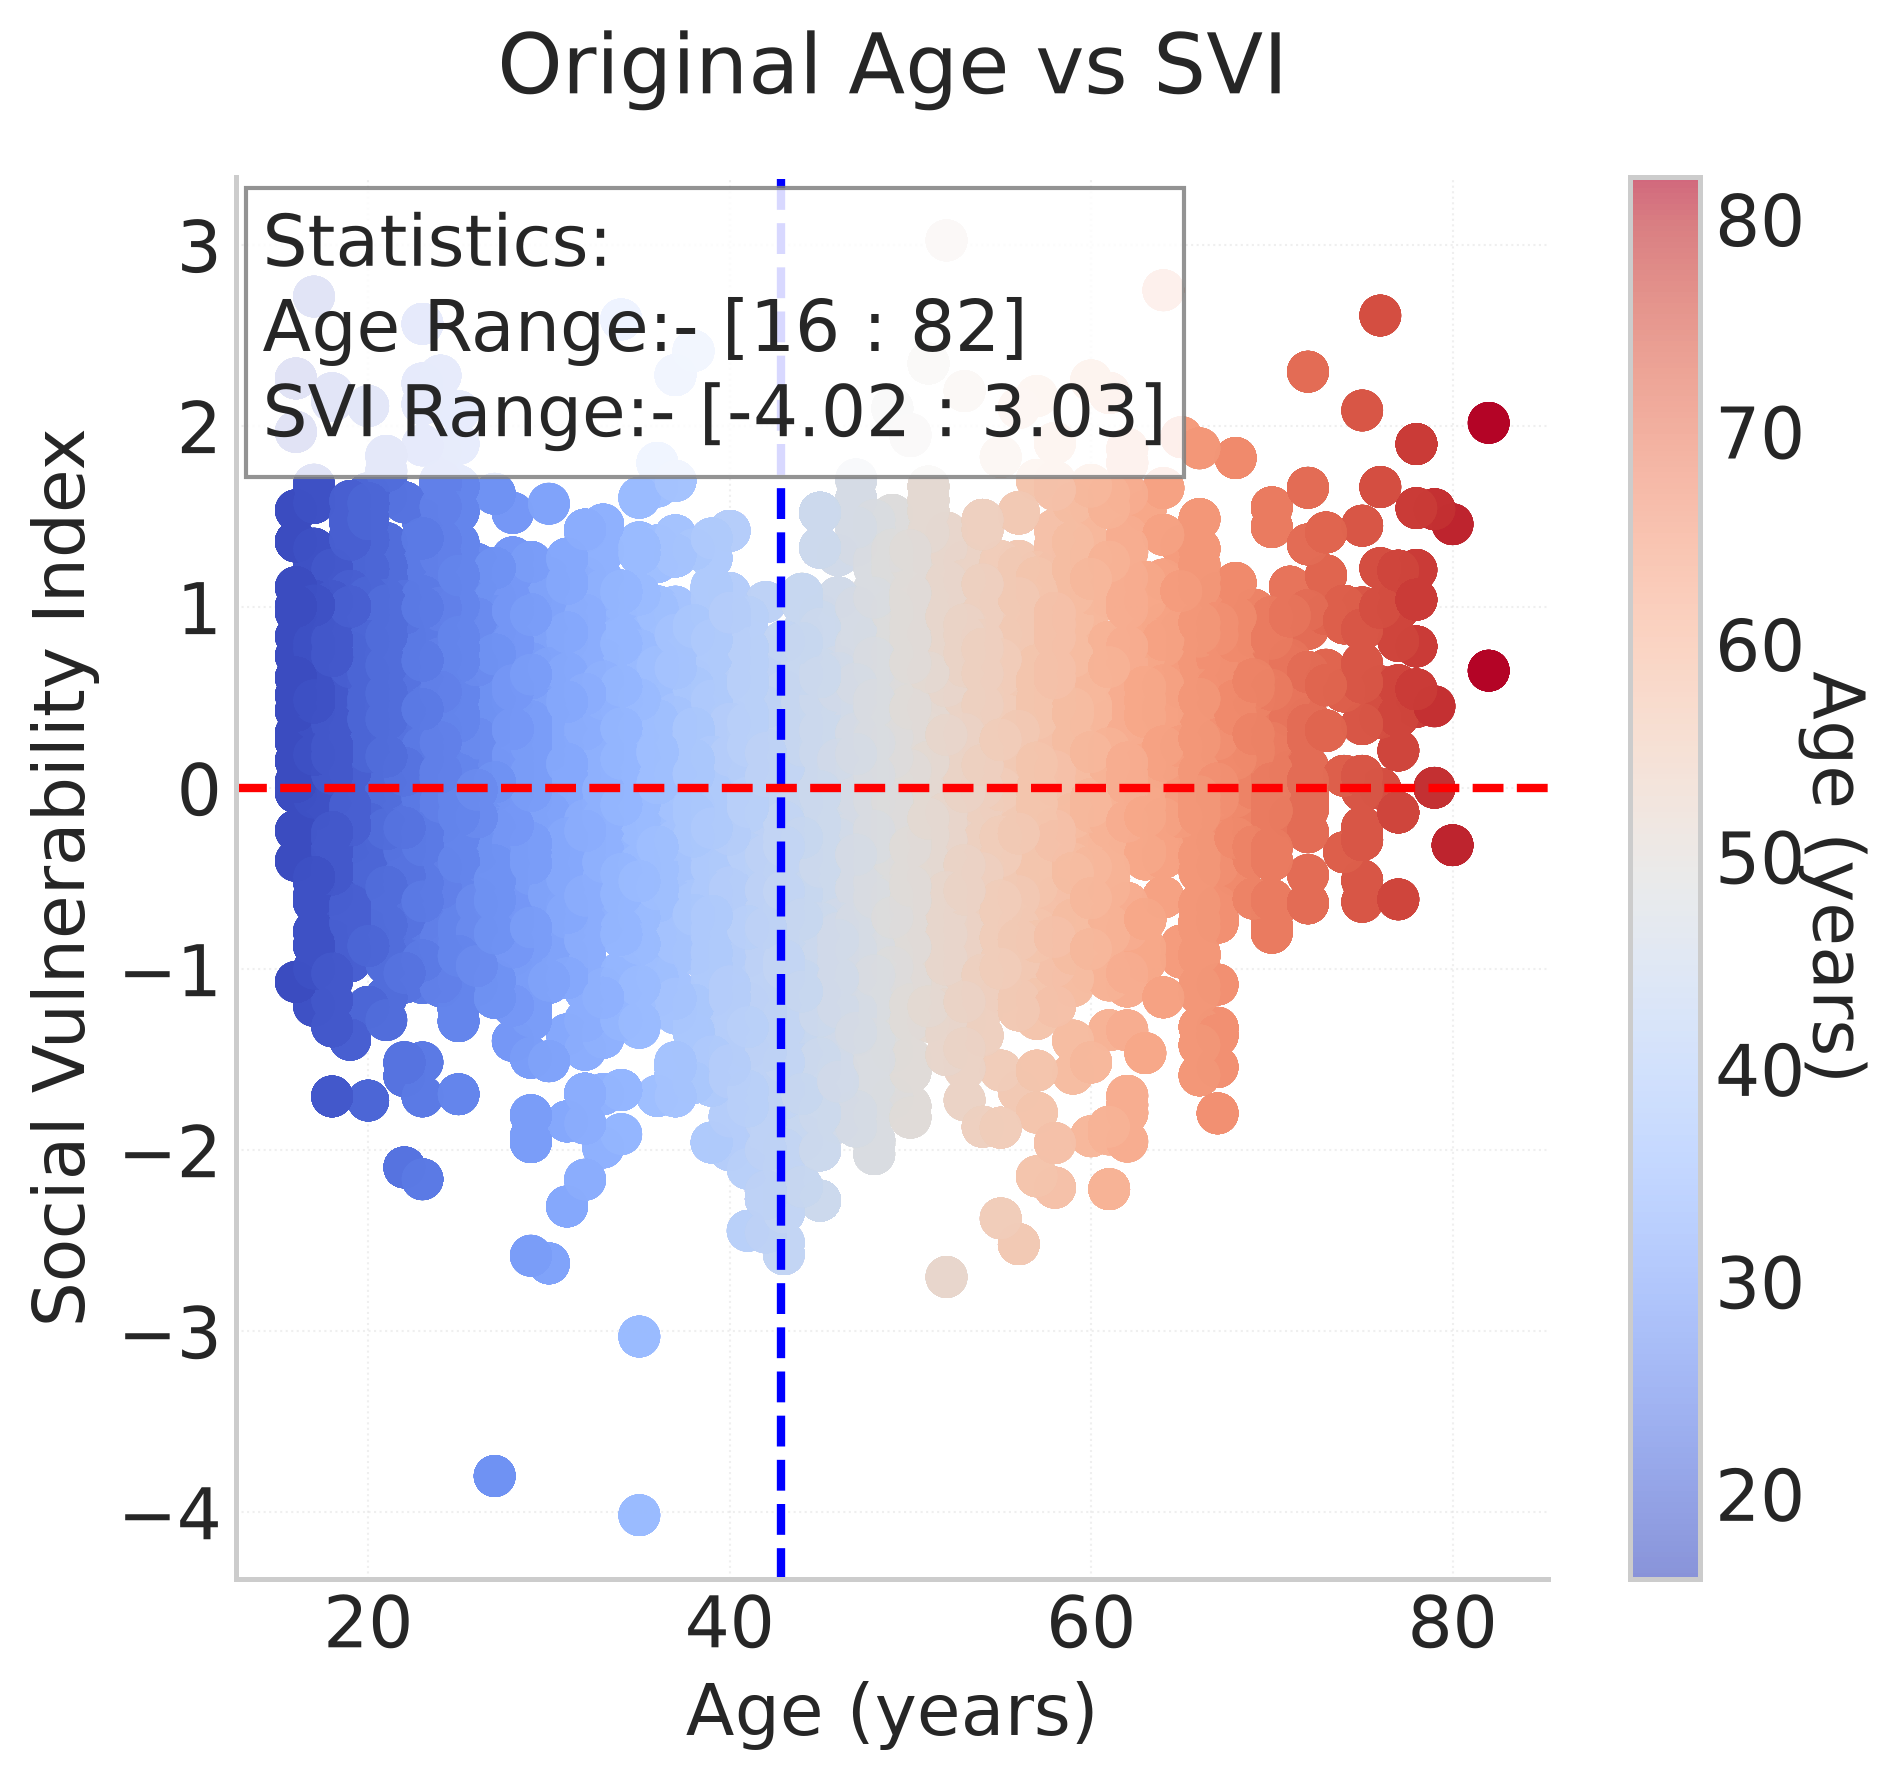

In [26]:
fig, ax = plt.subplots()

age_mean = individuals_with_trips_df["AGE"].mean()
svi_mean = are_correlated["SVI_raw"].mean()

scatter = ax.scatter(
    x=individuals_with_trips_df["AGE"],
    y=are_correlated["SVI_raw"],
    alpha=ALPHA,
    c=individuals_with_trips_df["AGE"],
    cmap=CMAP,
    s=100,
    edgecolors="none",
    label="Individual Data Points",
)

ax.axvline(
    x=age_mean,
    color="blue",
    linestyle="--",
    linewidth=2,
    label=f"Mean Age: {age_mean:.1f} years",
)
ax.axhline(
    y=svi_mean,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean SVI: {svi_mean:.3f}",
)

ax.set_title("Original Age vs SVI", pad=20)
ax.set_xlabel("Age (years)")
ax.set_ylabel("Social Vulnerability Index")
ax.grid(True, alpha=0.3, linestyle=":")

cbar = plt.colorbar(scatter)
cbar.set_label("Age (years)", rotation=270, labelpad=15)

stats_text = (
    f"Statistics:\n"
    f'Age Range:- [{individuals_with_trips_df["AGE"].min():.0f} : {individuals_with_trips_df["AGE"].max():.0f}]\n'
    f'SVI Range:- [{are_correlated["SVI_raw"].min():.2f} : {are_correlated["SVI_raw"].max():.2f}]'
)
ax.text(
    0.02,
    0.98,
    stats_text,
    transform=ax.transAxes,
    bbox=dict(facecolor="white", alpha=0.85, edgecolor="gray"),
    verticalalignment="top",
)

savefig_standard(FIGURE_DIR / "age_vs_svi.png")


#### Some Sort of Analysis to SVI

In [27]:
# =============================================================================
# PLOT 1: Enhanced Boxplot
# =============================================================================
def create_svi_boxplot(data: np.ndarray, save: bool = True) -> tuple:
    """Create enhanced boxplot of SVI data with proper vulnerability zone layering."""
    data = np.asarray(data)
    fig, ax = plt.subplots(figsize=FIGSIZE)

    add_vulnerability_zones(ax, axis="x", alpha=0.15)

    ax.boxplot(
        data,
        vert=False,
        patch_artist=True,
        boxprops=dict(facecolor=PRIMARY_COLOR, alpha=0.8, linewidth=1.5),
        medianprops=dict(color="white", linewidth=2.5),
        whiskerprops=dict(color=PRIMARY_COLOR, linewidth=1.5),
        capprops=dict(color=PRIMARY_COLOR, linewidth=1.5),
        flierprops=dict(
            marker="o",
            markerfacecolor=SECONDARY_COLOR,
            markeredgecolor=SECONDARY_COLOR,
            markersize=4,
            alpha=0.7,
        ),
    )

    q1, median, q3 = np.percentile(data, [25, 50, 75])
    mean_val = np.mean(data)

    ax.text(
        median,
        1.25,
        f"Median: {median:.3f}",
        ha="center",
        va="bottom",
        fontsize=ANNOT_FONTSIZE,
        fontweight="bold",
        color=PRIMARY_COLOR,
        bbox=dict(
            boxstyle="round,pad=0.15",
            facecolor="white",
            alpha=0.8,
            edgecolor=PRIMARY_COLOR,
        ),
    )
    ax.text(
        q1,
        0.78,
        f"Q1: {q1:.3f}",
        ha="right",
        va="top",
        fontsize=ANNOT_FONTSIZE - 3,
        color=PRIMARY_COLOR,
        fontweight="semibold",
    )
    ax.text(
        q3,
        0.72,
        f"Q3: {q3:.3f}",
        ha="left",
        va="top",
        fontsize=ANNOT_FONTSIZE - 3,
        color=PRIMARY_COLOR,
        fontweight="semibold",
    )
    ax.text(
        mean_val,
        0.6,
        f"Mean: {mean_val:.3f}",
        ha="center",
        va="top",
        fontsize=ANNOT_FONTSIZE - 3,
        color=ACCENT_COLOR,
        fontweight="semibold",
    )

    zone_labels = [
        (0.125, "Low\nVulnerability", "low"),
        (0.375, "Moderate\nVulnerability", "moderate"),
        (0.625, "High\nVulnerability", "high"),
        (0.875, "Very High\nVulnerability", "very_high"),
    ]
    for x_pos, label, level in zone_labels:
        ax.text(
            x_pos,
            1.4,
            label,
            ha="center",
            va="center",
            fontsize=ANNOT_FONTSIZE - 4,
            fontweight="bold",
            color=VULNERABILITY_COLORS[level],
        )

    ax.set_xlabel("Social Vulnerability Index (SVI) scores", fontweight="bold")
    ax.set_ylabel("Distribution", fontweight="bold")
    ax.set_title(
        "Distribution of Social Vulnerability Index (SVI) Scores",
        fontweight="bold",
        pad=25,
    )
    ax.set_xlim(0, 1)
    ax.set_ylim(0.5, 1.6)
    setup_academic_grid(ax, axis="x")
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
        spine.set_color(GRID_COLOR)

    if save:
        savefig_standard(FIGURE_DIR / "svi_analysis" / "svi_boxplot_analysis.png")

    plt.tight_layout()
    return fig, ax


# =============================================================================
# PLOT 2: Histogram with Density Curve
# =============================================================================
def create_svi_histogram(data: np.ndarray, save: bool = True) -> tuple:
    """Create histogram with density overlay and proper vulnerability zone layering."""
    data = np.asarray(data)
    fig, ax = plt.subplots(figsize=FIGSIZE)

    add_vulnerability_zones(ax, axis="x", alpha=0.15)

    ax.hist(
        data,
        bins=30,
        alpha=0.75,
        color=PRIMARY_COLOR,
        edgecolor="white",
        linewidth=0.8,
        density=True,
        label="Observed Distribution",
    )

    density = gaussian_kde(data)
    xs = np.linspace(data.min(), data.max(), 200)
    ax.plot(
        xs,
        density(xs),
        color=SECONDARY_COLOR,
        linewidth=3,
        label="Kernel Density Estimate",
        alpha=0.9,
    )

    y_max = ax.get_ylim()[1]
    label_height = y_max * 0.95
    zone_labels = [
        (0.125, "Low\nVulnerability", "low"),
        (0.375, "Moderate\nVulnerability", "moderate"),
        (0.625, "High\nVulnerability", "high"),
        (0.875, "Very High\nVulnerability", "very_high"),
    ]
    for x_pos, label, level in zone_labels:
        ax.text(
            x_pos,
            label_height,
            label,
            ha="center",
            va="top",
            fontsize=ANNOT_FONTSIZE - 4,
            fontweight="bold",
            color=VULNERABILITY_COLORS[level],
            alpha=0.8,
        )

    stats_text = f"n = {len(data):,}\nStd = {np.std(data):.3f}\nSkewness = {stats.skew(data):.3f}"
    ax.text(
        0.98,
        0.02,
        stats_text,
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=ANNOT_FONTSIZE - 4,
        bbox=dict(
            boxstyle="round,pad=0.15",
            facecolor="white",
            alpha=0.65,
            edgecolor=GRID_COLOR,
            linewidth=1,
        ),
    )

    ax.set_xlabel("Social Vulnerability Index (SVI) Score", fontweight="bold")
    ax.set_ylabel("Probability Density", fontweight="bold")
    ax.set_title(
        "Histogram and Density Distribution of SVI Scores", fontweight="bold", pad=25
    )
    ax.set_xlim(0, 1)
    setup_academic_grid(ax)

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
        spine.set_color(GRID_COLOR)

    if save:
        savefig_standard(FIGURE_DIR / "svi_analysis" / "svi_histogram_density.png")

    plt.tight_layout()
    return fig, ax


# =============================================================================
# PLOT 3: Empirical Cumulative Distribution Function
# =============================================================================


# =============================================================================
# PLOT 4: Violin Plot
# =============================================================================


# =============================================================================
# PLOT 5: Q-Q Plot for Normality Assessment
# =============================================================================
def create_svi_qqplot(data: np.ndarray, save: bool = True) -> tuple:
    """Create enhanced Q-Q plot for normality assessment with comprehensive statistics."""
    data = np.asarray(data)
    fig, ax = plt.subplots(figsize=FIGSIZE)

    stats.probplot(data, dist="norm", plot=ax)

    line = ax.get_lines()[0]  # Q-Q reference line
    line.set_color(SECONDARY_COLOR)
    line.set_linewidth(3)
    line.set_alpha(0.9)
    line.set_label("Normal Reference Line")

    points = ax.get_lines()[1]  # Data points
    points.set_markerfacecolor(PRIMARY_COLOR)
    points.set_markeredgecolor("white")
    points.set_markeredgewidth(0.5)
    points.set_markersize(MARKER_SIZE / 6)
    points.set_alpha(0.7)
    points.set_label("Observed Quantiles")

    theoretical_quantiles = stats.norm.ppf(
        (np.arange(1, len(data) + 1) - 0.5) / len(data)
    )
    sample_quantiles = np.sort(data)
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        theoretical_quantiles, sample_quantiles
    )

    shapiro_stat, shapiro_p = stats.shapiro(data)
    is_normal = shapiro_p > 0.05 and r_value ** 2 > 0.95
    status_color = SUCCESS_COLOR if is_normal else WARNING_COLOR

    stats_text = (
        f"Fit Quality:\n" f"R² = {r_value ** 2:.4f}\n" f"Slope = {slope:.3f}\n\n"
    )
    ax.text(
        0.05,
        0.95,
        stats_text,
        transform=ax.transAxes,
        fontsize=ANNOT_FONTSIZE - 4,
        ha="left",
        va="top",
        bbox=dict(
            boxstyle="round,pad=0.5",
            facecolor="white",
            alpha=0.95,
            edgecolor=status_color,
            linewidth=2,
        ),
    )

    residuals = sample_quantiles - (slope * theoretical_quantiles + intercept)
    extreme_threshold = 2 * np.std(residuals)
    extreme_indices = np.where(np.abs(residuals) > extreme_threshold)[0]

    if len(extreme_indices) > 0:
        ax.scatter(
            theoretical_quantiles[extreme_indices],
            sample_quantiles[extreme_indices],
            color=DANGER_COLOR,
            s=MARKER_SIZE / 4,
            alpha=0.8,
            marker="x",
            linewidths=2,
            label="Extreme Deviations",
        )

    ax.set_xlabel(
        "Theoretical Quantiles (Standard Normal Distribution)", fontweight="bold"
    )
    ax.set_ylabel("Sample Quantiles (SVI Scores)", fontweight="bold")
    ax.set_title(
        f"Q-Q Plot: SVI Scores vs. Normal Distribution\nNormality Assessment (n = {len(data):,})",
        fontweight="bold",
        pad=25,
    )
    setup_academic_grid(ax)
    create_academic_legend(ax, title="Plot Components", loc="lower right")

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
        spine.set_color(GRID_COLOR)

    ax.set_aspect("auto")

    if save:
        savefig_standard(FIGURE_DIR / "svi_analysis" / "svi_qq_plot.png")

    plt.tight_layout()
    return fig, ax


# =============================================================================
# PLOT 6: Percentile Curve
# =============================================================================
def create_svi_percentile_curve(
        data: np.ndarray, save: bool = True
) -> tuple | tuple[None, None]:
    """Create enhanced percentile curve visualization with vulnerability zones."""
    data = np.asarray(data)
    clean_data = data[np.isfinite(data)]

    if len(clean_data) == 0:
        print("Error: No valid data points after cleaning!")
        return None, None

    fig, ax = plt.subplots(figsize=FIGSIZE)

    add_vulnerability_zones(ax, axis="y", alpha=0.15)

    percentiles = np.arange(0, 101, 1)
    percentile_values = np.percentile(clean_data, percentiles)

    ax.plot(
        percentiles,
        percentile_values,
        color=PRIMARY_COLOR,
        linewidth=3,
        alpha=0.9,
        label="Percentile Curve",
        zorder=3,
    )
    ax.fill_between(
        percentiles, percentile_values, alpha=0.3, color=PRIMARY_COLOR, zorder=2
    )

    key_percentiles = [10, 25, 50, 75, 95]
    key_values = np.percentile(clean_data, key_percentiles)

    ax.scatter(
        key_percentiles,
        key_values,
        color=ACCENT_COLOR,
        s=MARKER_SIZE * 1.5,
        edgecolors="white",
        linewidth=2,
        zorder=5,
        alpha=0.9,
        label="Key Percentiles",
    )

    annotation_offsets = [
        (20, -15, "bottom", "right"),
        (20, -15, "bottom", "right"),
        (20, -15, "bottom", "right"),
        (25, 0, "center", "left"),
        (50, -20, "bottom", "left"),
    ]
    for (p, v), (dx, dy, va, ha) in zip(
            zip(key_percentiles, key_values), annotation_offsets
    ):
        ax.annotate(
            f"P{p}: {v:.3f}",
            (p, v),
            xytext=(dx, dy),
            textcoords="offset points",
            fontsize=ANNOT_FONTSIZE - 4,
            va=va,
            ha=ha,
            bbox=dict(
                boxstyle="round,pad=0.3",
                facecolor="white",
                edgecolor=ACCENT_COLOR,
                alpha=0.9,
                linewidth=1,
            ),
            arrowprops=dict(arrowstyle="->", color=ACCENT_COLOR, alpha=0.8, lw=1.5),
            zorder=6,
        )

    vulnerability_thresholds = [
        (LOW_VULNERABILITY_MAX, "Low→Moderate", VULNERABILITY_COLORS["moderate"]),
        (MODERATE_VULNERABILITY_MAX, "Moderate→High", VULNERABILITY_COLORS["high"]),
        (HIGH_VULNERABILITY_MAX, "High→Very High", VULNERABILITY_COLORS["very_high"]),
    ]
    for i, (thresh, label, color) in enumerate(vulnerability_thresholds):
        pct_at_thresh = (clean_data <= thresh).mean() * 100
        ax.axhline(
            thresh, color=color, linestyle="--", alpha=0.8, linewidth=2, zorder=4
        )
        ax.axvline(
            pct_at_thresh,
            color=color,
            linestyle=":",
            alpha=0.6,
            linewidth=1.5,
            zorder=4,
        )
        label_x = 85 - (i * 15)
        ax.text(
            label_x,
            thresh + 0.1,
            f"{label}\n({pct_at_thresh:.1f}th %ile)",
            fontsize=ANNOT_FONTSIZE - 5,
            color=color,
            fontweight="bold",
            ha="right",
            va="bottom",
            bbox=dict(
                boxstyle="round,pad=0.3",
                facecolor="white",
                edgecolor=color,
                alpha=0.9,
                linewidth=1,
            ),
            zorder=6,
        )

    zone_axis_labels = [
        (102, 0.125, "Low\nVulnerability", "low"),
        (102, 0.375, "Moderate\nVulnerability", "moderate"),
        (102, 0.625, "High\nVulnerability", "high"),
        (102, 0.875, "Very High\nVulnerability", "very_high"),
    ]
    for x_pos, y_pos, label, level in zone_axis_labels:
        ax.text(
            x_pos,
            y_pos,
            label,
            ha="left",
            va="center",
            fontsize=ANNOT_FONTSIZE - 8,
            fontweight="bold",
            color=VULNERABILITY_COLORS[level],
            rotation=90,
        )

    ax.set_xlabel("Population Percentile", fontweight="bold")
    ax.set_ylabel("Social Vulnerability Index (SVI) Score", fontweight="bold")
    ax.set_title(
        "SVI Percentile Curve: Population Distribution Analysis",
        fontweight="bold",
        pad=25,
    )
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 1.05)
    setup_academic_grid(ax)
    create_academic_legend(ax, title="Components", loc="lower right")

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
        spine.set_color(GRID_COLOR)

    ax.set_xticks(np.arange(0, 101, 10))
    ax.set_yticks(np.arange(0, 1.1, 0.1))

    if save:
        savefig_standard(FIGURE_DIR / "svi_analysis" / "svi_percentile_curve.png")

    plt.tight_layout()
    return fig, ax


# =============================================================================
# MAIN EXECUTION FUNCTION
# =============================================================================
def create_all_svi_plots(data: np.ndarray, save_individual: bool = True) -> None:
    """Create all SVI diagnostic plots using global settings."""
    print("Creating comprehensive SVI visualization suite...")
    print("=" * 60)

    print("1. Creating enhanced boxplot...")
    create_svi_boxplot(data, save=save_individual)

    print("2. Creating histogram with density...")
    create_svi_histogram(data, save=save_individual)

    print("3. Creating empirical CDF...")

    print("4. Creating violin plot...")

    print("5. Creating Q-Q plot...")
    create_svi_qqplot(data, save=save_individual)

    print("6. Creating percentile curve...")
    create_svi_percentile_curve(data, save=save_individual)

    print("=" * 60)
    print("All plots created successfully!")
    if save_individual:
        print("Files saved:")
        print("• svi_boxplot_analysis.png")
        print("• svi_histogram_density.png")
        print("• svi_qq_plot.png")
        print("• svi_percentile_curve.png")



/tmp/ipykernel_153572/610505252.py:22: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax1.boxplot(


Saved: /home/youssef/projects/Sim-Equity/outputs/figures/svi_analysis/major statistic 2.png
Saved: /home/youssef/projects/Sim-Equity/outputs/figures/svi_analysis/major statistic.png


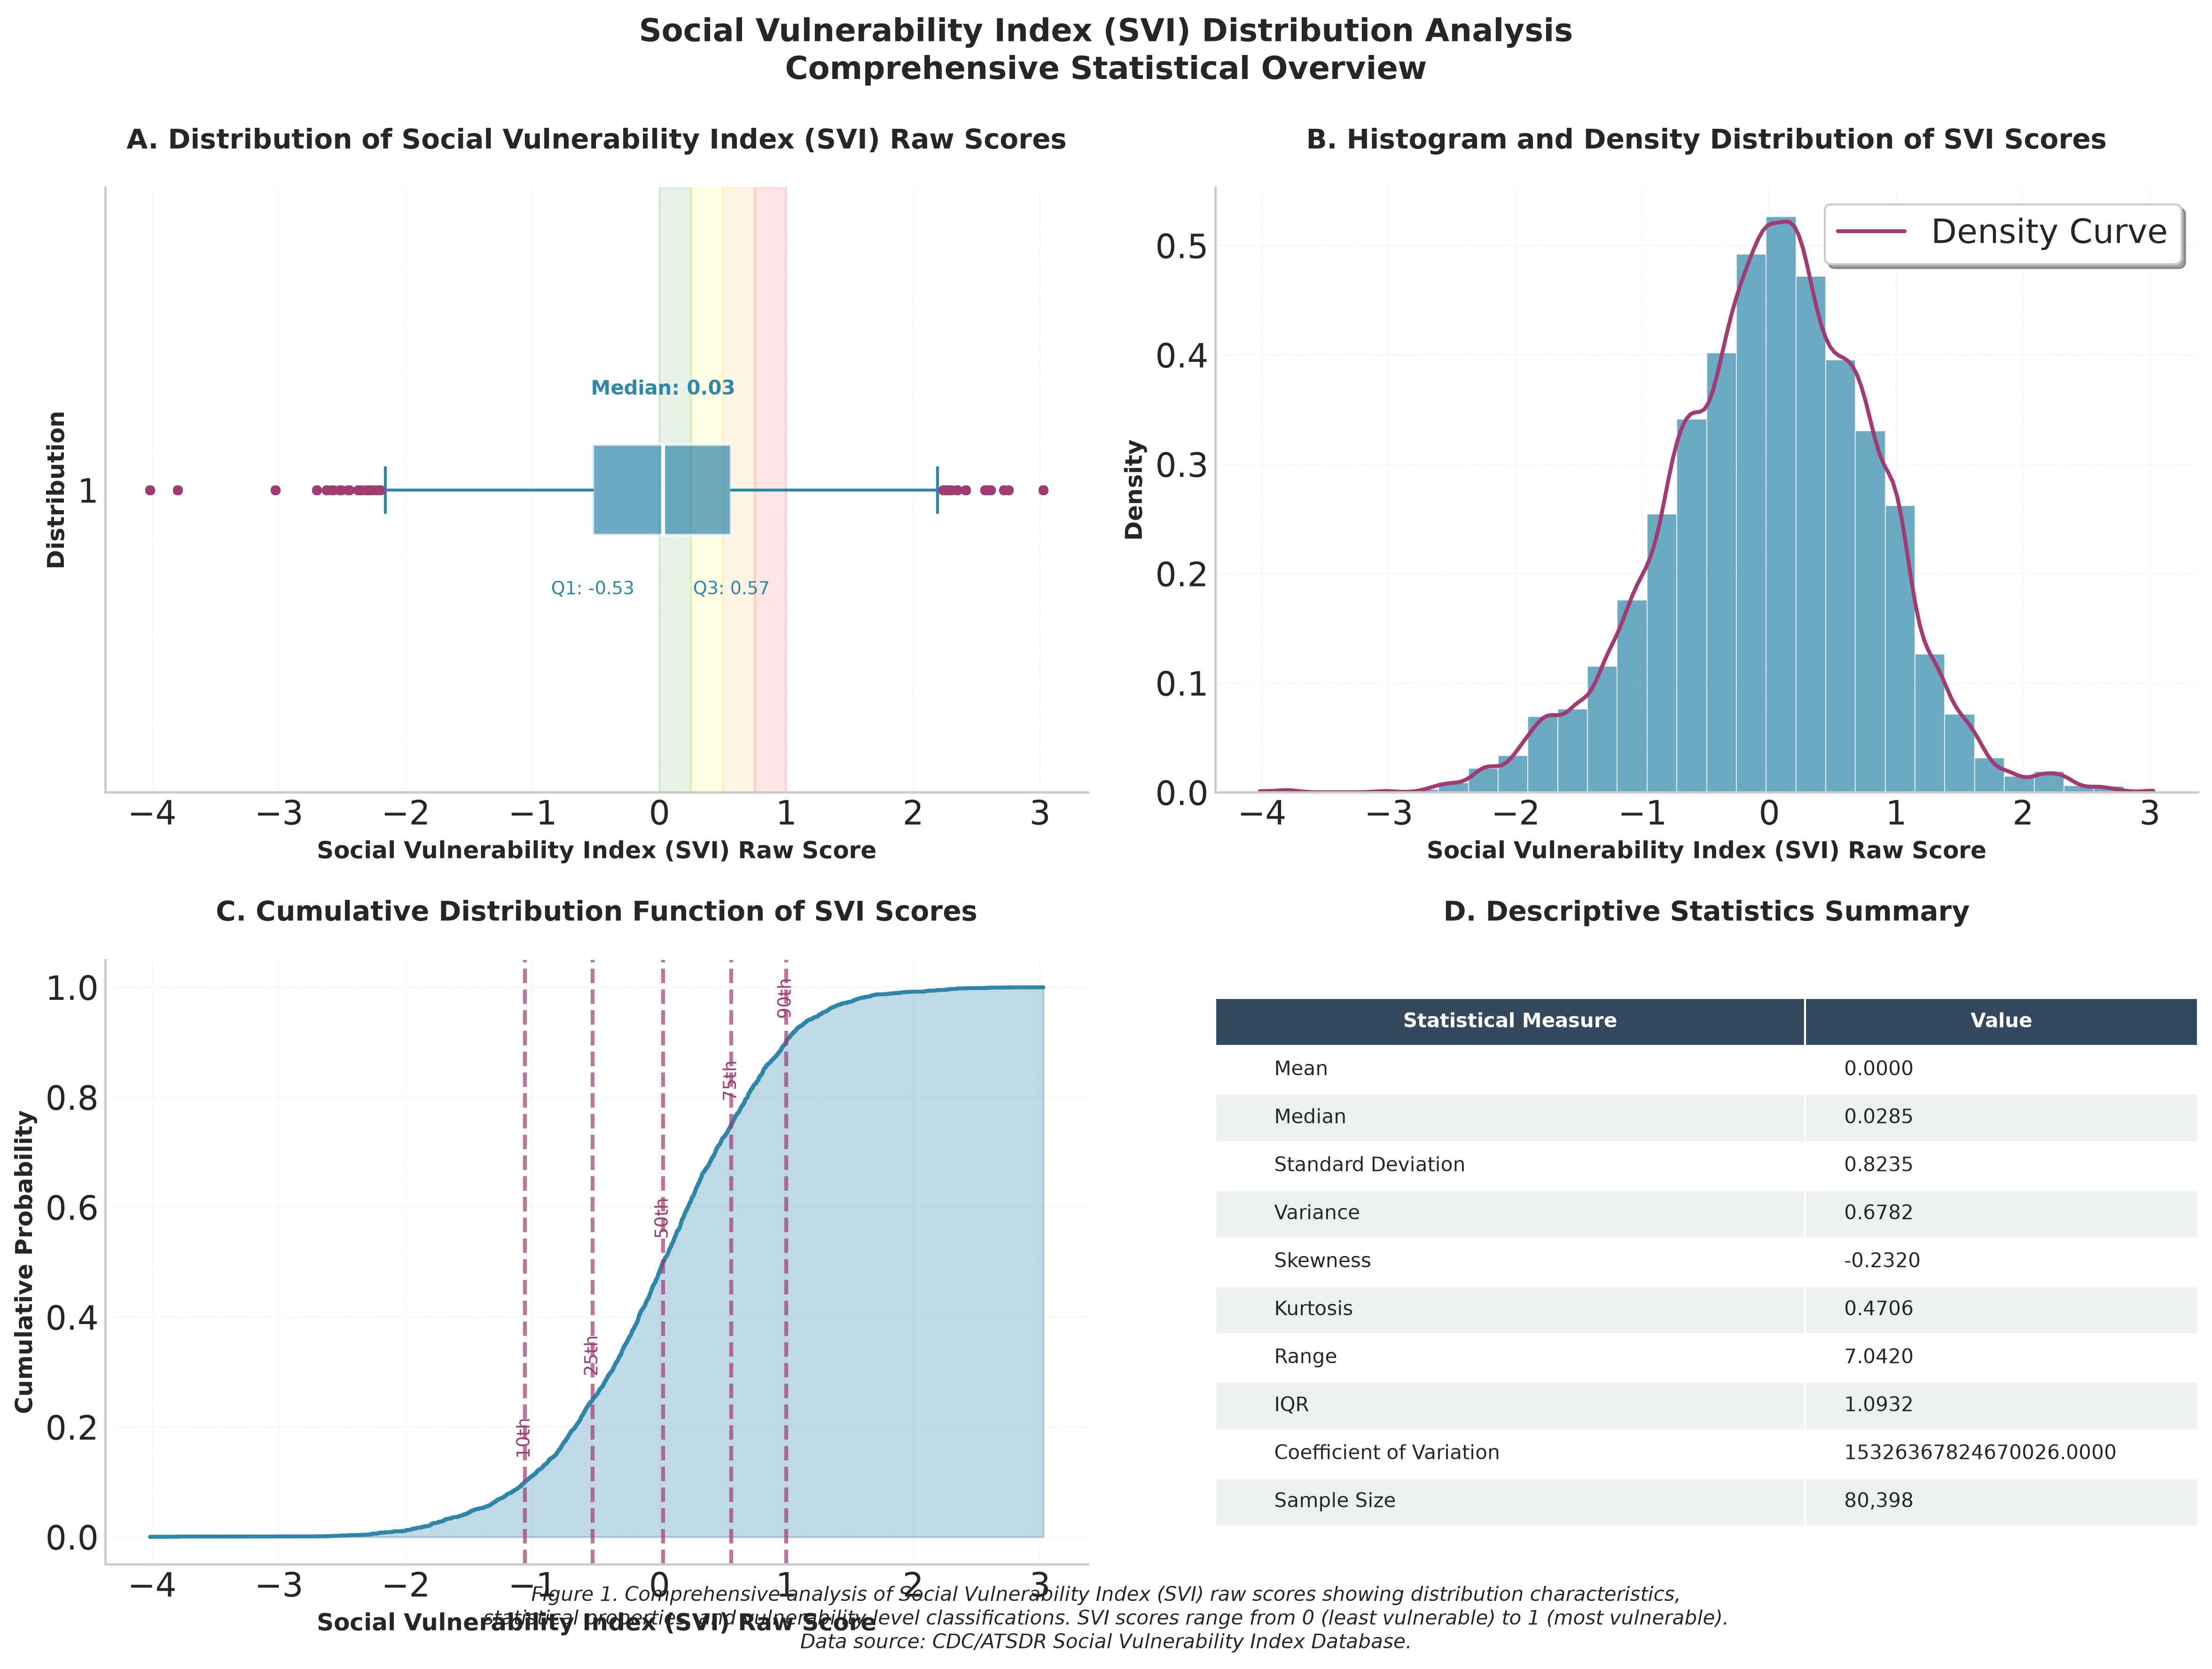

SOCIAL VULNERABILITY INDEX (SVI) ANALYSIS REPORT

EXECUTIVE SUMMARY:
• Dataset contains 80,398 observations of SVI raw scores
• Mean vulnerability score: 0.0000 (Scale: 0-1)
• Median vulnerability score: 0.0285
• Standard deviation: 0.8235

DISTRIBUTION CHARACTERISTICS:
• Skewness: -0.2320 (Approximately symmetric)
• Kurtosis: 0.4706 (Heavy-tailed)
• Coefficient of Variation: 15326367824670026.0000 (High variability)

VULNERABILITY LEVEL BREAKDOWN:
• Low Vulnerability (0.00–0.25):        49,261 areas (61.3%)
• Moderate Vulnerability (0.25–0.50):   9,128 areas (11.4%)
• High Vulnerability (0.50–0.75):       7,776 areas (9.7%)
• Very High Vulnerability (0.75–1.00):  14,233 areas (17.7%)

OUTLIER ANALYSIS:
• Number of outliers: 1,042 (1.30% of total)
• Outlier range: -4.0155 to 3.0265

POLICY IMPLICATIONS:
• 14,233 areas (17.7%) require immediate attention (SVI > 0.75)
• 22,009 areas (27.4%) show elevated vulnerability (SVI > 0.5)
• Geographic clustering analysis recommended for resource 

In [28]:
def create_svi_comprehensive_dashboard(
        svi_raw_values: pl.Series,
        save: bool = True,
) -> None:
    """
    Four-panel dashboard: boxplot, histogram+density, CDF, and statistics table.

    Equivalent to the inline subplot cell; extracted here for clarity and reuse.
    """
    svi_arr = np.asarray(svi_raw_values)

    q1, median, q3 = np.percentile(svi_arr, [25, 50, 75])
    iqr = q3 - q1
    lower_whisker = max(svi_arr.min(), q1 - 1.5 * iqr)
    upper_whisker = min(svi_arr.max(), q3 + 1.5 * iqr)

    fig = plt.figure(figsize=(16, 12))

    # ── Panel A: Boxplot ─────────────────────────────────────────────────────
    ax1 = plt.subplot(2, 2, 1)

    ax1.boxplot(
        svi_arr,
        vert=False,
        patch_artist=True,
        boxprops=dict(facecolor=PRIMARY_COLOR, alpha=0.7, linewidth=1.5),
        medianprops=dict(color="white", linewidth=2),
        whiskerprops=dict(color=PRIMARY_COLOR, linewidth=1.5),
        capprops=dict(color=PRIMARY_COLOR, linewidth=1.5),
        flierprops=dict(
            marker="o",
            markerfacecolor=SECONDARY_COLOR,
            markeredgecolor=SECONDARY_COLOR,
            markersize=4,
            alpha=0.6,
        ),
    )

    plt.text(
        median,
        1.15,
        f"Median: {median:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=PRIMARY_COLOR,
    )
    plt.text(
        q1,
        0.85,
        f"Q1: {q1:.2f}",
        ha="center",
        va="top",
        fontsize=9,
        color=PRIMARY_COLOR,
    )
    plt.text(
        q3,
        0.85,
        f"Q3: {q3:.2f}",
        ha="center",
        va="top",
        fontsize=9,
        color=PRIMARY_COLOR,
    )

    ax1.axvspan(
        0, LOW_VULNERABILITY_MAX, alpha=0.1, color="green", label="Low Vulnerability"
    )
    ax1.axvspan(
        LOW_VULNERABILITY_MAX,
        MODERATE_VULNERABILITY_MAX,
        alpha=0.1,
        color="yellow",
        label="Moderate Vulnerability",
    )
    ax1.axvspan(
        MODERATE_VULNERABILITY_MAX,
        HIGH_VULNERABILITY_MAX,
        alpha=0.1,
        color="orange",
        label="High Vulnerability",
    )
    ax1.axvspan(
        HIGH_VULNERABILITY_MAX,
        1,
        alpha=0.1,
        color="red",
        label="Very High Vulnerability",
    )

    plt.xlabel(
        "Social Vulnerability Index (SVI) Raw Score", fontsize=12, fontweight="bold"
    )
    plt.ylabel("Distribution", fontsize=12, fontweight="bold")
    plt.title(
        "A. Distribution of Social Vulnerability Index (SVI) Raw Scores",
        fontsize=14,
        fontweight="bold",
        pad=20,
    )
    plt.grid(axis="x", linestyle=":", linewidth=0.5, color=GRID_COLOR, alpha=0.7)

    # ── Panel B: Histogram + KDE ─────────────────────────────────────────────
    ax2 = plt.subplot(2, 2, 2)

    n, bins, patches = plt.hist(
        svi_arr,
        bins=30,
        alpha=0.7,
        color=PRIMARY_COLOR,
        edgecolor="white",
        linewidth=0.5,
        density=True,
    )

    density = stats.gaussian_kde(svi_arr)
    xs = np.linspace(svi_arr.min(), svi_arr.max(), 200)
    plt.plot(xs, density(xs), color=SECONDARY_COLOR, linewidth=2, label="Density Curve")

    plt.xlabel(
        "Social Vulnerability Index (SVI) Raw Score", fontsize=12, fontweight="bold"
    )
    plt.ylabel("Density", fontsize=12, fontweight="bold")
    plt.title(
        "B. Histogram and Density Distribution of SVI Scores",
        fontsize=14,
        fontweight="bold",
        pad=20,
    )
    plt.legend(frameon=True, fancybox=True, shadow=True)
    plt.grid(axis="both", linestyle=":", linewidth=0.5, color=GRID_COLOR, alpha=0.7)

    # ── Panel C: Cumulative Distribution ─────────────────────────────────────
    ax3 = plt.subplot(2, 2, 3)

    sorted_data = np.sort(svi_arr)
    cumulative = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    plt.plot(sorted_data, cumulative, color=PRIMARY_COLOR, linewidth=2)
    plt.fill_between(sorted_data, cumulative, alpha=0.3, color=PRIMARY_COLOR)

    for p in [10, 25, 50, 75, 90]:
        value = np.percentile(svi_arr, p)
        plt.axvline(value, color=SECONDARY_COLOR, linestyle="--", alpha=0.7)
        plt.text(
            value,
            p / 100 + 0.05,
            f"{p}th",
            rotation=90,
            ha="center",
            fontsize=9,
            color=SECONDARY_COLOR,
        )

    plt.xlabel(
        "Social Vulnerability Index (SVI) Raw Score", fontsize=12, fontweight="bold"
    )
    plt.ylabel("Cumulative Probability", fontsize=12, fontweight="bold")
    plt.title(
        "C. Cumulative Distribution Function of SVI Scores",
        fontsize=14,
        fontweight="bold",
        pad=20,
    )
    plt.grid(True, linestyle=":", linewidth=0.5, color=GRID_COLOR, alpha=0.7)

    # ── Panel D: Statistics Table ─────────────────────────────────────────────
    ax4 = plt.subplot(2, 2, 4)
    ax4.axis("off")

    skewness = float(stats.skew(svi_arr))
    kurtosis_val = float(stats.kurtosis(svi_arr))

    table_rows = [
        ["Mean", f"{svi_arr.mean():.4f}"],
        ["Median", f"{median:.4f}"],
        ["Standard Deviation", f"{svi_arr.std():.4f}"],
        ["Variance", f"{svi_arr.var():.4f}"],
        ["Skewness", f"{skewness:.4f}"],
        ["Kurtosis", f"{kurtosis_val:.4f}"],
        ["Range", f"{svi_arr.max() - svi_arr.min():.4f}"],
        ["IQR", f"{iqr:.4f}"],
        ["Coefficient of Variation", f"{svi_arr.std() / svi_arr.mean():.4f}"],
        ["Sample Size", f"{len(svi_arr):,}"],
    ]

    table = ax4.table(
        cellText=table_rows,
        colLabels=["Statistical Measure", "Value"],
        cellLoc="left",
        loc="center",
        colWidths=[0.6, 0.4],
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)

    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_facecolor("#34495e")
            cell.set_text_props(weight="bold", color="white")
        else:
            cell.set_facecolor("#ecf0f1" if row % 2 == 0 else "white")
        cell.set_edgecolor("white")
        cell.set_linewidth(1)

    ax4.set_title(
        "D. Descriptive Statistics Summary", fontsize=14, fontweight="bold", pad=20
    )

    if save:
        savefig_standard(FIGURE_DIR / "svi_analysis" / "major statistic 2.png")

    fig.suptitle(
        "Social Vulnerability Index (SVI) Distribution Analysis\nComprehensive Statistical Overview",
        fontsize=16,
        fontweight="bold",
        y=0.98,
    )
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    fig.text(
        0.5,
        0.01,
        "Figure 1. Comprehensive analysis of Social Vulnerability Index (SVI) raw scores showing distribution characteristics,\n"
        "statistical properties, and vulnerability level classifications. SVI scores range from 0 (least vulnerable) to 1 (most vulnerable).\n"
        "Data source: CDC/ATSDR Social Vulnerability Index Database.",
        ha="center",
        va="bottom",
        fontsize=10,
        style="italic",
        wrap=True,
    )

    if save:
        savefig_standard(FIGURE_DIR / "svi_analysis" / "major statistic.png")

    plt.show()

    # Print distribution report
    print("=" * 80)
    print("SOCIAL VULNERABILITY INDEX (SVI) ANALYSIS REPORT")
    print("=" * 80)
    print()

    cv = svi_arr.std() / svi_arr.mean()
    cv_label = (
        "High variability"
        if cv > 0.3
        else "Moderate variability" if cv > 0.15 else "Low variability"
    )
    skew_label = (
        "Right-skewed"
        if skewness > 0.5
        else "Left-skewed" if skewness < -0.5 else "Approximately symmetric"
    )
    tail_label = "Heavy-tailed" if kurtosis_val > 0 else "Light-tailed"

    print("EXECUTIVE SUMMARY:")
    print(f"• Dataset contains {len(svi_arr):,} observations of SVI raw scores")
    print(f"• Mean vulnerability score: {svi_arr.mean():.4f} (Scale: 0-1)")
    print(f"• Median vulnerability score: {median:.4f}")
    print(f"• Standard deviation: {svi_arr.std():.4f}")
    print()

    print("DISTRIBUTION CHARACTERISTICS:")
    print(f"• Skewness: {skewness:.4f} ({skew_label})")
    print(f"• Kurtosis: {kurtosis_val:.4f} ({tail_label})")
    print(f"• Coefficient of Variation: {cv:.4f} ({cv_label})")
    print()

    low_vuln = (svi_arr <= LOW_VULNERABILITY_MAX).sum()
    moderate_vuln = (
            (svi_arr > LOW_VULNERABILITY_MAX) & (svi_arr <= MODERATE_VULNERABILITY_MAX)
    ).sum()
    high_vuln = (
            (svi_arr > MODERATE_VULNERABILITY_MAX) & (svi_arr <= HIGH_VULNERABILITY_MAX)
    ).sum()
    very_high_vuln = (svi_arr > HIGH_VULNERABILITY_MAX).sum()
    n = len(svi_arr)

    print("VULNERABILITY LEVEL BREAKDOWN:")
    print(
        f"• Low Vulnerability (0.00–0.25):        {low_vuln:,} areas ({low_vuln / n * 100:.1f}%)"
    )
    print(
        f"• Moderate Vulnerability (0.25–0.50):   {moderate_vuln:,} areas ({moderate_vuln / n * 100:.1f}%)"
    )
    print(
        f"• High Vulnerability (0.50–0.75):       {high_vuln:,} areas ({high_vuln / n * 100:.1f}%)"
    )
    print(
        f"• Very High Vulnerability (0.75–1.00):  {very_high_vuln:,} areas ({very_high_vuln / n * 100:.1f}%)"
    )
    print()

    outliers = svi_arr[(svi_arr < lower_whisker) | (svi_arr > upper_whisker)]
    print("OUTLIER ANALYSIS:")
    print(
        f"• Number of outliers: {len(outliers):,} ({len(outliers) / n * 100:.2f}% of total)"
    )
    print(f"• Outlier range: {outliers.min():.4f} to {outliers.max():.4f}")
    print()

    high_priority = (svi_arr > HIGH_VULNERABILITY_MAX).sum()
    elevated = (svi_arr > MODERATE_VULNERABILITY_MAX).sum()
    print("POLICY IMPLICATIONS:")
    print(
        f"• {high_priority:,} areas ({high_priority / n * 100:.1f}%) require immediate attention (SVI > {HIGH_VULNERABILITY_MAX})"
    )
    print(
        f"• {elevated:,} areas ({elevated / n * 100:.1f}%) show elevated vulnerability (SVI > {MODERATE_VULNERABILITY_MAX})"
    )
    print("• Geographic clustering analysis recommended for resource allocation")


svi_raw_values = are_correlated["SVI_raw"]
create_svi_comprehensive_dashboard(svi_raw_values)



In [29]:
def create_and_save_svi_stats_table(
        data: Sequence,
        save_path: str | Path = FIGURE_DIR / "svi_analysis" / "major_statistic_table.png",
) -> Path:
    """
    Create a descriptive statistics table for SVI data and save it as an image.

    Parameters
    ----------
    data : Array-like (Polars Series, NumPy array, list) of numeric SVI values.
    save_path : File path for the saved table image.

    Returns
    -------
    Path to the saved file.
    """
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)

    numeric_values = np.asarray(data).ravel()
    numeric_values = numeric_values[np.isfinite(numeric_values)]

    if numeric_values.size == 0:
        raise ValueError("Input `data` contains no finite values after cleaning.")

    mean_val = numeric_values.mean()
    median_val = float(np.median(numeric_values))
    std_val = float(numeric_values.std(ddof=1))
    var_val = float(numeric_values.var(ddof=1))
    skew_val = float(stats.skew(numeric_values))
    kurt_val = float(stats.kurtosis(numeric_values))
    range_val = float(numeric_values.max() - numeric_values.min())
    q1, q3 = np.percentile(numeric_values, [25, 75])
    iqr = q3 - q1
    coeff_var = std_val / mean_val if mean_val != 0 else float("nan")
    sample_size = numeric_values.size

    lower_whisker = max(numeric_values.min(), q1 - 1.5 * iqr)
    upper_whisker = min(numeric_values.max(), q3 + 1.5 * iqr)
    n_outliers = int(
        np.sum((numeric_values < lower_whisker) | (numeric_values > upper_whisker))
    )

    table_rows = [
        ("Mean", f"{mean_val:.4f}"),
        ("Median", f"{median_val:.4f}"),
        ("Standard Deviation", f"{std_val:.4f}"),
        ("Variance", f"{var_val:.4f}"),
        ("Skewness", f"{skew_val:.4f}"),
        ("Kurtosis", f"{kurt_val:.4f}"),
        ("Range", f"{range_val:.4f}"),
        ("IQR", f"{iqr:.4f}"),
        (
            "Coefficient of Variation",
            f"{coeff_var:.4f}" if not np.isnan(coeff_var) else "NaN",
        ),
        ("Sample Size", f"{sample_size:,}"),
        ("Lower whisker (Tukey)", f"{lower_whisker:.4f}"),
        ("Upper whisker (Tukey)", f"{upper_whisker:.4f}"),
        ("Number of outliers (Tukey)", f"{n_outliers:,}"),
    ]

    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.axis("off")

    cell_text = [[label, value] for label, value in table_rows]
    table = ax.table(
        cellText=cell_text,
        colLabels=["Statistical Measure", "Value"],
        cellLoc="left",
        colLoc="left",
        loc="center",
    )
    table.scale(1, 1.6)

    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_facecolor("#34495e")
            cell.get_text().set_color("white")
            cell.get_text().set_weight("bold")
        else:
            cell.set_facecolor("#ecf0f1" if row % 2 == 0 else "white")
        cell.set_edgecolor("white")
        cell.set_linewidth(1)

    ax.set_title("Descriptive Statistics Summary", fontweight="bold", pad=12)

    savefig_standard(save_path)
    plt.close(fig)

    return save_path


path = create_and_save_svi_stats_table(are_correlated["SVI_raw"])


Saved: /home/youssef/projects/Sim-Equity/outputs/figures/svi_analysis/major_statistic_table.png


Saved: /home/youssef/projects/Sim-Equity/outputs/figures/svi_analysis/svi_empirical_cdf_extracted.png


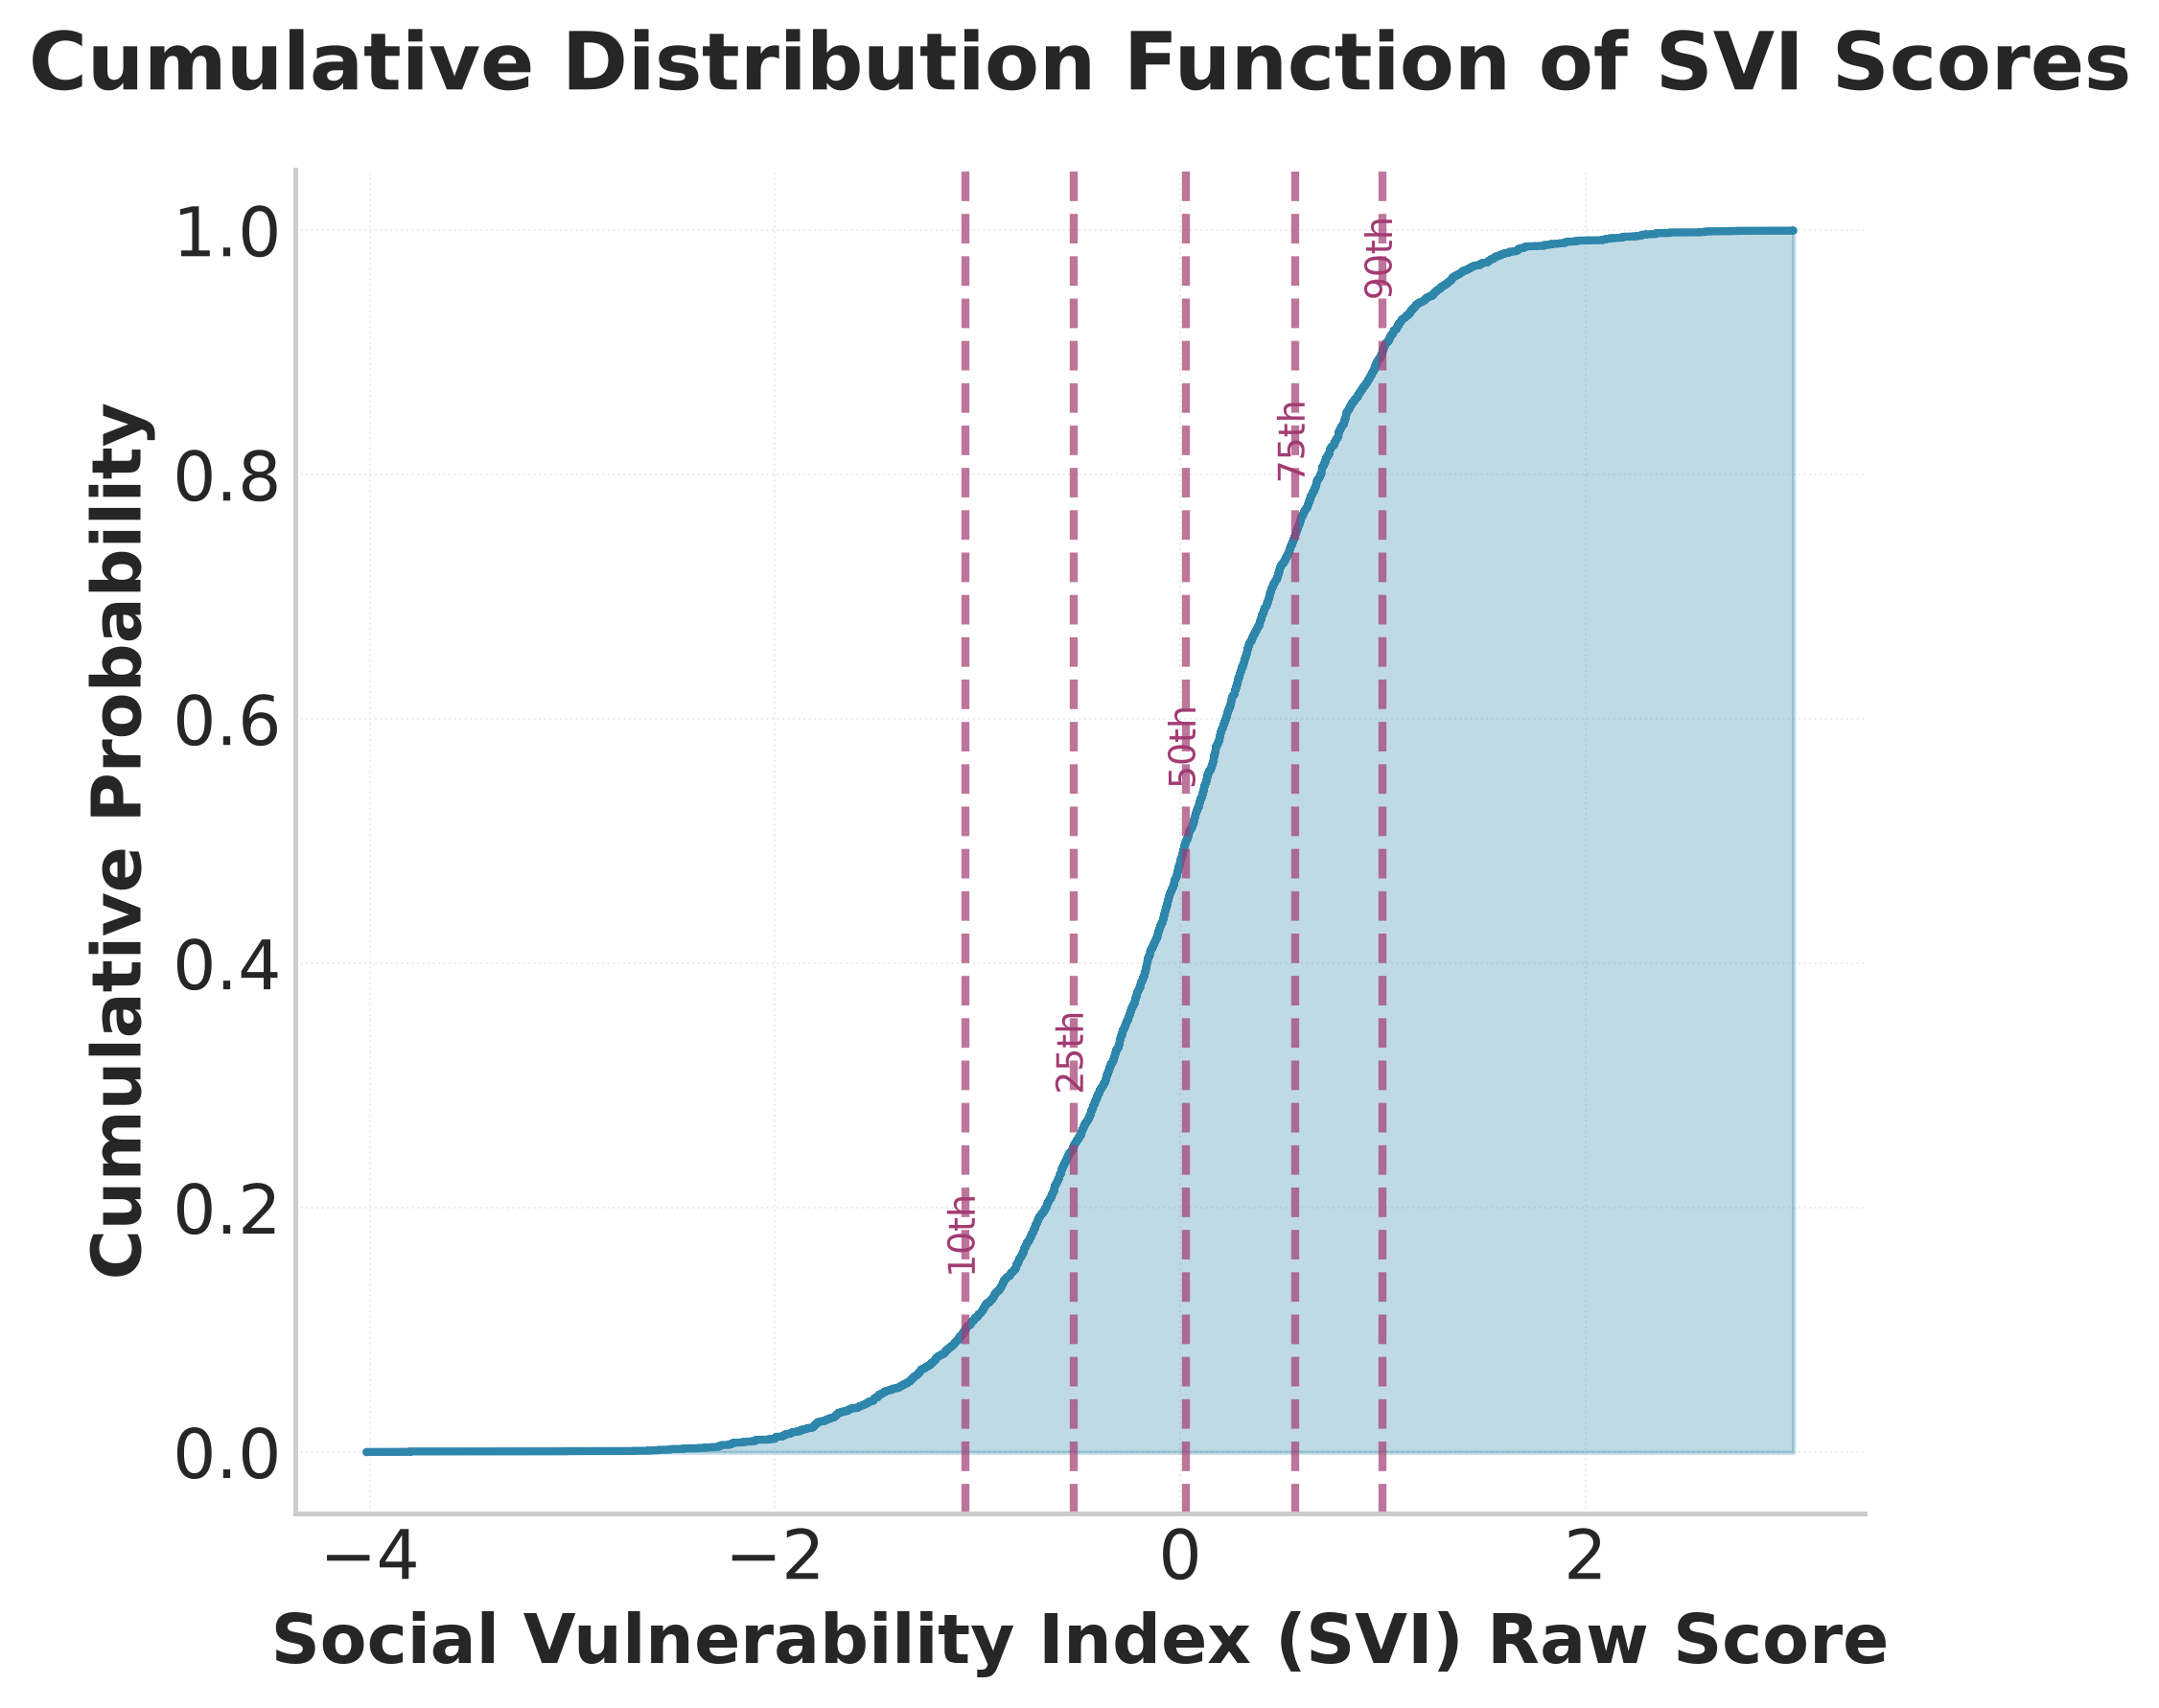

In [30]:
# --- Cumulative distribution
fig, ax = plt.subplots(figsize=FIGSIZE)
svi_raw_scores = np.asarray(are_correlated["SVI_raw"])
sorted_scores = np.sort(svi_raw_scores)
cumulative_probabilities = np.arange(1, len(sorted_scores) + 1) / len(sorted_scores)

ax.plot(sorted_scores, cumulative_probabilities, color=PRIMARY_COLOR, linewidth=2)
ax.fill_between(sorted_scores, cumulative_probabilities, alpha=0.3, color=PRIMARY_COLOR)

for percentile in [10, 25, 50, 75, 90]:
    percentile_value = np.percentile(svi_raw_scores, percentile)
    ax.axvline(percentile_value, color=SECONDARY_COLOR, linestyle="--", alpha=0.7)
    ax.text(
        percentile_value,
        percentile / 100 + 0.05,
        f"{percentile}th",
        rotation=90,
        ha="center",
        fontsize=9,
        color=SECONDARY_COLOR,
    )

ax.set_xlabel("Social Vulnerability Index (SVI) Raw Score", fontweight="bold")
ax.set_ylabel("Cumulative Probability", fontweight="bold")
ax.set_title(
    "Cumulative Distribution Function of SVI Scores", fontweight="bold", pad=20
)
ax.grid(True, linestyle=":", linewidth=0.5, color=GRID_COLOR, alpha=0.7)

savefig_standard(FIGURE_DIR / "svi_analysis" / "svi_empirical_cdf_extracted.png")
plt.show()


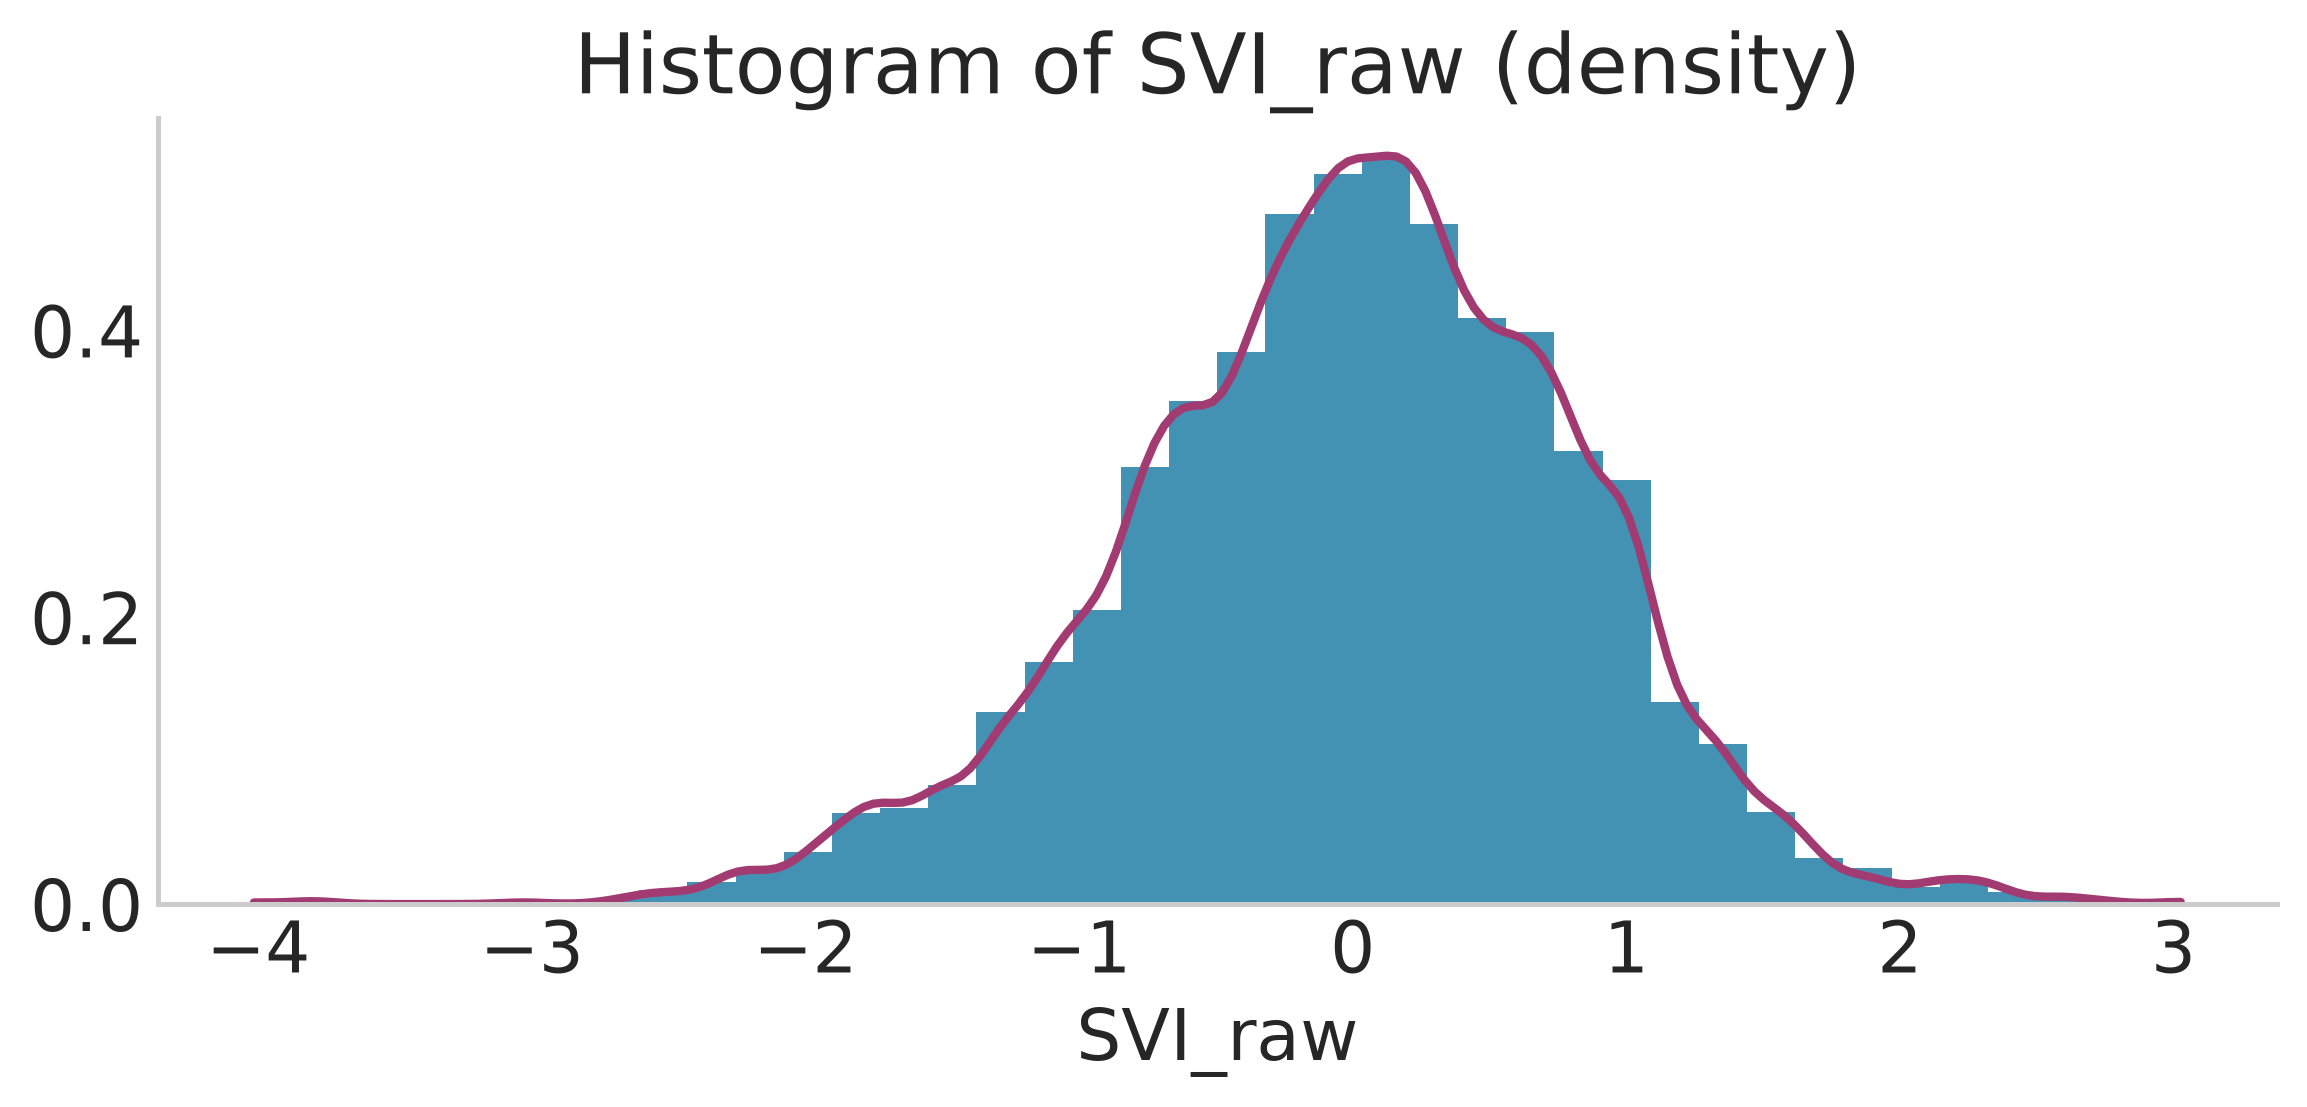

In [31]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(svi_raw_values, bins=40, density=True, alpha=0.9, color=PRIMARY_COLOR)

kde = gaussian_kde(svi_raw_values)
x_range = np.linspace(svi_raw_values.min(), svi_raw_values.max(), 200)
ax.plot(x_range, kde(x_range), color=SECONDARY_COLOR, linewidth=2)

ax.set_xlabel("SVI_raw")
ax.set_title("Histogram of SVI_raw (density)")
plt.tight_layout()
plt.show()


/tmp/ipykernel_153572/957803374.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.violinplot(svi_raw_values, vert=False, showmeans=True)


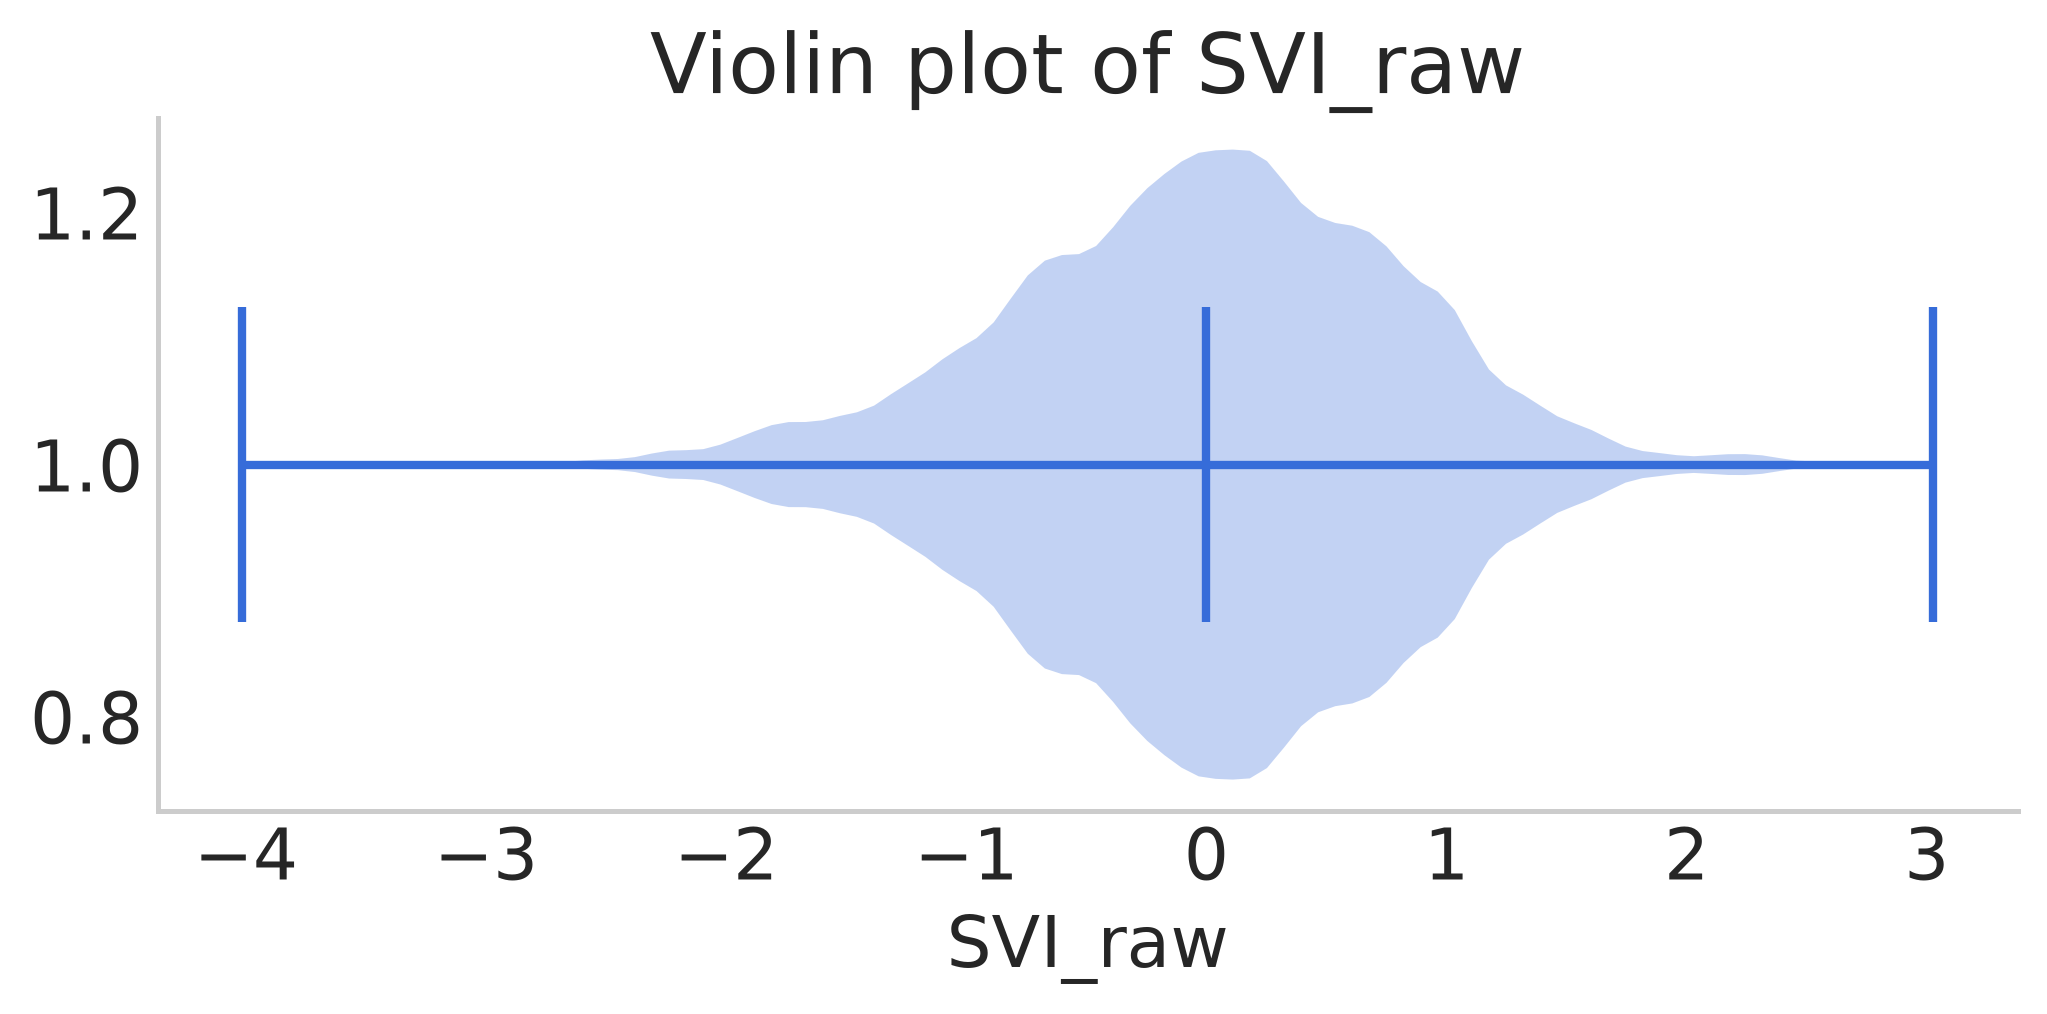

In [32]:
plt.figure(figsize=(8, 3))
plt.violinplot(svi_raw_values, vert=False, showmeans=True)
plt.xlabel("SVI_raw")
plt.title("Violin plot of SVI_raw")
plt.show()


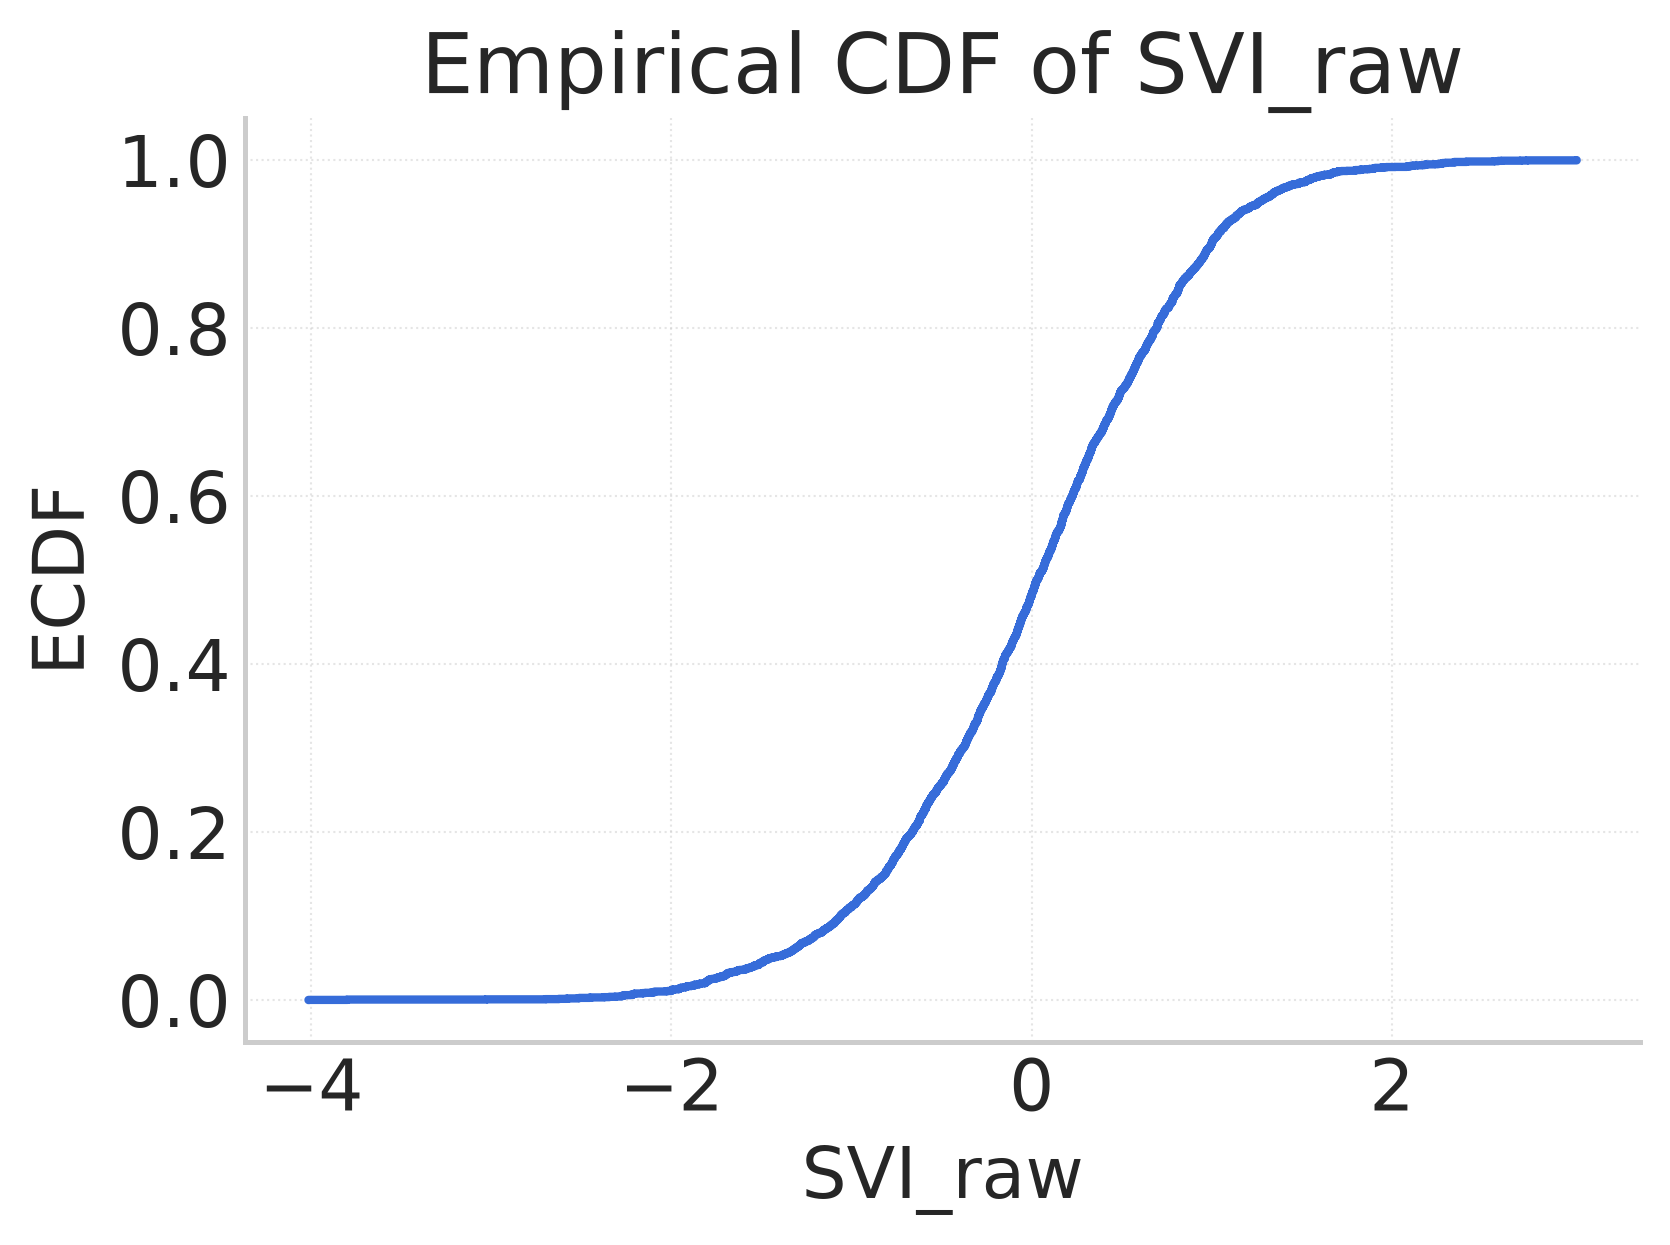

In [33]:
sorted_scores = np.sort(svi_raw_values)
empirical_probabilities = np.arange(1, len(sorted_scores) + 1) / len(sorted_scores)
plt.figure(figsize=(6, 4))
plt.step(sorted_scores, empirical_probabilities, where="post")
plt.xlabel("SVI_raw")
plt.ylabel("ECDF")
plt.title("Empirical CDF of SVI_raw")
plt.grid(True, linestyle=":")
plt.show()


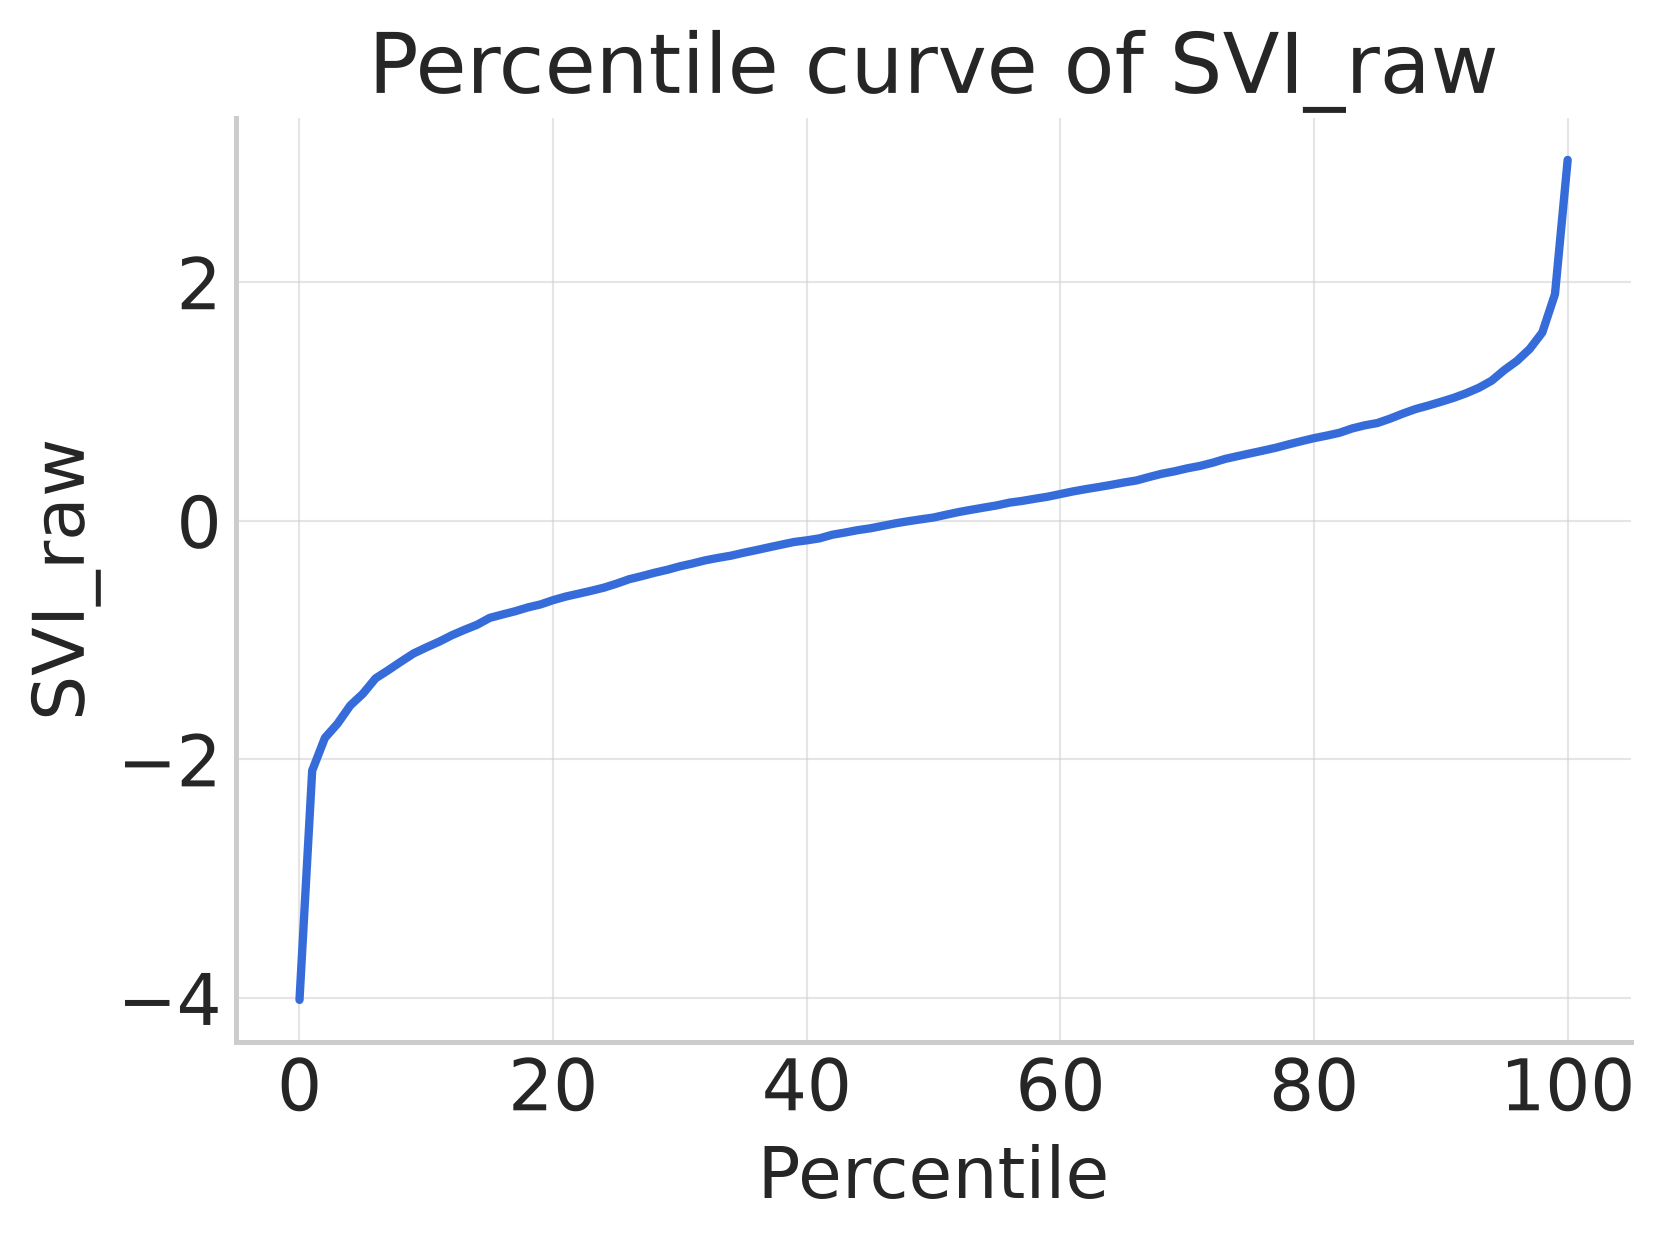

In [34]:
percentile_marks = np.arange(0, 101, 1)
percentile_values = np.percentile(svi_raw_values, percentile_marks)
plt.figure(figsize=(6, 4))
plt.plot(percentile_marks, percentile_values)
plt.xlabel("Percentile")
plt.ylabel("SVI_raw")
plt.title("Percentile curve of SVI_raw")
plt.grid(True)
plt.show()



#### Plotting the SVI Distribution on MAP

In [35]:
def calculate_svi_method1(
        are_correlated: pl.DataFrame, individuals_with_trips_df: pl.DataFrame
) -> pl.DataFrame:
    """
    Calculate SVI using weighted average — most interpretable approach.

    Returns a Polars DataFrame with columns: insee_code, AREA_NAME, svi_score (scaled 0–1).
    """
    are_correlated_weighted = are_correlated.with_columns(
        [
            pl.Series("insee_code", individuals_with_trips_df["CODGEO"].cast(pl.Utf8)),
            pl.Series("AREA_NAME", individuals_with_trips_df["AREA_NAME"]),
            pl.Series(
                "WEIGHT_INDIV",
                individuals_with_trips_df["WEIGHT_INDIV"].cast(pl.Float64),
            ),
            pl.Series("svi_raw", are_correlated["SVI_raw"].cast(pl.Float64)),
        ]
    )

    weighted_svi = (
        are_correlated_weighted.group_by(["insee_code", "AREA_NAME"])
        .agg(
            [
                pl.col("svi_raw")
                .mul(pl.col("WEIGHT_INDIV"))
                .sum()
                .alias("weighted_svi_sum"),
                pl.col("WEIGHT_INDIV").sum().alias("total_weight"),
            ]
        )
        .with_columns(
            [(pl.col("weighted_svi_sum") / pl.col("total_weight")).alias("svi_score")]
        )
    )

    # MinMaxScale to [0, 1] for interpretability.
    svi_scores_scaled = MinMaxScaler().fit_transform(
        weighted_svi["svi_score"].to_numpy().reshape(-1, 1)
    )
    return weighted_svi.with_columns(
        [pl.Series("svi_score", svi_scores_scaled.flatten())]
    )



In [44]:
def _classify_vulnerability_level(score: float) -> tuple[str, str, str]:
    """Return (css_class, label, hex_color) for a given SVI score."""
    if score >= HIGH_VULNERABILITY_MAX:
        return "very-high", "Very High", "#B2182B"
    if score >= MODERATE_VULNERABILITY_MAX:
        return "high", "High", "#D6604D"
    if score >= LOW_VULNERABILITY_MAX:
        return "moderate", "Moderate", "#F4A582"
    return "low", "Low", "#2166AC"


def _build_popup_html(row: pd.Series, svi_scores: pd.Series) -> str:
    """Build the Folium popup HTML for a single commune row."""
    if pd.isna(row["svi_score"]) or row["svi_score"] == 0:
        return (
            f'<div style="width: 200px;">'
            f'<h4 style="margin: 0; color: #2C3E50; font-size: 16px; border-bottom: 1px solid #eee; padding-bottom: 8px;">{row["nom"]}</h4>'
            f'<p style="margin: 10px 0; color: #7F8C8D; font-style: italic;">No SVI data available</p>'
            f'<p style="margin: 5px 0; font-size: 12px; color: #95A5A6;">INSEE Code: {row["code"]}</p>'
            f"</div>"
        )

    level_class, level_text, level_color = _classify_vulnerability_level(
        row["svi_score"]
    )
    percentile = (svi_scores <= row["svi_score"]).mean() * 100

    return (
        f'<div style="width: 250px;">'
        f'<h4 style="margin: 0; color: #2C3E50; font-size: 16px; border-bottom: 1px solid #eee; padding-bottom: 8px;">{row["AREA_NAME"]}</h4>'
        f'<p style="margin: 8px 0; color: #34495E; font-size: 14px;">{row["nom"]}</p>'
        f'<div style="background: #F8F9FA; padding: 12px; border-radius: 4px; margin: 10px 0; border-left: 4px solid {level_color};">'
        f'<p style="margin: 0; font-size: 14px;"><strong>SVI Score:</strong>'
        f'<span style="color: {level_color}; font-weight: bold; font-size: 16px;"> {row["svi_score"]:.3f}</span></p>'
        f'<p style="margin: 6px 0 0 0; font-size: 13px; color: #7F8C8D;">'
        f'Vulnerability: <span class="vulnerability-{level_class}">{level_text}</span></p>'
        f'<p style="margin: 4px 0 0 0; font-size: 12px; color: #7F8C8D;">Percentile: {percentile:.1f}th</p>'
        f"</div>"
        f'<div style="font-size: 11px; color: #95A5A6; margin-top: 8px; border-top: 1px solid #eee; padding-top: 8px;">'
        f'<p style="margin: 3px 0;">INSEE Code: {row["code"]}</p>'
        f'<p style="margin: 3px 0;">Department: {row["dept"]}</p>'
        f"</div></div>"
    )


def create_academic_folium_svi_choropleth(
        svi_data: pd.DataFrame,
        save_path: str | None = None,
        png_save_path: str | None = None,
) -> tuple:
    """
    Create a clean, academic-style Folium choropleth map with PNG export capability.

    Parameters
    ----------
    svi_data : DataFrame with 'insee_code', 'svi_score', and 'AREA_NAME' columns.
    save_path : Optional path to save the HTML file.
    png_save_path : Optional path to save a PNG screenshot.

    Returns
    -------
    (folium.Map, GeoDataFrame) — interactive map and merged geographic data.
    """
    communes_geojson_url = (
        "https://france-geojson.gregoiredavid.fr/repo/communes.geojson"
    )
    communes_gdf = gpd.read_file(communes_geojson_url)

    communes_gdf["dept"] = communes_gdf["code"].str[:2]
    idf_communes_gdf = communes_gdf[
        communes_gdf["dept"].isin(IDF_DEPARTMENT_CODES)
    ].copy()

    aggregated_svi = (
        svi_data.groupby(["insee_code", "AREA_NAME"])["svi_score"].mean().reset_index()
    )
    aggregated_svi["insee_code"] = aggregated_svi["insee_code"].astype(str)
    idf_communes_gdf["code"] = idf_communes_gdf["code"].astype(str)

    merged_map_data = idf_communes_gdf.merge(
        aggregated_svi, left_on="code", right_on="insee_code", how="left"
    )
    merged_map_data["svi_score"] = merged_map_data["svi_score"].fillna(0)

    areas_with_svi_data = merged_map_data[merged_map_data["svi_score"] > 0].copy()

    svi_scores = areas_with_svi_data["svi_score"]
    vmin, vmax = svi_scores.quantile([0.02, 0.98]) if len(svi_scores) > 0 else (0, 1)
    mean_svi = svi_scores.mean()
    median_svi = svi_scores.median()
    std_svi = svi_scores.std()

    colormap_colors = [
        "#2166AC",
        "#4393C3",
        "#92C5DE",
        "#D1E5F0",
        "#F7F7F7",
        "#FDDBC7",
        "#F4A582",
        "#D6604D",
        "#B2182B",
    ]
    colormap = LinearColormap(
        colors=colormap_colors,
        vmin=vmin,
        vmax=vmax,
        caption="Social Vulnerability Index (SVI)",
    )

    center_lat = (
        areas_with_svi_data.geometry.centroid.y.mean()
        if len(areas_with_svi_data) > 0
        else 48.8566
    )
    center_lon = (
        areas_with_svi_data.geometry.centroid.x.mean()
        if len(areas_with_svi_data) > 0
        else 2.3522
    )

    m = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=10,
        tiles="CartoDB positron",
        prefer_canvas=True,
        control_scale=True,
    )

    custom_css = """
    <style>
    .leaflet-popup-content-wrapper {
        background: white; color: #333; border-radius: 8px;
        box-shadow: 0 3px 14px rgba(0,0,0,0.2);
        font-family: 'DejaVu Sans', Arial, sans-serif; font-size: 14px; line-height: 1.4;
    }
    .leaflet-popup-content { margin: 15px; line-height: 1.4; }
    .leaflet-control-attribution { font-size: 9px; }
    .vulnerability-high      { color: #E74C3C; font-weight: bold; }
    .vulnerability-moderate  { color: #F39C12; font-weight: bold; }
    .vulnerability-low       { color: #27AE60; font-weight: bold; }
    .vulnerability-very-high { color: #B2182B; font-weight: bold; }
    </style>
    """

    geojson_layer = folium.GeoJson(
        areas_with_svi_data,
        name="Social Vulnerability Index",
        style_function=lambda feature: {
            "fillColor": colormap(feature["properties"]["svi_score"]),
            "color": "white",
            "weight": 0.8,
            "fillOpacity": 0.7,
            "lineOpacity": 0.4,
        },
        highlight_function=lambda feature: {
            "weight": 2,
            "color": "#333333",
            "fillOpacity": 0.9,
        },
        smooth_factor=1.0,
    ).add_to(m)

    geojson_layer.add_child(
        folium.features.GeoJsonTooltip(
            fields=["AREA_NAME", "svi_score", "nom"],
            aliases=["Area: ", "SVI Score: ", "Commune: "],
            localize=True,
            sticky=True,
            labels=True,
            style=(
                "background-color: #F8F9FA; border: 1px solid #BDC3C7; border-radius: 4px;"
                "box-shadow: 2px 2px 2px rgba(0,0,0,0.2);"
                "font-family: DejaVu Sans, Arial, sans-serif; font-size: 13px; padding: 5px;"
            ),
            max_width=250,
        )
    )

    try:
        idf_boundary_gdf = gpd.read_file("data/departements-ile-de-france.geojson")
        folium.GeoJson(
            idf_boundary_gdf,
            style_function=lambda _: {
                "fillColor": "none",
                "color": "#2C3E50",
                "weight": 3,
                "dashArray": "10, 10",
                "fillOpacity": 0,
            },
            name="Île-de-France Boundary",
        ).add_to(m)
        print("✅ Added Île-de-France boundary to the map")
    except Exception as exc:
        print(f"❌ Could not load Île-de-France boundary: {exc}")

    colormap.add_to(m)

    highest_svi_areas = areas_with_svi_data.nlargest(5, "svi_score")
    lowest_svi_areas = areas_with_svi_data.nsmallest(5, "svi_score")

    def _area_row_html(i: int, row: pd.Series) -> str:
        truncated = row["AREA_NAME"][:20] + (
            "..." if len(row["AREA_NAME"]) > 20 else ""
        )
        return f"            {i}. {truncated} ({row['svi_score']:.2f})<br>"

    highest_rows = "".join(
        _area_row_html(i, row)
        for i, (_, row) in enumerate(highest_svi_areas.iterrows(), 1)
    )
    lowest_rows = "".join(
        _area_row_html(i, row)
        for i, (_, row) in enumerate(lowest_svi_areas.iterrows(), 1)
    )

    statistics_html = f"""
    <div style='position: fixed; top: 10px; left: 10px; width: 300px; height: auto;
                background-color: rgba(255, 255, 255, 0.95); border: 1px solid #2C3E50; z-index:9999;
                font-size: 13px; font-family: DejaVu Sans, Arial, sans-serif;
                border-radius: 6px; box-shadow: 0 3px 10px rgba(0,0,0,0.2);
                overflow-y: auto; max-height: 95%;'>
    <div style='background-color: #2C3E50; color: white; padding: 10px; margin: 0;
                border-radius: 5px 5px 0 0; font-weight: bold; text-align: center;'>
        📊 SVI Distribution Analysis
    </div>
    <div style='padding: 12px;'>
        <div style='background: #F8F9FA; padding: 10px; border-radius: 4px; margin-bottom: 12px; border-left: 3px solid #2C3E50;'>
            <strong style='color: #2C3E50;'>Dataset Overview</strong><br>
            <div style='font-size: 12px; margin-top: 5px;'>
                • Areas Analyzed: {len(areas_with_svi_data):,}<br>
                • Mean SVI: {mean_svi:.3f}<br>
                • Median SVI: {median_svi:.3f}<br>
                • Std Dev: {std_svi:.3f}<br>
                • Range: {svi_scores.min():.2f} - {svi_scores.max():.2f}
            </div>
        </div>
        <div style='margin-bottom: 10px;'>
            <strong style='color: #B2182B;'>🔴 Highest Vulnerability</strong><br>
            <div style='font-size: 11px; margin-left: 8px; margin-top: 4px;'>
    {highest_rows}
            </div>
        </div>
        <div>
            <strong style='color: #2166AC;'>🔵 Lowest Vulnerability</strong><br>
            <div style='font-size: 11px; margin-left: 8px; margin-top: 4px;'>
    {lowest_rows}
            </div>
        </div>
    </div>
    </div>
    """

    coverage_pct = len(areas_with_svi_data) / len(merged_map_data) * 100
    methodology_html = f"""
    <div style='position: fixed; bottom: 20px; right: 20px; width: 320px; height: auto;
                background-color: rgba(255, 255, 255, 0.95); border: 1px solid #27AE60; z-index:9999;
                font-size: 12px; font-family: DejaVu Sans, Arial, sans-serif;
                border-radius: 6px; box-shadow: 0 3px 10px rgba(0,0,0,0.2);'>
    <div style='background-color: #27AE60; color: white; padding: 8px; margin: 0;
                border-radius: 5px 5px 0 0; font-weight: bold; text-align: center;'>
        📋 Methodology & Interpretation
    </div>
    <div style='padding: 10px;'>
        <div style='margin-bottom: 8px;'>
            <strong>Color Scale Interpretation:</strong><br>
            <div style='font-size: 11px; margin-top: 4px;'>
                <span style='color: #B2182B;'>● Very High:</span> ≥ {HIGH_VULNERABILITY_MAX}<br>
                <span style='color: #D6604D;'>● High:</span> {MODERATE_VULNERABILITY_MAX}–{HIGH_VULNERABILITY_MAX}<br>
                <span style='color: #F4A582;'>● Moderate:</span> {LOW_VULNERABILITY_MAX}–{MODERATE_VULNERABILITY_MAX}<br>
                <span style='color: #2166AC;'>● Low:</span> &lt; {LOW_VULNERABILITY_MAX}
            </div>
        </div>
        <div style='font-size: 11px; color: #7F8C8D; margin-top: 8px; padding-top: 8px; border-top: 1px solid #eee;'>
            <strong>SVI Components:</strong> Education, Mobility, Demographics, Transportation<br>
            <strong>Methodology:</strong> PCA-weighted socioeconomic indicators<br>
            <strong>Coverage:</strong> {coverage_pct:.1f}% of Île-de-France communes
        </div>
    </div>
    </div>
    """

    m.get_root().html.add_child(folium.Element(custom_css))
    m.get_root().html.add_child(folium.Element(statistics_html))
    m.get_root().html.add_child(folium.Element(methodology_html))
    folium.LayerControl(position="topright", collapsed=False).add_to(m)

    if save_path:
        m.save(save_path)
        print(f"Clean Folium map saved to {save_path}")

    if png_save_path:
        print(f"PNG version saved to {png_save_path}")

    print("\n" + "=" * 80)
    print("📊 SVI DISTRIBUTION ANALYSIS - FOLIUM INTERACTIVE MAP")
    print("=" * 80)
    print(f"\nDESCRIPTIVE STATISTICS:")
    print(f"• Sample Size: {len(areas_with_svi_data):,}")
    print(f"• Mean: {mean_svi:.4f}")
    print(f"• Median: {median_svi:.4f}")
    print(f"• Standard Deviation: {std_svi:.4f}")
    print(f"• Variance: {svi_scores.var():.4f}")
    print(f"• Range: {svi_scores.max() - svi_scores.min():.4f}")
    print(
        f"• Interquartile Range: {np.percentile(svi_scores, 75) - np.percentile(svi_scores, 25):.4f}"
    )
    print(f"• Coefficient of Variation: {std_svi / mean_svi:.4f}")
    print()
    print("COVERAGE ANALYSIS:")
    print(f"🗺️  Total Communes in Île-de-France: {len(merged_map_data)}")
    print(f"📊 Areas with SVI Data: {len(areas_with_svi_data)}")
    print(f"📈 Coverage Percentage: {coverage_pct:.1f}%")
    print()
    print("🔴 TOP 5 MOST VULNERABLE AREAS:")
    print("-" * 50)
    for i, (_, row) in enumerate(highest_svi_areas.head(5).iterrows(), 1):
        _, level_text, _ = _classify_vulnerability_level(row["svi_score"])
        print(f"{i}. {row['AREA_NAME']:30} | {row['svi_score']:5.3f} ({level_text})")
    print("\n🔵 TOP 5 LEAST VULNERABLE AREAS:")
    print("-" * 50)
    for i, (_, row) in enumerate(lowest_svi_areas.head(5).iterrows(), 1):
        _, level_text, _ = _classify_vulnerability_level(row["svi_score"])
        print(f"{i}. {row['AREA_NAME']:30} | {row['svi_score']:5.3f} ({level_text})")
    print("\n" + "=" * 80)
    print("✅ Interactive Folium visualization complete!")
    print("=" * 80)

    return m, areas_with_svi_data



In [46]:
def generate_png_from_map(
        html_file_path: str | Path,
        png_save_path: str | Path,
        width: int = 1800,
        height: int = 1100,
        wait_ms: int = 5000,
        headless: bool = True,
) -> bool:
    """
    Render a Folium map HTML file to a PNG via Playwright.

    Works both in running asyncio loops (e.g. Jupyter) and plain scripts by
    dispatching async work to a dedicated thread when a loop is already running.
    """
    html_path = str(Path(html_file_path).resolve())
    png_path = str(png_save_path)

    async def _screenshot_async() -> None:
        async with async_playwright() as p:
            browser = await p.chromium.launch(headless=headless)
            page = await browser.new_page()
            await page.set_viewport_size({"width": width, "height": height})
            await page.goto(f"file://{html_path}")
            await page.wait_for_timeout(wait_ms)
            await page.screenshot(path=png_path, full_page=True)
            await browser.close()

    def _run_in_thread(coro) -> None:
        t = threading.Thread(target=lambda: asyncio.run(coro))
        t.start()
        t.join()

    try:
        from playwright.async_api import async_playwright

        try:
            asyncio.get_running_loop()
            loop_running = True
        except RuntimeError:
            loop_running = False

        if loop_running:
            _run_in_thread(_screenshot_async())
        else:
            asyncio.run(_screenshot_async())

        print(f"PNG successfully saved to {png_save_path}")
        return True

    except Exception as exc_async:
        print(f"Async Playwright failed: {exc_async}")
        try:

            def _sync_runner() -> None:
                from playwright.sync_api import sync_playwright

                with sync_playwright() as p:
                    browser = p.chromium.launch(headless=headless)
                    page = browser.new_page()
                    page.set_viewport_size({"width": width, "height": height})
                    page.goto(f"file://{html_path}")
                    page.wait_for_timeout(wait_ms)
                    page.screenshot(path=png_path, full_page=True)
                    browser.close()

            _run_in_thread(_sync_runner())
            print(f"PNG successfully saved to {png_save_path} (sync fallback)")
            return True

        except Exception as exc_sync:
            print(f"Also failed with sync API: {exc_sync}")
            return False


# =============================================================================
# EXECUTION EXAMPLE
# =============================================================================
if __name__ == "__main__":
    svi_data = (
        out_df.select(["CODGEO", "SVI_normalized", "AREA_NAME"])
        .rename({"CODGEO": "insee_code", "SVI_normalized": "svi_score"})
        .to_pandas()
    )

    print("🗺️  Creating Clean Academic Folium SVI Choropleth Map...")
    print("⚙️  Features: Academic styling, interactive tooltips, statistical overlays")
    print("🎯 Design: Consistent with global visualization settings")

    folium_map, geodata = create_academic_folium_svi_choropleth(
        svi_data,
        save_path=FIGURE_DIR / "svi_analysis" / "interactive_svi_map.html",
        png_save_path=None,
    )

    generate_png_from_map(
        FIGURE_DIR / "svi_analysis" / "interactive_svi_map.html",
        FIGURE_DIR / "svi_analysis" / "area_focused_svi_map.png",
    )

    print("\n✅ Function ready to generate academic SVI map!")


🗺️  Creating Clean Academic Folium SVI Choropleth Map...
⚙️  Features: Academic styling, interactive tooltips, statistical overlays
🎯 Design: Consistent with global visualization settings


/tmp/ipykernel_153572/2692486918.py:112: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  areas_with_svi_data.geometry.centroid.y.mean()
/tmp/ipykernel_153572/2692486918.py:117: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  areas_with_svi_data.geometry.centroid.x.mean()


❌ Could not load Île-de-France boundary: data/departements-ile-de-france.geojson: No such file or directory
Clean Folium map saved to /home/youssef/projects/Sim-Equity/outputs/figures/svi_analysis/interactive_svi_map.html

📊 SVI DISTRIBUTION ANALYSIS - FOLIUM INTERACTIVE MAP

DESCRIPTIVE STATISTICS:
• Sample Size: 606
• Mean: 0.5567
• Median: 0.5629
• Standard Deviation: 0.0878
• Variance: 0.0077
• Range: 0.6805
• Interquartile Range: 0.0954
• Coefficient of Variation: 0.1577

COVERAGE ANALYSIS:
🗺️  Total Communes in Île-de-France: 1305
📊 Areas with SVI Data: 606
📈 Coverage Percentage: 46.4%

🔴 TOP 5 MOST VULNERABLE AREAS:
--------------------------------------------------
1. Angerville                     | 0.935 (Very High)
2. Clichy-sous-Bois               | 0.892 (Very High)
3. Bonnelles                      | 0.830 (Very High)
4. Villetaneuse                   | 0.773 (Very High)
5. Orgeval                        | 0.765 (Very High)

🔵 TOP 5 LEAST VULNERABLE AREAS:
---------------

## Intuitions & Brainstorming

In [38]:
# Brainstorming note — age transformation intuition:
#   For ages below the mean, use 1 / (1 + log(age)) → approaches 0 as age grows.
#   For ages above the mean, use log(age) - 1      → grows with age.
#
#   Example (mean_age = 43):
#     Age 42: 1 / (1 + log(42)) ≈ 0.211
#     Age 44: log(44) - 1       ≈ 2.78


Saved: /home/youssef/projects/Sim-Equity/outputs/figures/relationship_inverse_log.png


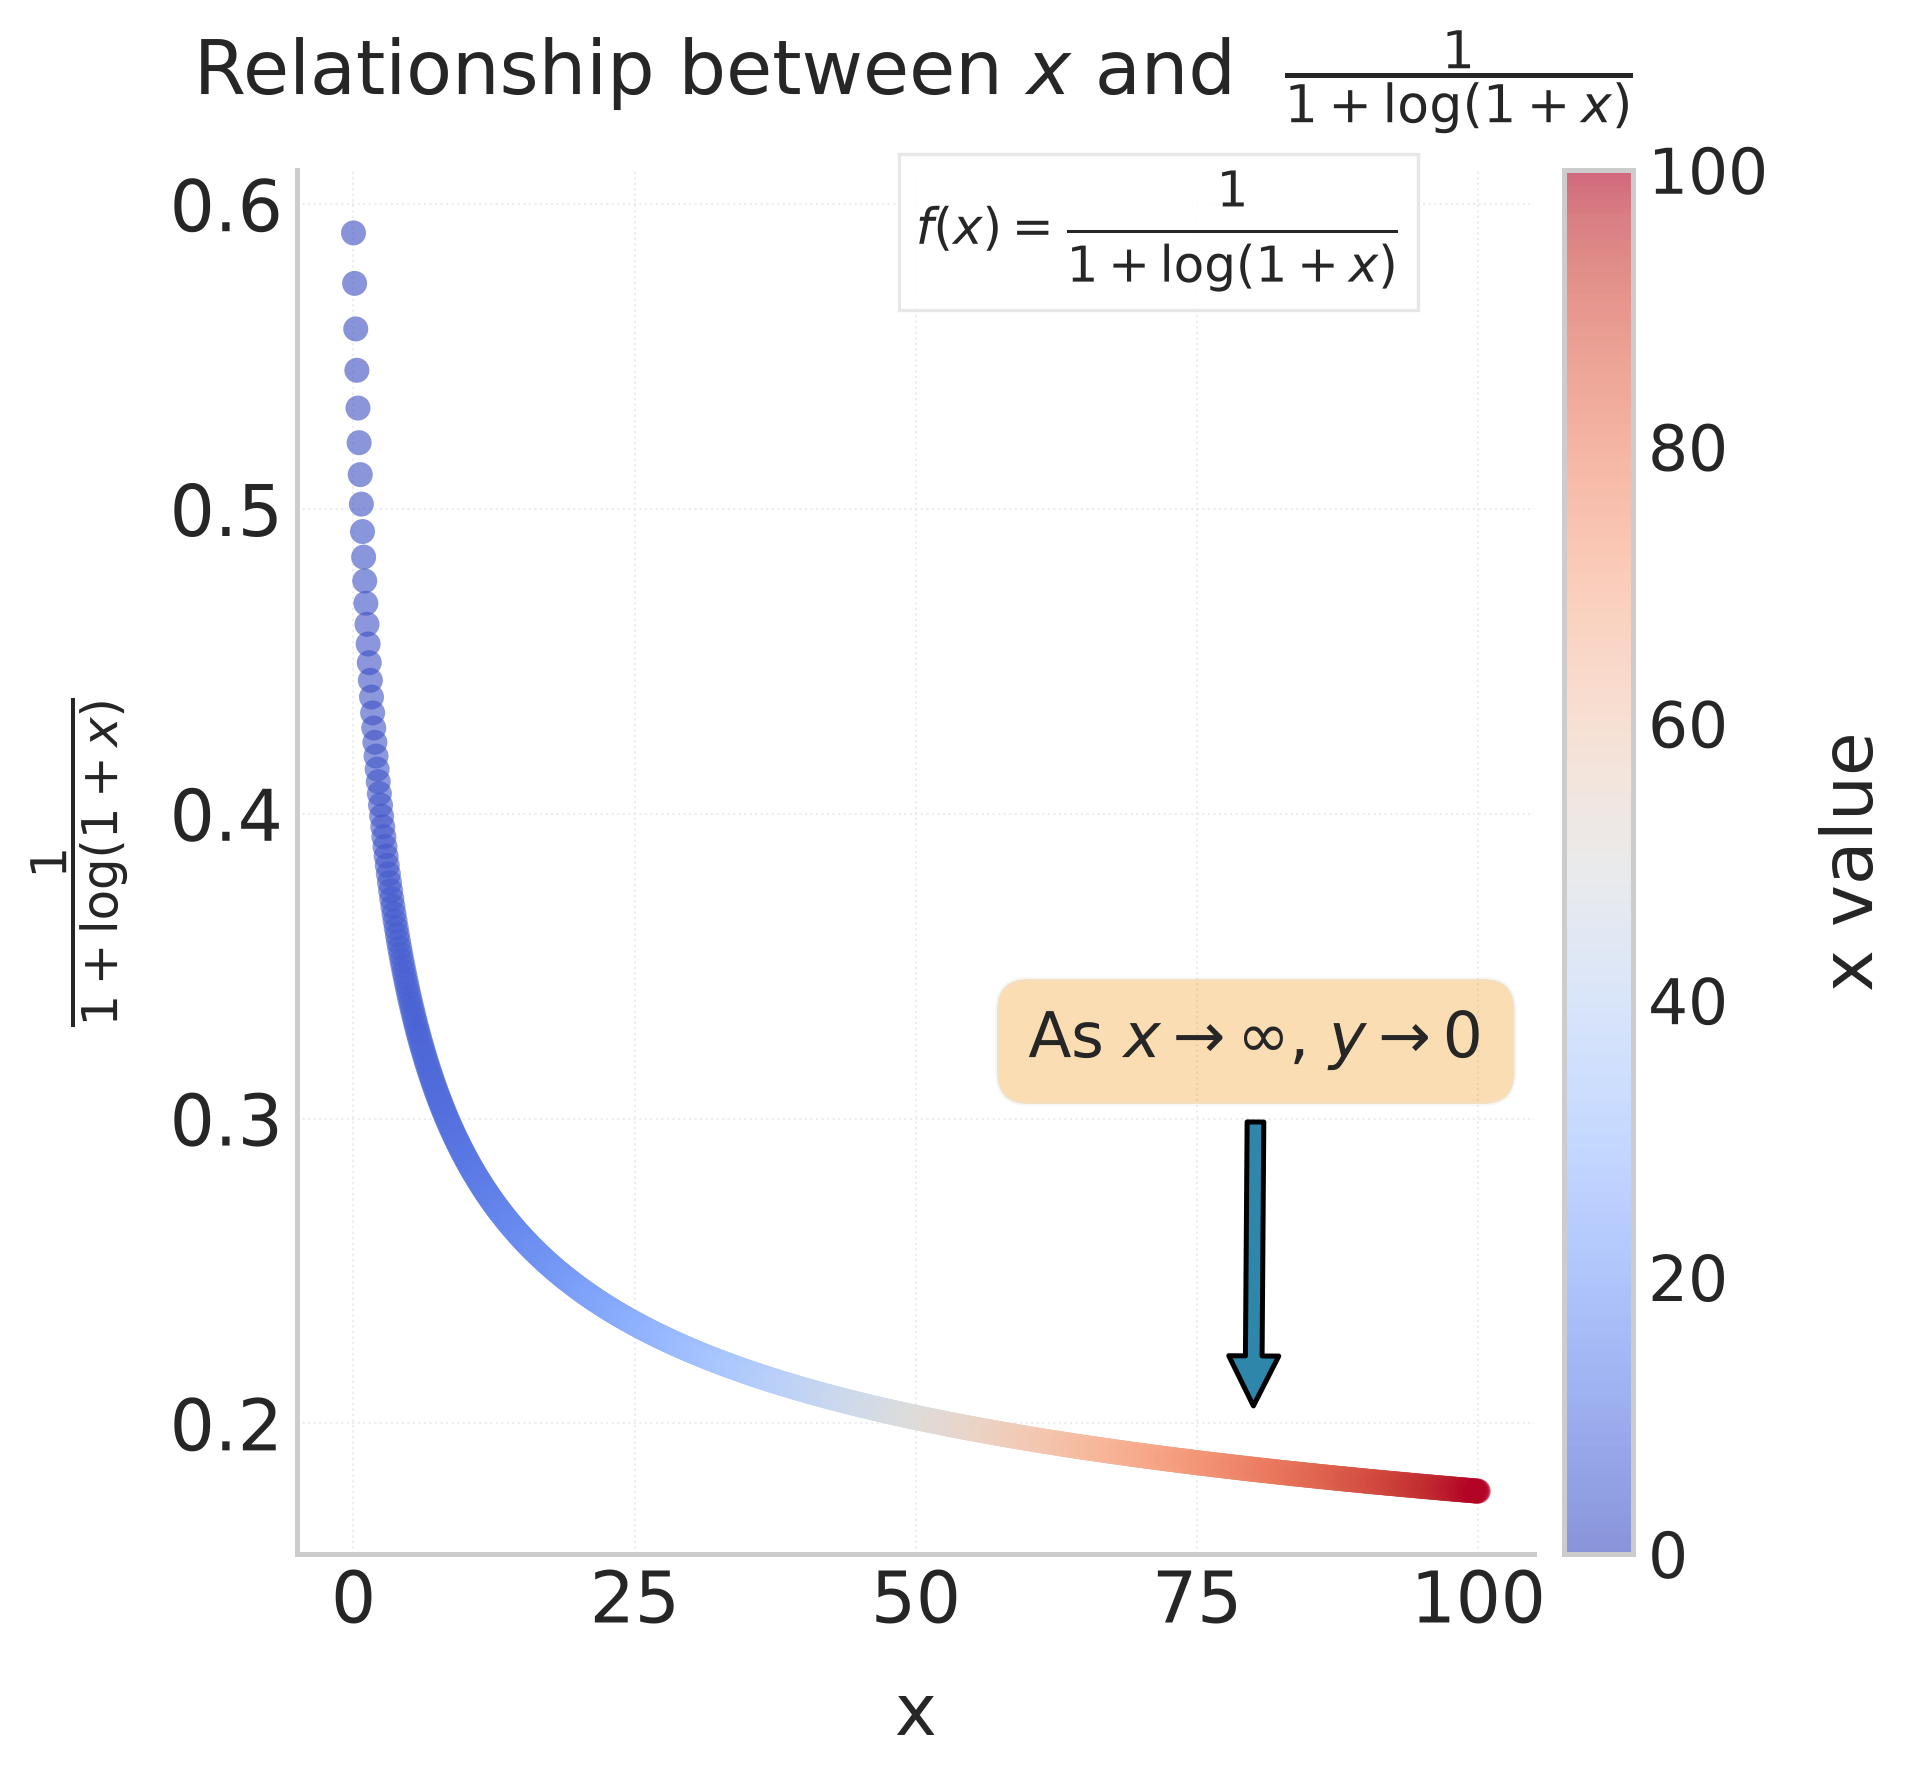

Saved: /home/youssef/projects/Sim-Equity/outputs/figures/relationship_log1p.png


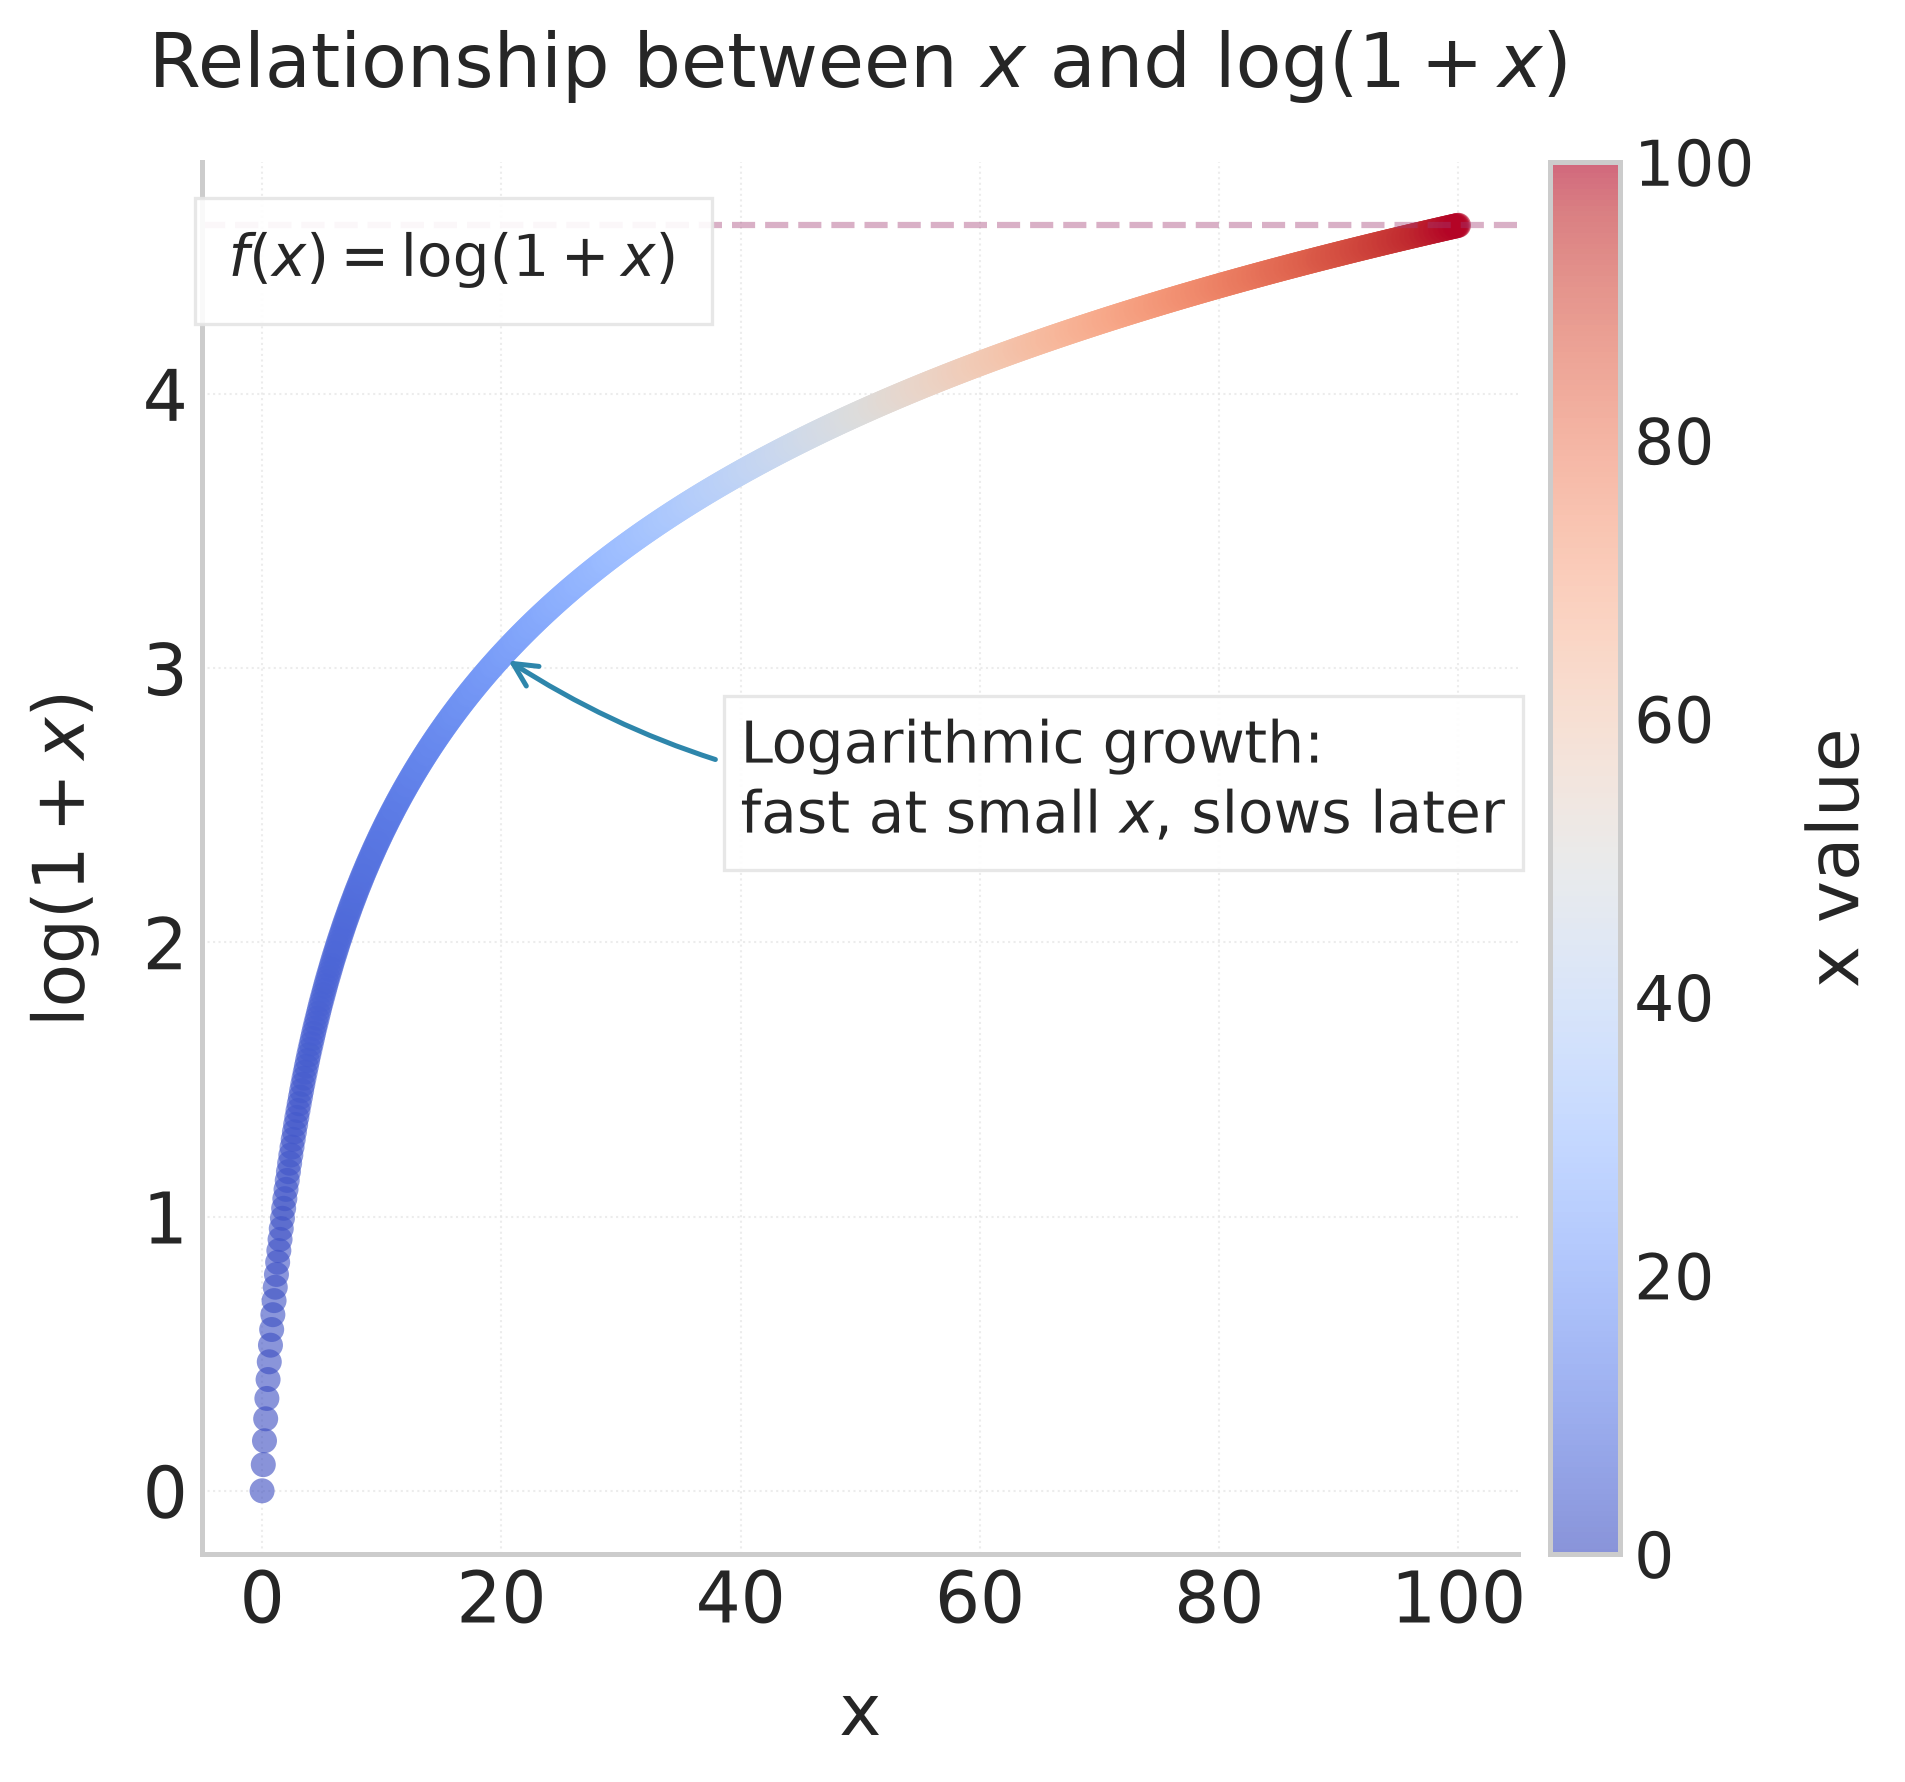

In [39]:


# ---------------------------
# Plot 1: 1 / (1 + log(1 + x))
# ---------------------------
def plot_inverse_log() -> None:
    """Illustrate the decreasing transform applied to resource-count features."""
    i_s = np.linspace(0, 100, 1000)
    y = 1 / (1 + np.log1p(1 + i_s))  # numerically stable form

    fig, ax = plt.subplots()
    sc = ax.scatter(
        i_s, y, c=i_s, cmap=CMAP, s=MARKER_SIZE, alpha=ALPHA, edgecolors="none"
    )

    setup_academic_grid(ax)

    cbar = plt.colorbar(sc, ax=ax, pad=0.02)
    cbar.set_label("x value", fontsize=COLORBAR_FONTSIZE, labelpad=12)
    cbar.ax.tick_params(labelsize=COLORBAR_FONTSIZE - 2)

    ax.set_title(
        format_academic_title(
            r"Relationship between $x$ and $\; \frac{1}{1+\log(1+x)}$"
        ),
        fontsize=TITLE_FONTSIZE - 2,
        pad=18,
    )
    ax.set_xlabel("x", fontsize=BASE_FONTSIZE, labelpad=10)
    ax.set_ylabel(r"$\frac{1}{1+\log(1+x)}$", fontsize=BASE_FONTSIZE, labelpad=10)

    ax.annotate(
        "As $x \\to \\infty$, $y \\to 0$",
        xy=(80, 0.2),
        xytext=(60, 0.32),
        fontsize=ANNOT_FONTSIZE - 2,
        arrowprops=dict(facecolor=PRIMARY_COLOR, shrink=0.05, linewidth=1.2),
        bbox=dict(
            boxstyle="round,pad=0.5", fc=ACCENT_COLOR, alpha=0.3, edgecolor=GRID_COLOR
        ),
    )

    ax.text(
        0.5,
        1,
        r"$f(x) = \dfrac{1}{1 + \log(1+x)}$",
        transform=ax.transAxes,
        fontsize=MATH_FONTSIZE - 6,
        verticalalignment="top",
        bbox=dict(facecolor="white", edgecolor=GRID_COLOR, alpha=0.9, linewidth=0.8),
    )

    savefig_standard(FIGURE_DIR / "relationship_inverse_log.png")
    plt.show()


# ---------------------------
# Plot 2: log(1 + x)
# ---------------------------
def plot_log1p() -> None:
    """Illustrate the log-compression applied to household-size and age-distance features."""
    x = np.linspace(0, 100, 1000)
    y = np.log1p(x)

    fig, ax = plt.subplots()
    sc = ax.scatter(x, y, c=x, cmap=CMAP, s=MARKER_SIZE, alpha=ALPHA, edgecolors="none")

    setup_academic_grid(ax)

    cbar = plt.colorbar(sc, ax=ax, pad=0.02)
    cbar.set_label("x value", fontsize=COLORBAR_FONTSIZE, labelpad=12)
    cbar.ax.tick_params(labelsize=COLORBAR_FONTSIZE - 2)

    ax.set_title(
        format_academic_title(r"Relationship between $x$ and $\log(1+x)$"),
        fontsize=TITLE_FONTSIZE - 2,
        pad=18,
    )
    ax.set_xlabel("x", fontsize=BASE_FONTSIZE, labelpad=10)
    ax.set_ylabel(r"$\log(1+x)$", fontsize=BASE_FONTSIZE, labelpad=10)

    ax.annotate(
        "Logarithmic growth:\nfast at small $x$, slows later",
        xy=(20, np.log1p(20)),
        xytext=(40, np.log1p(10)),
        fontsize=ANNOT_FONTSIZE - 3,
        bbox=dict(facecolor="white", edgecolor=GRID_COLOR, alpha=0.9, linewidth=0.8),
        arrowprops=dict(
            arrowstyle="->",
            connectionstyle="arc3,rad=-.2",
            color=PRIMARY_COLOR,
            linewidth=1.2,
        ),
    )

    ax.text(
        0.02,
        0.95,
        r"$f(x) = \log(1+x)$",
        transform=ax.transAxes,
        fontsize=MATH_FONTSIZE - 4,
        verticalalignment="top",
        bbox=dict(
            facecolor="white", edgecolor=GRID_COLOR, alpha=0.9, linewidth=0.8, pad=8
        ),
    )

    ax.axhline(
        y=np.log1p(100), linestyle="--", alpha=0.4, color=SECONDARY_COLOR, linewidth=1.5
    )

    savefig_standard(FIGURE_DIR / "relationship_log1p.png")
    plt.show()


# Run both transformation-relationship plots
plot_inverse_log()
plot_log1p()


In [40]:
# Indicator Group Mapping
# ─────────────────────────────────────────────────────────────────────────────
# Indicator Group       | Variable(s)                     | What It Measures
# ─────────────────────────────────────────────────────────────────────────────
# Physical Capacity     | PMR, AGE                        | Direct physical barriers to mobility
# Household Resources   | NB_CAR, DRIVING_LICENCE,        | Access to private, independent transport
#                       | TWO_WHEELER, etc.               |
# Household Constraints | NBPERS_HOUSE, NB_10, etc.       | Presence of dependents complicating evacuation
# Socio-Economic Status | DIPLOMA, PRO_CAT                | Income, job flexibility, information access
# System Dependency     | NAVIGO_SUB, etc.                | Reliance on public systems that might fail


In [41]:
os.environ["sirene_key"] = "8443bcd3-ebf5-4a54-83bc-d3ebf51a546f"  #TODO: DEPRECATE THAT KEY


def find_column_by_pattern(df: pd.DataFrame, patterns: list[str]) -> str | None:
    """Return the first column name containing any of *patterns* (case-insensitive)."""
    return next(
        (col for col in df.columns for pat in patterns if pat.lower() in col.lower()),
        None,
    )


def filter_idf_region(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """Filter a GeoDataFrame to Île-de-France using a region code column if present."""
    region_col = next((c for c in gdf.columns if "reg" in c.lower()), None)
    if region_col:
        print(f"Filtering on region column '{region_col}' == '{IDF_REGION_CODE}'")
        return gdf[gdf[region_col] == IDF_REGION_CODE].copy()
    print("No region column found — returning full dataset.")
    return gdf


def load_idf_geodata() -> gpd.GeoDataFrame | None:
    """Load Île-de-France commune geodata from pynsee, trying the latest version first."""
    for identifier in (
            "ADMINEXPRESS-COG.LATEST:commune",
            "ADMINEXPRESS-COG.2017:commune",
    ):
        try:
            gdf = get_geodata(identifier)
            print(f"Loaded geodata '{identifier}': {gdf.shape}")
            return filter_idf_region(gdf)
        except Exception as exc:
            print(f"Could not load '{identifier}': {exc}")
    return None


# ── Step 1: list available commune identifiers ────────────────────────────────
geodata_list = get_geodata_list()
commune_identifiers = [
    row["Identifier"]
    for _, row in geodata_list.iterrows()
    if "commune" in row["Identifier"].lower()
]
print(f"Found {len(commune_identifiers)} commune identifier(s):")
for ident in commune_identifiers:
    print(f"  - {ident}")

# ── Step 2: sample SVI data (replace with actual data in production) ──────────
svi_data = pd.DataFrame(
    {
        "insee_code": [
            "75001",
            "75002",
            "75003",
            "92001",
            "92002",
            "93001",
            "94001",
            "95001",
        ],
        "svi_score": [150, 200, 180, 220, 190, 250, 210, 170],
    }
)

# ── Step 3: aggregate SVI scores by INSEE code ────────────────────────────────
svi_grouped = svi_data.groupby("insee_code")["svi_score"].sum().reset_index()
print(f"Aggregated SVI data: {svi_grouped.shape[0]} communes")

# ── Step 4: load IDF geodata ──────────────────────────────────────────────────
idf_geodata = load_idf_geodata()

if idf_geodata is None:
    print("ERROR: Could not load any IDF geodata. Check available identifiers.")
else:
    # ── Step 5: merge SVI data with geometries ────────────────────────────────
    insee_col = find_column_by_pattern(idf_geodata, INSEE_COLUMN_PATTERNS)
    if insee_col is None:
        print(
            "ERROR: Could not find INSEE code column. Available columns:",
            idf_geodata.columns.tolist(),
        )
    else:
        idf_geodata[insee_col] = idf_geodata[insee_col].astype(str)
        svi_grouped["insee_code"] = svi_grouped["insee_code"].astype(str)

        map_data = idf_geodata.merge(
            svi_grouped, left_on=insee_col, right_on="insee_code", how="left"
        )
        map_data["svi_score"] = map_data["svi_score"].fillna(0)

        matched = (map_data["svi_score"] > 0).sum()
        unmatched = set(svi_grouped["insee_code"]) - set(
            map_data.loc[map_data["svi_score"] > 0, "insee_code"]
        )

        print(f"Merged: {map_data.shape[0]} communes total, {matched} with SVI data")
        if unmatched:
            print(f"Unmatched INSEE codes: {sorted(unmatched)}")

        # ── Step 6: choropleth map ────────────────────────────────────────────
        fig, ax = plt.subplots(figsize=(12, 10))
        map_data.plot(
            column="svi_score",
            ax=ax,
            legend=True,
            cmap="YlOrRd",
            edgecolor="black",
            linewidth=0.1,
            legend_kwds={
                "label": "SVI Score",
                "orientation": "vertical",
                "shrink": 0.6,
            },
        )
        ax.set_title(
            "SVI Scores by District in Île-de-France", fontsize=16, fontweight="bold"
        )
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.tick_params(axis="both", labelsize=8)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        # ── Step 7: summary statistics ────────────────────────────────────────
        scores = map_data["svi_score"]
        print(f"\nSVI Score Statistics:")
        print(f"  Mean:   {scores.mean():.2f}")
        print(f"  Median: {scores.median():.2f}")
        print(f"  Min:    {scores.min():.2f}")
        print(f"  Max:    {scores.max():.2f}")
        print(f"  Std:    {scores.std():.2f}")


Existing environment variable sirene_key used, instead of locally saved credentials


Found 48 commune identifier(s):
  - ADMINEXPRESS-COG.2017:commune
  - ADMINEXPRESS-COG.2018:commune
  - ADMINEXPRESS-COG.2019:commune
  - ADMINEXPRESS-COG.2020:commune
  - ADMINEXPRESS-COG.2021:chef_lieu_commune_associee_ou_deleguee
  - ADMINEXPRESS-COG.2021:chef_lieu_commune
  - ADMINEXPRESS-COG.2021:commune
  - ADMINEXPRESS-COG.2021:commune_associee_ou_deleguee
  - ADMINEXPRESS-COG.2022:chef_lieu_commune_associee_ou_deleguee
  - ADMINEXPRESS-COG.2022:chef_lieu_commune
  - ADMINEXPRESS-COG.2022:commune
  - ADMINEXPRESS-COG.2022:commune_associee_ou_deleguee
  - ADMINEXPRESS-COG.2023:chef_lieu_commune_associee_ou_deleguee
  - ADMINEXPRESS-COG.2023:chef_lieu_commune
  - ADMINEXPRESS-COG.2023:commune
  - ADMINEXPRESS-COG.2023:commune_associee_ou_deleguee
  - ADMINEXPRESS-COG.2024:chef_lieu_commune_associee_ou_deleguee
  - ADMINEXPRESS-COG.2024:chef_lieu_commune
  - ADMINEXPRESS-COG.2024:commune
  - ADMINEXPRESS-COG.2024:commune_associee_ou_deleguee
  - ADMINEXPRESS-COG.2025:chef_lieu_de_c

  0%|          | 0/7 [01:37<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
# Optional: simple Folium interactive map (uncomment to use)
#
# import folium
#
# def create_interactive_map(map_data: gpd.GeoDataFrame) -> folium.Map:
#     m = folium.Map(location=[48.8566, 2.3522], zoom_start=10)
#     folium.Choropleth(
#         geo_data=map_data,
#         data=map_data,
#         columns=['code', 'svi_score'],
#         key_on='feature.properties.code',
#         fill_color='YlOrRd',
#         fill_opacity=0.7,
#         line_opacity=0.2,
#         legend_name='SVI Score',
#     ).add_to(m)
#     folium.features.GeoJsonTooltip(
#         fields=['nom', 'code', 'svi_score'],
#         aliases=['Commune:', 'INSEE Code:', 'SVI Score:'],
#         localize=True,
#     ).add_to(m)
#     return m
#
# interactive_map = create_interactive_map(map_data)
# interactive_map.save('idf_svi_interactive_map.html')
